**☀️ Welcome to ParkerNet Version 1.1 Notebook 3 of 3: Plotting**

With this Notebook, you will be able to:

1. Plot ParkerNet predictions on a select few days as they appear in the paper "An Iterative, Deep Learning Approach for Switchback Classification in Parker Solar Probe Data".

**Specifics of plots:**

*   You will be able to create a prediction vs ground truth plot to see how the predictions line up. The plot is made using B_r but you can do it with any other variable you choose.
*   You will also be able to plot heatmaps for evaluation metrics such as precision, recall, Intersection over Union(IoU), F1 score, and F2 score. The prediction and heatmap plots provide a granular performace evaluation for the Huang et al. (2023) catalog data as it takes into account the different quality flags and regions.

*   You will be able to plot confusion matrices when comparing predictions to the two catalogs (Huang et al. (2023) and Pecora et al. (2022)) , and also Precicsion_Recall Curves (PRC). For CM and PRC, all quality flags and regions in Huang et al. (2023) catalog are used to provide an overall evaluation.

*   **This notebook contains figures for days from E1, E2, E4, E5 which are not shown in the paper and serves as an appendix for these figures.**


Files you will need:

***PREDICTION FILES***



PSP_E1_ForPrediction.txt

PSP_E2_ForPrediction.txt

PSP_E4_ForPrediction.txt

PSP_E5_ForPrediction.txt

PSP_E6_ForPrediction.txt

PSP_E7_ForPrediction.txt

PSP_E8_ForPrediction.txt



***FILES WITH THE INDIVIDUAL MODEL PREDICTIONS AND ENSEMBLE PREDICTIONS CREATED FROM NOTEBOOK 2***

ParkerNet_allModel_averaged_predictions_E1_20181109.csv

ParkerNet_allModel_averaged_predictions_E2_20190331.csv

ParkerNet_allModel_averaged_predictions_E4_20200124.csv

ParkerNet_allModel_averaged_predictions_E5_20200602.csv

ParkerNet_allModel_averaged_predictions_E6_20200918.csv

ParkerNet_allModel_averaged_predictions_E7_20210112.csv

ParkerNet_allModel_predictions_E8_Oct30_AUCPRC.csv



***GROUND TRUTH FILES (from Huang et al. (2023) and Pecora et al. (2022) Catalogs)***

***Notes on ground truth catalogs: The original ground truth catalogs contain dates and times, we have converted these into indices that correspond to the those dates and times in the prediction datasets. The files listed below contain indices that match the orginal catalog times from Huang et al. (2023) and Pecora et al. (2022) ***

SingalROI_E1_Huang_allRegions.txt

SignalROI_E1_Pecora_10s_6hr.txt

SingalROI_E2_Huang_allRegions.txt

SignalROI_E2_Pecora_10s_6hr.txt

SingalROI_E4_Huang_allRegions.txt

SignalROI_E4_Pecora_10s_6hr.txt

SingalROI_E5_Huang_allRegions.txt

SignalROI_E5_Pecora_10s_6hr.txt

SingalROI_E6_Huang_allRegions.txt

SignalROI_E6_Pecora_10s_6hr.txt

SingalROI_E7_Huang_allRegions.txt

SignalROI_E7_Pecora_10s_6hr.txt

SingalROI_E8_Huang_allRegions.txt

SignalROI_E8_26and27_Pecora_10s_6hr.txt

In [1]:
from google.colab import drive
drive.mount('/content/MyDrive')

Mounted at /content/MyDrive


In [2]:
cd MyDrive/MyDrive

/content/MyDrive/MyDrive


loading libraries and installing pyart for plotting

In [3]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import sklearn
from sklearn.cluster import DBSCAN
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
#import pyart # pyart was used for the CM and heatmaps in the paper, but it no longer works so , RdBu is used for the colormap instead.

dependencies

In [ ]:
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
#print(f"Py-ART: {pyart.__version__}")

Pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scikit-learn: 1.6.1


Thank you to the pyart team for their awesome libary used here!


**Citation for pyart libary:JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119**

# ====== Loading Prediction Data ======

We will load in the E1 prediction set, load in the predictions for this same dataset (output of Notebook2 of 3) , and merge them to have a dataframe with the features of the prediction set + model predictions. This merged dataset is called df_ensemble_E1. This is repeated for each prediction dataset below.

In [4]:
# Read in the dataset for predicting (Here we us a dataset containing data from 2018/11/09)
#df_E1 = pd.read_csv('PSP_E1_ForPrediction.txt', sep="\t", parse_dates=['Datetime'], index_col='Datetime')
df_E1 = pd.read_csv('PSP_E1_ForPrediction.txt', sep="\t", parse_dates=['Datetime'])#USe this if you want to keep Datetime column
# Separate the 'Class_Huang_E1' column into df_gt
df_gt_E1 = df_E1[['Class_Huang_E1_Range']].copy()

pd.set_option('future.no_silent_downcasting', True)
df_gt_E1['Class_Huang_E1_Range'] = df_gt_E1['Class_Huang_E1_Range'].replace({True: 1, False: 0}).infer_objects(copy=False).astype(int)
# Create df_test by dropping the 'Class_Huang_E1' column and other columns not needed
df_test_E1 = df_E1.drop(columns=['Class_Huang_E1_Range'])

df_test_E1.pop("X_HCI")
df_test_E1.pop("Y_HCI")
df_test_E1.pop("Z_HCI")

df_test_E1.head()

,Datetime,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2018-11-09 00:00:00.000000000,-49.371789,62.642208,38.033857,6.316516,436.839,47.0994,31.48080,440.497113,56.651516,165.413
1,2018-11-09 00:00:00.873799999,-45.553400,62.767516,39.388750,17.696757,437.807,47.4472,-1.20197,440.372173,47.462422,146.574
2,2018-11-09 00:00:01.747599999,-49.101096,62.639689,37.564461,10.085851,435.181,57.4931,40.49310,440.826100,70.321744,166.058
3,2018-11-09 00:00:02.621399999,-45.881703,63.059467,37.421067,21.703215,433.488,55.0365,28.56090,437.900203,62.005978,164.465
4,2018-11-09 00:00:03.495199999,-45.757940,62.264022,36.162581,21.801078,426.718,45.2064,42.29580,431.185349,61.907619,162.836


In [5]:
df_gt_allpreds_E1 = pd.read_csv('ParkerNet_allModel_averaged_predictions_E1_20181109.csv')
display(df_gt_allpreds_E1)

,Class_Huang_E1_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,Preds_splitM_seed1843,Preds_splitM_seed2221,Preds_splitM_seed3060,Preds_splitM_seed3247,Preds_splitM_seed3364,Preds_splitM_seed3871,Preds_splitM_seed4032,Preds_splitM_seed983,SimpleSoftVoting_Predictions,Weighted_Voting_AUC_PRC
0,0,0.642424,0.462805,0.672160,0.374071,0.637783,0.628033,0.650803,0.697934,0.582055,...,0.486165,0.561755,0.577205,0.782511,0.830987,0.503556,0.700335,0.537986,0.623648,0.623029
1,0,0.638870,0.453921,0.671912,0.372728,0.637584,0.627352,0.648317,0.696888,0.577626,...,0.483395,0.554735,0.571665,0.780516,0.828701,0.500174,0.701689,0.530636,0.621046,0.620406
2,0,0.633329,0.450474,0.671493,0.372471,0.638732,0.626013,0.647201,0.695288,0.577104,...,0.481588,0.553194,0.562182,0.779537,0.827712,0.493591,0.694901,0.523528,0.618695,0.618052
3,0,0.629857,0.447708,0.671584,0.371867,0.638244,0.626097,0.644705,0.694311,0.568850,...,0.482084,0.550513,0.561782,0.777397,0.825805,0.488350,0.688656,0.520852,0.616360,0.615710
4,0,0.629840,0.440384,0.671447,0.370629,0.638205,0.623433,0.643206,0.693406,0.562418,...,0.480879,0.552098,0.558861,0.776783,0.825020,0.486097,0.682089,0.517394,0.614420,0.613752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.613225,0.250376,0.645562,0.392424,0.612590,0.523301,0.600285,0.297019,0.178696,...,0.238316,0.393605,0.242043,0.351639,0.502412,0.215418,0.359817,0.315977,0.346125,0.345536
98826,0,0.610912,0.248678,0.644637,0.391054,0.612589,0.525488,0.597993,0.296729,0.179715,...,0.239337,0.394885,0.242800,0.352729,0.503855,0.214551,0.362698,0.317508,0.345973,0.345401
98827,0,0.609904,0.247775,0.644281,0.392606,0.611216,0.525874,0.600007,0.298329,0.179986,...,0.239578,0.397256,0.241609,0.352540,0.502891,0.214302,0.357324,0.318843,0.346103,0.345521
98828,0,0.608417,0.248805,0.645508,0.395599,0.609352,0.521210,0.600685,0.296750,0.180189,...,0.238401,0.396791,0.243654,0.355121,0.502510,0.213136,0.354435,0.319725,0.346013,0.345434


In [6]:
df_test_E1.reset_index(drop = True,inplace=True)
df_gt_allpreds_E1.reset_index(drop=True, inplace=True)
df_ensemble_E1 = pd.concat([df_gt_allpreds_E1, df_test_E1], axis=1, join='inner')
display(df_ensemble_E1)

,Class_Huang_E1_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,0,0.642424,0.462805,0.672160,0.374071,0.637783,0.628033,0.650803,0.697934,0.582055,...,-49.371789,62.642208,38.033857,6.316516,436.839,47.09940,31.48080,440.497113,56.651516,165.4130
1,0,0.638870,0.453921,0.671912,0.372728,0.637584,0.627352,0.648317,0.696888,0.577626,...,-45.553400,62.767516,39.388750,17.696757,437.807,47.44720,-1.20197,440.372173,47.462422,146.5740
2,0,0.633329,0.450474,0.671493,0.372471,0.638732,0.626013,0.647201,0.695288,0.577104,...,-49.101096,62.639689,37.564461,10.085851,435.181,57.49310,40.49310,440.826100,70.321744,166.0580
3,0,0.629857,0.447708,0.671584,0.371867,0.638244,0.626097,0.644705,0.694311,0.568850,...,-45.881703,63.059467,37.421067,21.703215,433.488,55.03650,28.56090,437.900203,62.005978,164.4650
4,0,0.629840,0.440384,0.671447,0.370629,0.638205,0.623433,0.643206,0.693406,0.562418,...,-45.757940,62.264022,36.162581,21.801078,426.718,45.20640,42.29580,431.185349,61.907619,162.8360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.613225,0.250376,0.645562,0.392424,0.612590,0.523301,0.600285,0.297019,0.178696,...,-53.566602,54.753702,0.255670,11.336738,457.572,4.64116,34.42040,458.888265,34.731892,60.7480
98826,0,0.610912,0.248678,0.644637,0.391054,0.612589,0.525488,0.597993,0.296729,0.179715,...,-52.037498,54.472319,-1.696898,16.014147,464.397,13.79590,54.78750,467.821088,56.497761,56.5016
98827,0,0.609904,0.247775,0.644281,0.392606,0.611216,0.525874,0.600007,0.298329,0.179986,...,-52.321083,55.255709,0.602406,17.757669,449.107,26.12870,52.15470,452.879586,58.333710,64.5057
98828,0,0.608417,0.248805,0.645508,0.395599,0.609352,0.521210,0.600685,0.296750,0.180189,...,-53.235152,55.090400,3.468124,13.745648,434.125,16.74630,30.33550,435.505679,34.650846,70.3433


In [ ]:
display(df_ensemble_E1[['Datetime'] + [col for col in df_ensemble_E1.columns if col != 'Datetime']].head())

,Datetime,Class_Huang_E1_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2018-11-09 00:00:00.000000000,0,0.642424,0.462805,0.672160,0.374071,0.637783,0.628033,0.650803,0.697934,...,-49.371789,62.642208,38.033857,6.316516,436.839,47.0994,31.48080,440.497113,56.651516,165.413
1,2018-11-09 00:00:00.873799999,0,0.638870,0.453921,0.671912,0.372728,0.637584,0.627352,0.648317,0.696888,...,-45.553400,62.767516,39.388750,17.696757,437.807,47.4472,-1.20197,440.372173,47.462422,146.574
2,2018-11-09 00:00:01.747599999,0,0.633329,0.450474,0.671493,0.372471,0.638732,0.626013,0.647201,0.695288,...,-49.101096,62.639689,37.564461,10.085851,435.181,57.4931,40.49310,440.826100,70.321744,166.058
3,2018-11-09 00:00:02.621399999,0,0.629857,0.447708,0.671584,0.371867,0.638244,0.626097,0.644705,0.694311,...,-45.881703,63.059467,37.421067,21.703215,433.488,55.0365,28.56090,437.900203,62.005978,164.465
4,2018-11-09 00:00:03.495199999,0,0.629840,0.440384,0.671447,0.370629,0.638205,0.623433,0.643206,0.693406,...,-45.757940,62.264022,36.162581,21.801078,426.718,45.2064,42.29580,431.185349,61.907619,162.836


# ====== Plotting code ======
The plotting code below can be used to create (1) ground truths vs B_r , model prediction (average weighted prediction) vs B_r. Note that the different quality flags in Huang et al. (2023) data are color coded.
(2) heatmap showing prediction metrics for each region in Huang et al. (2023) and Pecora et al. (2022) data.
(3) confusion matrices and PR curves for ground truths. Here the quality flags of Huang et al. (2023) are not taken into account.

Notes on plotting Pecora et al. (2022) data: The pecora data do not contain start and end times, but since their 10s data are used, each data point lasts 10s. 10 s (converted to 11.44 time steps since 1 ts = 0.8738 seconds) is used to do this. Additonally, DBSCAN is used to check for consecutive data points (i.e. consecutive data points is 1 switchback).

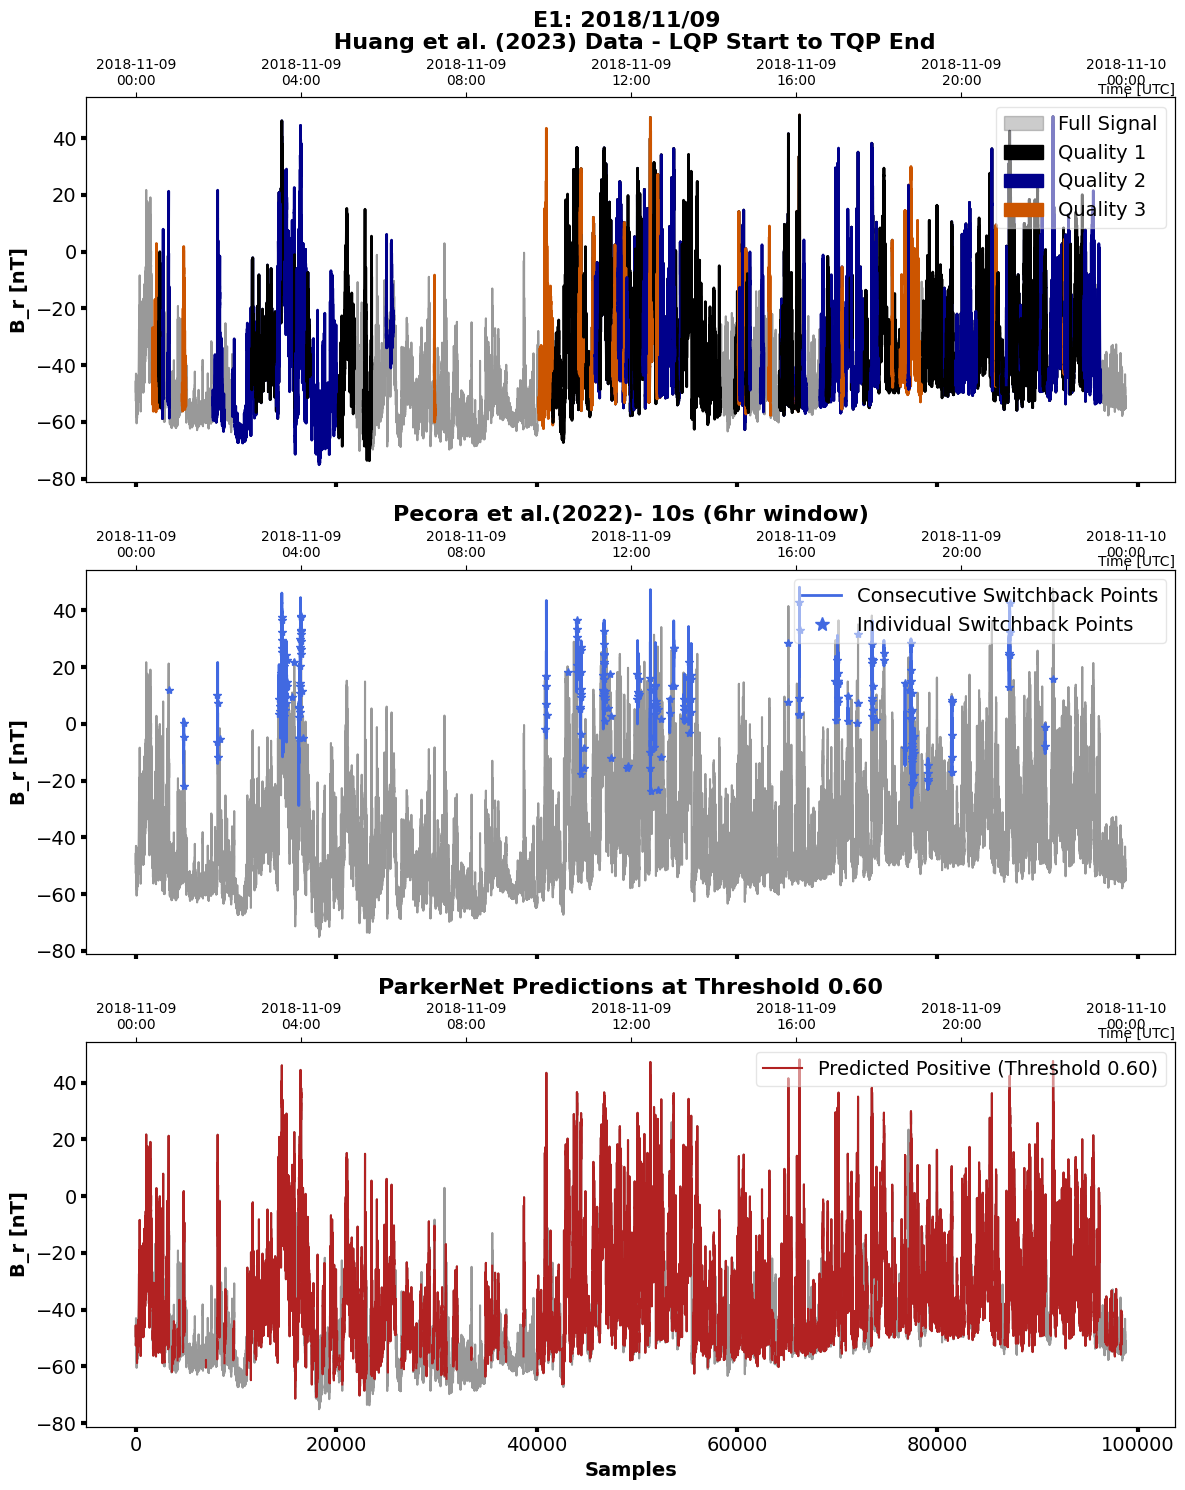

In [7]:


# Load the Huang ground truth data
roi_data = pd.read_csv('SingalROI_E1_Huang_allRegions.txt', sep='\t')

signal_data = df_ensemble_E1['B_r']
datetime_axis = df_ensemble_E1['Datetime']
predictions = df_ensemble_E1['Weighted_Voting_AUC_PRC']

# Define the threshold (set to 0.6)
threshold = 0.6

# Define a color map for quality levels
quality_colors = {
    1: 'black',
    2: '#00008B',  # Dark Blue for Quality 1
    3: '#CC5500',  # Burnt Orange for Quality 2
    4: '#8B0000',  # Red Brown for Quality 3
    5: '#8B4513'   # Red Brown for Quality 4
}

# Load the Pecora data 10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E1_Pecora_10s_6hr.txt', sep='\t')

# 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds
# Create binary mask for predictions based on the threshold
binary_predictions = (predictions > threshold).astype(int)


# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Perform DBSCAN clustering on the start indices
indices = pecora_data['start_index'].values.reshape(-1, 1)  # Reshape for DBSCAN
db = DBSCAN(eps=15, min_samples=2)  # Adjust parameters as needed
labels = db.fit_predict(indices)

# Initialize clusters list
clusters = []

# Group indices by cluster labels
for label in np.unique(labels):
    if label != -1:  # Skip noise
        cluster_indices = indices[labels == label].flatten()
        start_index = int(cluster_indices[0])
        end_index = int(cluster_indices[-1])
        clusters.append((start_index, end_index))

# Create subplot
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]})
# --- Top Subplot: Full Ground Truth Switchbacks (LQP Start to TQP End) for Huang ---
axs[0].plot(signal_data, color='black', alpha=0.4, label='Full Signal')

# Track legend patches in defined order
legend_patches = [mpatches.Patch(color='black', alpha=0.2, label='Full Signal')]
added_qualities = set()  # Track added quality levels to avoid duplicates

# Plot each switchback (from LQP Start to TQP End) with color based on quality
for _, row in roi_data.iterrows():
    quality_flag = row['QualityFlag']
    color = quality_colors.get(quality_flag, 'gray')  # Use default to gray if the quality level is unknown

    # Define start and end points of the full ground truth switchback
    switchback_start = row['LQP_Start_Index']
    switchback_end = row['TQP_End_Index']

    # Plot the full ground truth switchback as a solid line
    axs[0].plot(range(switchback_start, switchback_end), signal_data[switchback_start:switchback_end], color=color, linewidth=2)

    # Add switchback region to legend if not already added
    if quality_flag not in added_qualities:
        legend_patches.append(mpatches.Patch(color=color, label=f'Quality {quality_flag}'))
        added_qualities.add(quality_flag)

# Sort the legend patches to display qualities in ascending order
legend_patches = [legend_patches[0]] + sorted(legend_patches[1:], key=lambda x: int(x.get_label().split()[-1]))

# Add legend for the top plot
axs[0].legend(handles=legend_patches, loc='upper right', fontsize=14,framealpha=0.5)
axs[0].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[0].set_title('E1: 2018/11/09 \n Huang et al. (2023) Data - LQP Start to TQP End', fontsize=16, fontweight='bold')

# --- Middle Subplot: Pecora Data (Sparse Points and DBSCAN Segments) ---
axs[1].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Plot sparse points as asterisks
sparse_points_color = '#4169E1'  # Royal Blue
for _, row in pecora_data.iterrows():
    start_idx = int(row['start_index'])
    axs[1].plot(start_idx, signal_data[start_idx], marker='*', color=sparse_points_color)

# Plot clustered segments
for start_idx, end_idx in clusters:
    axs[1].plot(range(start_idx, end_idx), signal_data[start_idx:end_idx], color=sparse_points_color, linewidth=2)

# Add legend for Pecora data
pecora_line = Line2D([0], [0], color=sparse_points_color, lw=2, label='Consecutive Switchback Points')
sparse_asterisk = Line2D([0], [0], color=sparse_points_color, marker='*', linestyle='None', markersize=10, label='Individual Switchback Points')
axs[1].legend(handles=[pecora_line, sparse_asterisk], loc='upper right', fontsize=14, framealpha=0.5)

axs[1].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[1].set_title('Pecora et al.(2022)- 10s (6hr window)', fontsize=16, fontweight='bold')

# --- Bottom Subplot: Model Predictions ---
model_prediction_line = signal_data.copy()
model_prediction_line[binary_predictions == 0] = np.nan  # Mask out negative predictions
model_prediction_color = '#B22222'
axs[2].plot(signal_data, color='black', alpha=0.4)
axs[2].plot(model_prediction_line, color=model_prediction_color, linewidth=1.5, label=f'Predicted Positive (Threshold {threshold:.2f})')

axs[2].set_xlabel('Samples', fontsize=14, fontweight='bold')
axs[2].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[2].set_title(f'ParkerNet Predictions at Threshold {threshold:.2f}', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', fontsize=14, framealpha=0.5)

# --- Secondary datetime axis on top, ticks every 4 h ---
start_time    = datetime_axis.min().floor('h')
end_time      = datetime_axis.max().ceil('h')
four_hour_times = pd.date_range(start=start_time, end=end_time, freq='4h')
sample_ticks  = datetime_axis.searchsorted(four_hour_times)
tick_labels   = four_hour_times.strftime('%Y-%m-%d\n%H:%M')

# Apply tick parameters to all axes after plotting
for ax in axs:
    ax.tick_params(axis='x', labelsize=14, width=3)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=14, width=3)  # y-axis ticks
for ax in axs:
    twin = ax.twiny()
    twin.set_xlim(ax.get_xlim())
    twin.set_xticks(sample_ticks)
    twin.set_xticklabels(tick_labels, fontsize=10)
    twin.set_xlabel('Time [UTC]')
    twin.xaxis.label.set_horizontalalignment('right')
    twin.xaxis.set_label_coords(1, 1.01, transform=ax.transAxes)
# Adjust layout and show the plot for Pecora and Model Predictions
plt.tight_layout()
#
#plt.savefig('APJS_E1.svg', dpi=600, bbox_inches='tight')
#plt.savefig('APJS_E1.pdf', dpi=600, bbox_inches='tight')
plt.show()



 (True Negatives):  19403
 (False Positives):  12793
(False Negatives):  14682
 (True Positives):  51952
Precision: 0.8024
Recall: 0.7797
F1 Score: 0.7909
Total Switchbacks (Ground Truth 1):  66634
Intersection over Union (IoU): 0.6541


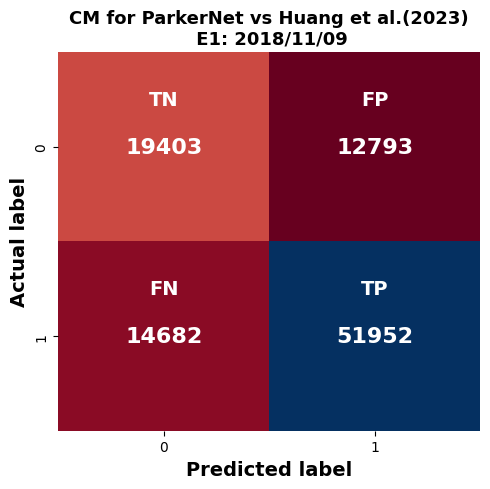

IoU at threshold 0.6: 0.6541


In [8]:


# Load the data
huang_data_path = 'SingalROI_E1_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')  # loading in huang ground truths

predictions = df_ensemble_E1['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E1['Class_Huang_E1_Range']

# Define threshold (you can change this value if you want to see how the predictions change with threshold)
threshold = 0.6

# Confusion Matrix Function
def plot_cm_and_metrics(labels, predictions, threshold=0.6):
    # Compute the confusion matrix
    cm = confusion_matrix(labels, predictions > threshold)

    # Plot the confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title('CM for ParkerNet vs Huang et al.(2023)\n E1: 2018/11/09', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')
    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()

    # Position the labels slightly above the center of each section
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # Show the plot
    plt.savefig('E1_Huang_CM.svg', dpi=600, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth, predictions, threshold=0.6)

# Optionally, print IoU as well if needed:
print(f'IoU at threshold {threshold}: {iou:.4f}')


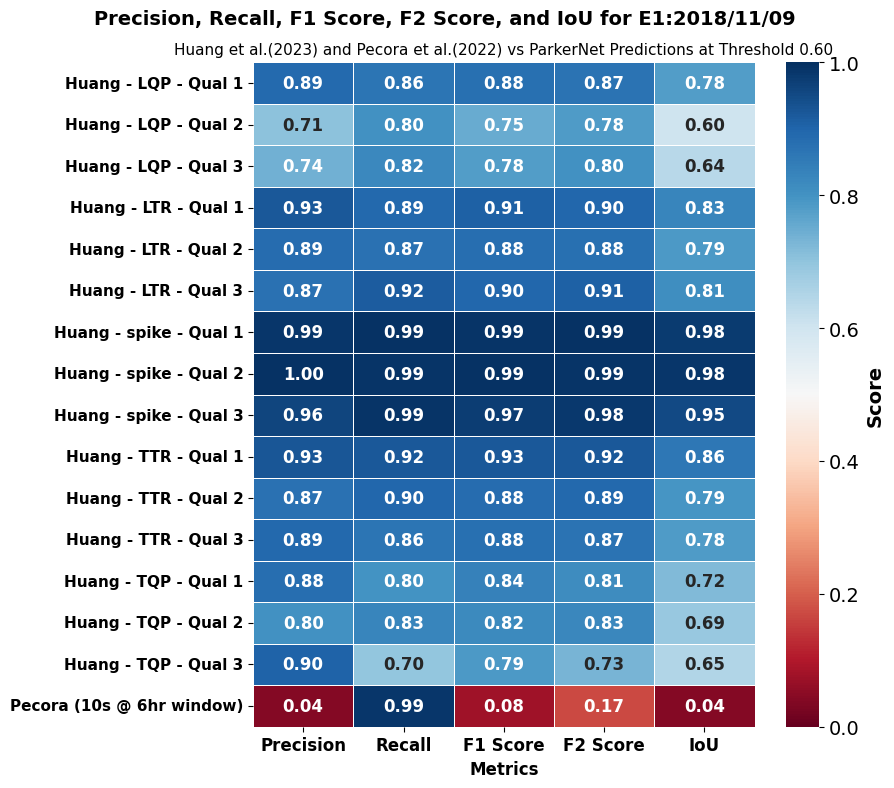

In [9]:


# Load data
huang_data_path = 'SingalROI_E1_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')

predictions = df_ensemble_E1['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E1['Class_Huang_E1_Range']

# Define threshold
threshold = 0.6

# Define regions for Huang ground truths
regions = {
    "LQP": ("LQP_Start_Index", "LQP_End_Index"),
    "LTR": ("LQP_End_Index", "spike_Start_Index"),
    "spike": ("spike_Start_Index", "spike_End_Index"),
    "TTR": ("spike_End_Index", "TQP_Start_Index"),
    "TQP": ("TQP_Start_Index", "TQP_End_Index")
}

# Initialize lists to store Precision, Recall, F1, F2, and IoU values for the heatmap
heatmap_data = []
row_labels = []

# Loop through regions and quality flags for Huang data
for region, (start_col, end_col) in regions.items():
    for quality in sorted(roi_data['QualityFlag'].unique()):
        row_labels.append(f"Huang - {region} - Qual {quality}")
        row_data = []

        # Filter quality rows for the current region and quality
        quality_rows = roi_data[roi_data['QualityFlag'] == quality]
        ground_truth_segment = []

        # Construct ground truth and predictions for the current region and quality
        for _, row in quality_rows.iterrows():
            start, end = row[start_col], row[end_col]
            gt_segment = ground_truth[start:end].values  # Get the ground truth for the segment
            pred_segment = (predictions[start:end] >= threshold).astype(int).values  # Get the predicted values
            ground_truth_segment.extend(gt_segment)
            ground_truth_segment.extend(pred_segment)

        # Calculate confusion matrix
        cm = confusion_matrix(ground_truth_segment[:len(ground_truth_segment)//2], ground_truth_segment[len(ground_truth_segment)//2:])

        # Get TP, FP, FN
        TN, FP, FN, TP = cm.ravel()

        # Calculate Precision, Recall, F1, and F2 for the current region and quality
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        F1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        F2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) != 0 else 0

        # Calculate IoU for the current region and quality
        iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0

        # Append Precision, Recall, F1, F2, IoU results for the current region and quality
        row_data.extend([precision, recall, F1_score, F2_score, iou])

        # Append the data for the current region and quality
        heatmap_data.append(row_data)


#Load Pecora d10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E1_Pecora_10s_6hr.txt', sep = '\t')
predictions_pecora = df_ensemble_E1['Weighted_Voting_AUC_PRC']

# Create binary predictions based on threshold for Pecora data
binary_predictions_pecora = (predictions_pecora >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices for Pecora (10 seconds)
ground_truth_pecora = np.zeros_like(binary_predictions_pecora)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Calculate Precision, Recall, F1, F2, and IoU for Pecora data (as one whole segment)
cm_pecora = confusion_matrix(ground_truth_pecora, binary_predictions_pecora)
TN_pecora, FP_pecora, FN_pecora, TP_pecora = cm_pecora.ravel()  # Get confusion matrix values

# Calculate Precision, Recall, F1, and F2 for Pecora (single value)
precision_pecora = TP_pecora / (TP_pecora + FP_pecora) if (TP_pecora + FP_pecora) != 0 else 0
recall_pecora = TP_pecora / (TP_pecora + FN_pecora) if (TP_pecora + FN_pecora) != 0 else 0
F1_score_pecora = (2 * precision_pecora * recall_pecora) / (precision_pecora + recall_pecora) if (precision_pecora + recall_pecora) != 0 else 0
F2_score_pecora = (5 * precision_pecora * recall_pecora) / (4 * precision_pecora + recall_pecora) if (4 * precision_pecora + recall_pecora) != 0 else 0

# Calculate IoU for Pecora
iou_pecora = TP_pecora / (TP_pecora + FP_pecora + FN_pecora) if (TP_pecora + FP_pecora + FN_pecora) != 0 else 0

# Append Pecora Precision, Recall, F1, F2, IoU to heatmap data
row_labels.append("Pecora (10s @ 6hr window)")
heatmap_data.append([precision_pecora, recall_pecora, F1_score_pecora, F2_score_pecora, iou_pecora])

# Convert heatmap data to DataFrame
heatmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=["Precision", "Recall", "F1 Score", "F2 Score", "IoU"])

# Plot combined heatmap for Precision, Recall, F1, F2, and IoU (including Huang and Pecora)
fig, ax = plt.subplots(figsize=(9, 8))

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdBu", cbar_kws={'label': 'Score'},
            annot_kws={"weight": "bold", "size": 12},
            linewidths=0.5,
            cbar=True, vmin=0, vmax=1, ax=ax)

plt.suptitle("Precision, Recall, F1 Score, F2 Score, and IoU for E1:2018/11/09", fontsize=14, fontweight='bold', y=0.98)
ax.set_title("Huang et al.(2023) and Pecora et al.(2022) vs ParkerNet Predictions at Threshold 0.60", fontsize=11, fontweight='normal', loc='center')


ax.set_xlabel("Metrics", fontsize=12, fontweight='bold')

ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontweight='bold')

cbar = ax.collections[0].colorbar
cbar.set_label('Score', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=12, fontweight = 'bold')


plt.tight_layout()


#plt.savefig('E1_heatmap.svg', dpi=600, bbox_inches='tight') #uncomment to save figure

# Show the plot
plt.show()


<ipython-input-11-4ef8f9134fb4>:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)


   Threshold  Precision    Recall  F1 Score       AUC
0       0.50   0.776737  0.859081  0.815837  0.863721
1       0.55   0.789325  0.823784  0.806186  0.863721
2       0.60   0.802409  0.779662  0.790872  0.863721
3       0.65   0.821212  0.709863  0.761488  0.863721
4       0.70   0.843370  0.601930  0.702484  0.863721
5       0.75   0.870728  0.438905  0.583624  0.863721
6       0.80   0.955962  0.212729  0.348015  0.863721
7       0.85   0.000000  0.000000  0.000000  0.863721
8       0.90   0.000000  0.000000  0.000000  0.863721
9       0.95   0.000000  0.000000  0.000000  0.863721


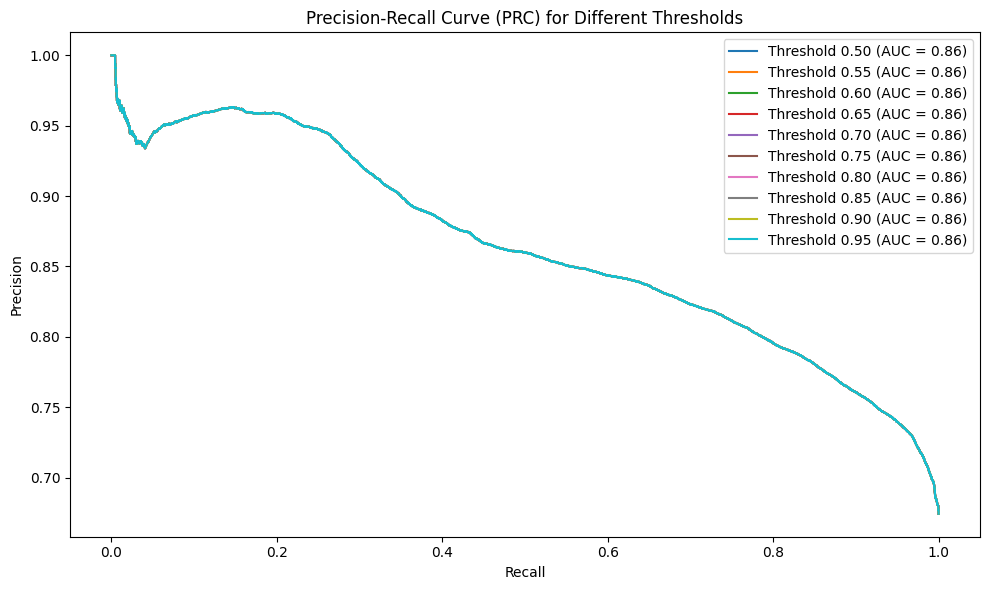

In [ ]:
#Calculate AUC value for Huang et al. (2023) vs Model predictions, the precision, recall, and AUC value at 0.6 threshold is then used (hard coded in the plot below

# Load the data
huang_data_path = 'SingalROI_E1_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E1['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E1['Class_Huang_E1_Range']

# Define thresholds for analysis
thresholds = np.arange(0.5, 1.0, 0.05)

# Initialize lists to store metrics for each threshold
precision_list = []
recall_list = []
f1_list = []
auc_list = []

# Create an empty DataFrame to store the metrics for each threshold
metrics_df = pd.DataFrame(columns=['Threshold', 'Precision', 'Recall', 'F1 Score', 'AUC'])

# Function to calculate confusion matrix and metrics
def calculate_metrics(labels, predictions, threshold):
    cm = confusion_matrix(labels, predictions > threshold)
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # Calculate Precision-Recall curve and AUC
    precision_curve, recall_curve, _ = precision_recall_curve(labels, predictions)
    auc_score = auc(recall_curve, precision_curve)

    return precision, recall, f1_score, auc_score

# Loop through each threshold and calculate metrics
for threshold in thresholds:
    precision, recall, f1_score, auc_score = calculate_metrics(ground_truth, predictions, threshold)

    # Add the results to the metrics dataframe using pd.concat
    new_row = pd.DataFrame({
        'Threshold': [threshold],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1_score],
        'AUC': [auc_score]
    })

    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Print the metrics DataFrame
print(metrics_df)

# Plot the Precision-Recall curve and include AUC in the legend
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    # Get precision and recall for the current threshold
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Plot each threshold with its AUC score in the legend
    plt.plot(recall_curve, precision_curve, label=f'Threshold {threshold:.2f} (AUC = {auc_score:.2f})')

plt.title('Precision-Recall Curve (PRC) for Different Thresholds')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

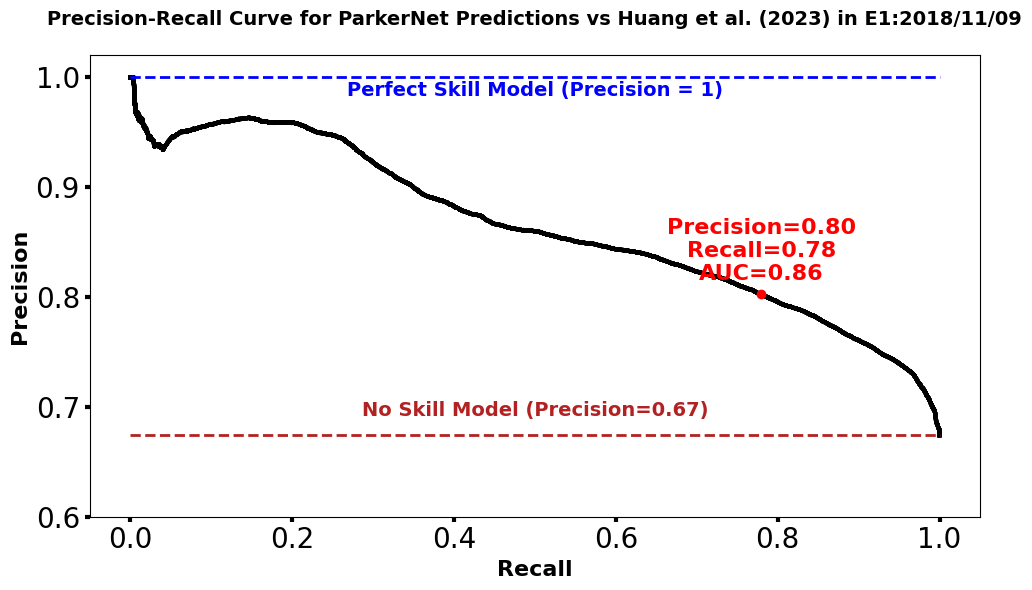

In [ ]:


# Load the data
huang_data_path = 'SingalROI_E1_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E1['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E1['Class_Huang_E1_Range']

# Define thresholds (from 0.5 to 0.95)
thresholds = np.round(np.arange(0.5, 0.95, 0.05), 2)

# Initialize lists to store the Precision-Recall curve and AUC for each threshold
precision_dict = {}
recall_dict = {}
auc_dict = {}

# Calculate Precision-Recall curve and AUC for each threshold
for threshold in thresholds:
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Store precision, recall, and auc values for each threshold
    precision_dict[threshold] = precision_curve
    recall_dict[threshold] = recall_curve
    auc_dict[round(threshold, 2)] = auc_score  # Round threshold to two decimal places

# Plot Precision-Recall curves for all thresholds
plt.figure(figsize=(10, 6))

for threshold in thresholds:
    plt.plot(recall_dict[threshold], precision_dict[threshold], color='black', linewidth=3)

# Provided precision and recall at threshold 0.6
threshold_0_6_precision = 0.802409
threshold_0_6_recall = 0.779662

# Calculate AUC at threshold 0.6
auc_at_06 = auc_dict[0.6]  # AUC for threshold 0.6

# Plot the red dot for threshold 0.6
plt.plot(threshold_0_6_recall, threshold_0_6_precision, 'k-', label=f'Model Precision-Recall curve at 0.60 threshold')

# Calculate No Skill Model baseline
num_positives = np.sum(ground_truth == 1)
num_total = len(ground_truth)
no_skill_precision = num_positives / num_total
no_skill_recall = num_positives / num_total  # Recall is the same as the proportion of positives

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.005),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.97),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')

# Adding labels and title
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Huang et al. (2023) in E1:2018/11/09\n', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(threshold_0_6_recall, threshold_0_6_precision, color='red', zorder=5)

# Add the red dot annotation for threshold 0.6
plt.annotate(f'Precision={threshold_0_6_precision:.2f}\nRecall={threshold_0_6_recall:.2f}\nAUC={auc_at_06:.2f}',
             (threshold_0_6_recall, threshold_0_6_precision),
             textcoords="offset points",
             xytext=(0,10),
             ha='center', fontsize=16, fontweight='bold', color='red')

# Set y-axis limits to ensure the perfect skill line is visible
plt.ylim(0.6, 1.02)
# Customize y-axis ticks to show 0.1 and 0.9
plt.yticks(np.arange(0.6, 1.02, 0.1))  # Set y-ticks from 0 to 1 with step of 0.1

# Apply the tick parameters to all axes after plotting
plt.tick_params(axis='x', labelsize=20, width=3)
plt.tick_params(axis='y', labelsize=20, width=3)


#plt.savefig('E1_Huang_PRC.svg', dpi=600, bbox_inches='tight') #uncomment to save figure
plt.tight_layout()
plt.show()


 (True Negatives):  34052
 (False Positives):  62160
(False Negatives):  33
 (True Positives):  2585
Precision: 0.0399
Recall: 0.9874
F1 Score: 0.0767
Total Switchbacks (Ground Truth 1):  2618
Intersection over Union (IoU): 0.0399
IoU at threshold 0.6: 0.0399


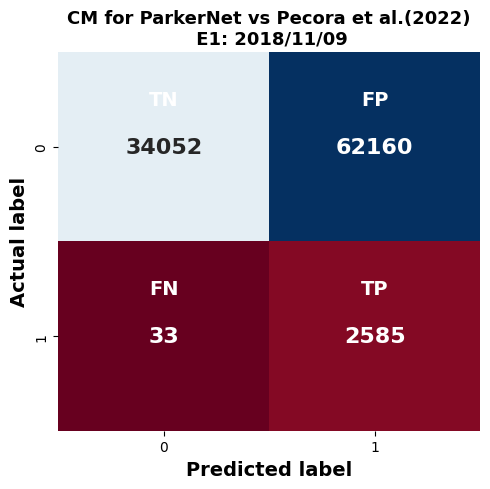

In [10]:


# Load data
pecora_data = pd.read_csv('SignalROI_E1_Pecora_10s_6hr.txt', sep='\t')  # Pecora data
predictions = df_ensemble_E1['Weighted_Voting_AUC_PRC']

# Define threshold
threshold = 0.6

# Create a binary prediction array based on the threshold
binary_predictions = (predictions >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices
ground_truth_pecora = np.zeros_like(binary_predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def plot_cm_and_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)
    if np.all(cm == 0):  # Check if cm is all zeros (invalid case)
        print("Warning: Confusion matrix is all zeros!")
        return None  # Return None if confusion matrix is empty

    # Plot confusion matrix using heatmap
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title(f'CM for ParkerNet vs Pecora et al.(2022)\n E1: 2018/11/09', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')

    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth_pecora, binary_predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
if iou is not None:
    print(f'IoU at threshold {threshold}: {iou:.4f}')

# Show the plot
plt.tight_layout()
plt.savefig('E1_Pecora_CM_1.svg', dpi=600, bbox_inches='tight')  # Save after the plot is created
plt.show()


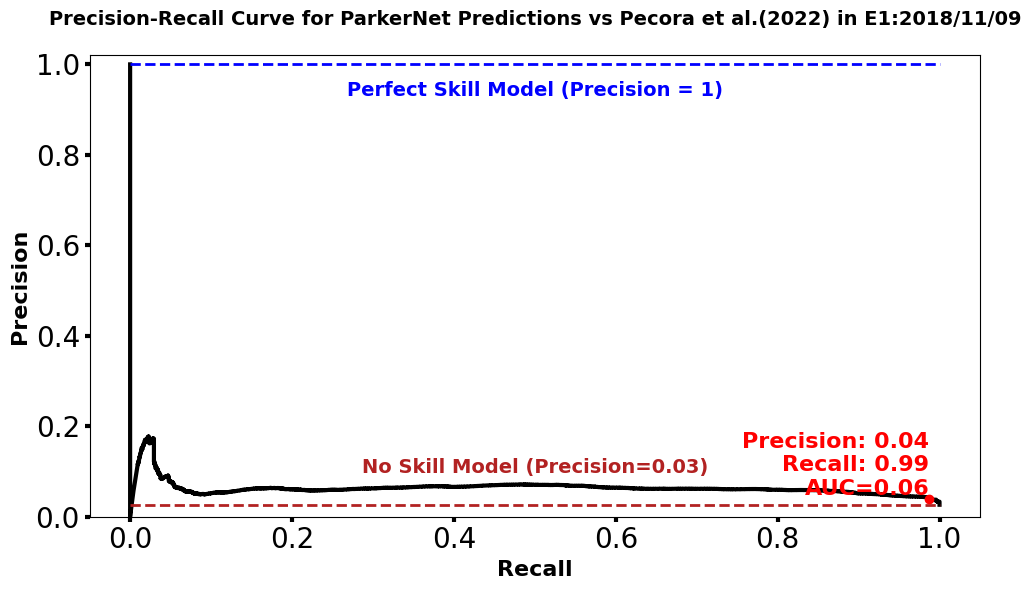

In [ ]:


# Load the Pecora data and model predictions
pecora_data = pd.read_csv('SignalROI_E1_Pecora_10s_6hr.txt', sep='\t')  # Pecora data
predictions = df_ensemble_E1['Weighted_Voting_AUC_PRC']

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Adjust Pecora data based on the start and end indices (10-second window)
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)

# Construct ground truth based on adjusted indices for Pecora data
ground_truth_pecora = np.zeros_like(predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Define thresholds to evaluate
thresholds = np.linspace(0.1, 0.9, 9)

# Initialize list to store metrics
metrics_list = []

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def calculate_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return precision, recall, f1_score

# Evaluate metrics at various thresholds
for threshold in thresholds:
    precision, recall, f1_score = calculate_metrics(ground_truth_pecora, predictions, threshold)
    metrics_list.append({'Threshold': threshold, 'Precision': precision, 'Recall': recall, 'F1 Score': f1_score})

# Convert metrics list to dataframe
metrics_df = pd.DataFrame(metrics_list)

# Plot the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ground_truth_pecora, predictions)

# **Perfect Skill** line will be precision=1, recall=1 across all recall values
perfect_skill = np.ones_like(recall)

# **No Skill** line is precision = the proportion of positive samples in the ground truth
no_skill_precision = np.sum(ground_truth_pecora == 1) / len(ground_truth_pecora)  # Proportion of positive samples
no_skill = np.full_like(recall, no_skill_precision)

# AUC at threshold 0.6
threshold_06_index = np.where(thresholds >= 0.6)[0][0]
precision_at_06 = metrics_df.loc[threshold_06_index, 'Precision']
recall_at_06 = metrics_df.loc[threshold_06_index, 'Recall']
auc_at_06 = auc(recall, precision)  # Calculate AUC value

plt.figure(figsize=(10, 6))

# Plot Precision-Recall Curve
plt.plot(recall, precision, color='black', lw=3, label=f'Model Precision-Recall Curve at 0.6 threshold')

# Plot No Skill line
#plt.plot(recall, no_skill, color='#B22222', linestyle='--', lw=2, label=f'No Skill Model (Precision={no_skill_precision:.2f})')


# Plot Perfect Skill line
#plt.plot(recall, perfect_skill, color='blue', linestyle='--', lw=2, label='Perfect Skill Model (Precision = 1)')

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.04),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.9),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')


# Plot Precision and Recall values at threshold 0.6 directly on the graph
plt.text(recall_at_06, precision_at_06, f'Precision: {precision_at_06:.2f}\nRecall: {recall_at_06:.2f}\nAUC={auc_at_06:.2f}', color='red', fontsize=16, fontweight = 'bold', ha='right', va='bottom')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(recall_at_06, precision_at_06, color='red', zorder=5)

# Labels and Title
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Pecora et al.(2022) in E1:2018/11/09\n', fontsize=14, fontweight='bold')

plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.02, 0.2))

# Increase the size of the x and y axis tick marks
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks
# Add the legend
#plt.legend(loc='upper right', bbox_to_anchor=(1, 0.95), fontsize='large', prop={'weight': 'bold'},labelspacing=0.5, markerscale=1.5)
plt.savefig('E1_Pecora_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


ENCOUNTER 2

In [11]:
# Read in the dataset for predicting (Here we us a dataset containing data from 2019/03/31)
df_E2 = pd.read_csv('PSP_E2_ForPrediction.txt', sep="\t", parse_dates=['Datetime'])

# Separate the 'Class_Huang_Ex' column into df_gt
df_gt_E2 = df_E2[['Class_Huang_E2_Range']].copy()

pd.set_option('future.no_silent_downcasting', True)
df_gt_E2['Class_Huang_E2_Range'] = df_gt_E2['Class_Huang_E2_Range'].replace({True: 1, False: 0}).infer_objects(copy=False).astype(int)
# Create df_test by dropping the 'Class_Huang_Ex' column and other columns not needed
df_test_E2 = df_E2.drop(columns=['Class_Huang_E2_Range'])

df_test_E2.pop("X_HCI")
df_test_E2.pop("Y_HCI")
df_test_E2.pop("Z_HCI")

df_test_E2.head()

,Datetime,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2019-03-31 00:00:00.000,-3.997721,45.038663,23.302035,-38.334248,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
1,2019-03-31 00:00:00.873,-13.131507,42.945250,31.007984,-26.652635,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
2,2019-03-31 00:00:01.747,-25.357215,44.307323,31.124914,-18.745406,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
3,2019-03-31 00:00:02.621,-23.687895,44.224938,22.600516,-29.731221,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
4,2019-03-31 00:00:03.495,-31.643320,44.615896,10.570402,-29.623387,294.085,-76.5423,34.3271,305.815403,83.887267,167.405


In [12]:
df_gt_allpreds_E2 = pd.read_csv('ParkerNet_allModel_averaged_predictions_E2_20190331.csv')
display(df_gt_allpreds_E2)

,Class_Huang_E2_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,Preds_splitM_seed1843,Preds_splitM_seed2221,Preds_splitM_seed3060,Preds_splitM_seed3247,Preds_splitM_seed3364,Preds_splitM_seed3871,Preds_splitM_seed4032,Preds_splitM_seed983,SimpleSoftVoting_Predictions,Weighted_Voting_AUC_PRC
0,0,0.422392,0.585961,0.466262,0.281288,0.187893,0.562691,0.464737,0.506796,0.457028,...,0.449406,0.271625,0.468457,0.598037,0.387381,0.208044,0.683601,0.354430,0.374581,0.376818
1,0,0.412204,0.570724,0.465080,0.280496,0.187789,0.543802,0.466037,0.502321,0.442233,...,0.455070,0.268902,0.460512,0.585766,0.373268,0.205839,0.667094,0.353303,0.367849,0.369994
2,0,0.402828,0.563941,0.467580,0.278630,0.185202,0.525523,0.462305,0.498780,0.426621,...,0.459609,0.265603,0.443564,0.571898,0.362052,0.203486,0.653617,0.354547,0.361386,0.363452
3,0,0.393905,0.552525,0.470586,0.276586,0.185718,0.509937,0.457609,0.499365,0.411058,...,0.461354,0.262435,0.423062,0.561997,0.348418,0.202055,0.643408,0.354376,0.356146,0.358132
4,0,0.391046,0.550934,0.471933,0.274503,0.185165,0.495792,0.453951,0.494039,0.394966,...,0.470763,0.257373,0.414635,0.552588,0.335370,0.201796,0.641709,0.354657,0.351167,0.353071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.308025,0.130611,0.289215,0.281273,0.275734,0.155076,0.229994,0.180083,0.162062,...,0.326440,0.215063,0.144211,0.204924,0.200280,0.571538,0.154677,0.215280,0.221418,0.219197
98826,0,0.308758,0.130066,0.289192,0.281039,0.274774,0.155581,0.230196,0.180308,0.161920,...,0.327769,0.214496,0.144198,0.204056,0.199660,0.570590,0.154232,0.214645,0.221286,0.219068
98827,0,0.306730,0.129967,0.289975,0.280896,0.273919,0.155443,0.229766,0.180504,0.162748,...,0.328980,0.213854,0.144079,0.203349,0.199340,0.569316,0.154423,0.215456,0.221147,0.218940
98828,0,0.309759,0.129773,0.289799,0.280932,0.274068,0.155590,0.229913,0.180333,0.162541,...,0.330886,0.214345,0.144767,0.203487,0.199196,0.569083,0.154508,0.215004,0.221294,0.219084


In [13]:
df_test_E2.reset_index(drop=True, inplace=True)
df_gt_allpreds_E2.reset_index(drop=True, inplace=True)
df_ensemble_E2 = pd.concat([df_gt_allpreds_E2, df_test_E2], axis=1, join='inner')
display(df_ensemble_E2)

,Class_Huang_E2_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,0,0.422392,0.585961,0.466262,0.281288,0.187893,0.562691,0.464737,0.506796,0.457028,...,-3.997721,45.038663,23.302035,-38.334248,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
1,0,0.412204,0.570724,0.465080,0.280496,0.187789,0.543802,0.466037,0.502321,0.442233,...,-13.131507,42.945250,31.007984,-26.652635,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
2,0,0.402828,0.563941,0.467580,0.278630,0.185202,0.525523,0.462305,0.498780,0.426621,...,-25.357215,44.307323,31.124914,-18.745406,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
3,0,0.393905,0.552525,0.470586,0.276586,0.185718,0.509937,0.457609,0.499365,0.411058,...,-23.687895,44.224938,22.600516,-29.731221,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
4,0,0.391046,0.550934,0.471933,0.274503,0.185165,0.495792,0.453951,0.494039,0.394966,...,-31.643320,44.615896,10.570402,-29.623387,294.085,-76.5423,34.3271,305.815403,83.887267,167.405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.308025,0.130611,0.289215,0.281273,0.275734,0.155076,0.229994,0.180083,0.162062,...,-49.065172,54.000127,18.242101,13.260783,282.081,29.3688,45.1307,287.174158,53.845209,162.810
98826,0,0.308758,0.130066,0.289192,0.281039,0.274774,0.155581,0.230196,0.180308,0.161920,...,-47.820400,54.056726,13.197960,21.474471,287.197,15.2066,50.9793,292.082602,53.198963,155.949
98827,0,0.306730,0.129967,0.289975,0.280896,0.273919,0.155443,0.229766,0.180504,0.162748,...,-49.059952,55.101722,9.399047,23.258952,283.175,25.3697,55.8736,289.747410,61.363514,155.117
98828,0,0.309759,0.129773,0.289799,0.280932,0.274068,0.155590,0.229913,0.180333,0.162541,...,-49.960652,55.243783,9.289792,21.668147,280.087,17.2356,44.6739,284.150578,47.883434,163.443


In [ ]:
#df_ensemble_E2['prediction_0.6'] = (df_ensemble_E2['Weighted_Voting_AUC_PRC'] > 0.6).astype(int)
#df_ensemble_E2.to_csv('predictions_E2.csv', index=False)

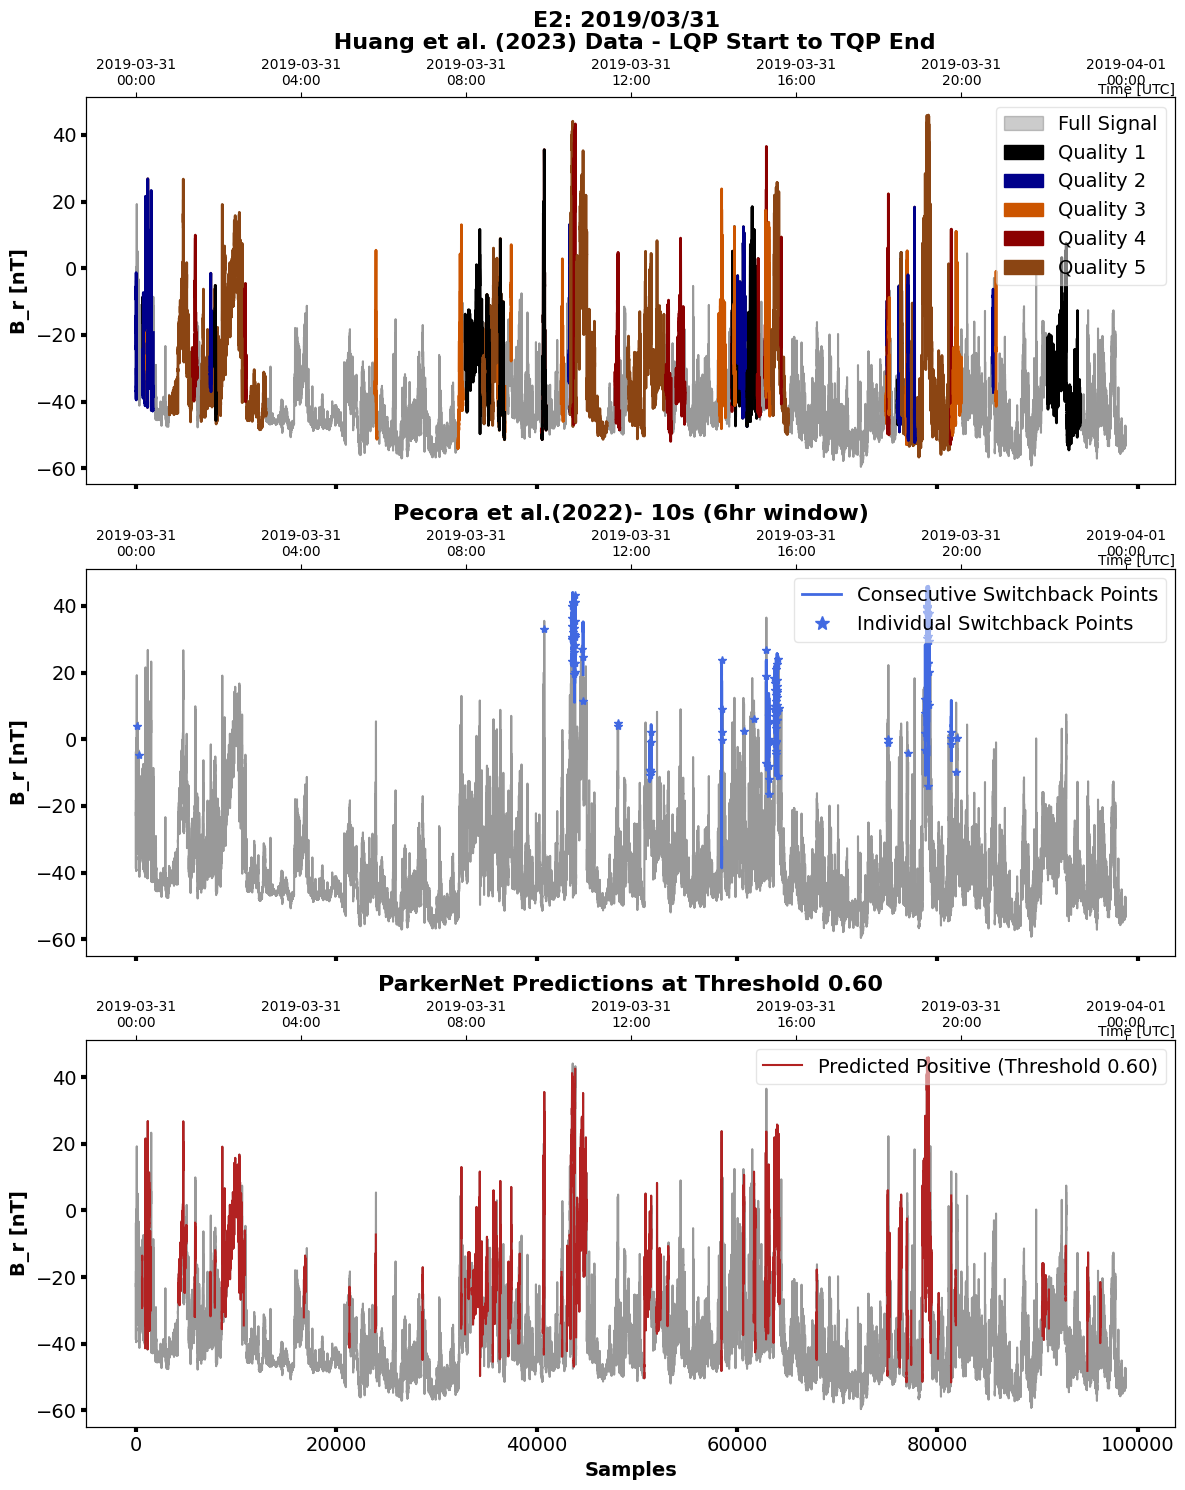

In [14]:
roi_data = pd.read_csv('SingalROI_E2_Huang_allRegions.txt', sep='\t')

signal_data = df_ensemble_E2['B_r']
datetime_axis = df_ensemble_E2['Datetime']

predictions = df_ensemble_E2['Weighted_Voting_AUC_PRC']

# Define the threshold (set to 0.6)
threshold = 0.6

# Define a color map for quality levels
quality_colors = {
    1: 'black',
    2: '#00008B',  # Dark Blue for Quality 1
    3: '#CC5500',  # Burnt Orange for Quality 2
    4: '#8B0000',  # Red Brown for Quality 3
    5: '#8B4513'   # Red Brown for Quality 4
}

# Load the Pecora data 10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E2_Pecora_10s_6hr.txt', sep='\t')

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds
# Create binary mask for predictions based on the threshold
binary_predictions = (predictions > threshold).astype(int)


# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Perform DBSCAN clustering on the start indices
indices = pecora_data['start_index'].values.reshape(-1, 1)  # Reshape for DBSCAN
db = DBSCAN(eps=15, min_samples=2)  # Adjust parameters as needed
labels = db.fit_predict(indices)

# Initialize clusters list
clusters = []

# Group indices by cluster labels
for label in np.unique(labels):
    if label != -1:  # Skip noise
        cluster_indices = indices[labels == label].flatten()
        start_index = int(cluster_indices[0])
        end_index = int(cluster_indices[-1])
        clusters.append((start_index, end_index))


fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]})
# --- Top Subplot: Full Ground Truth Switchbacks (LQP Start to TQP End) for Huang ---
axs[0].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Track legend patches in defined order
legend_patches = [mpatches.Patch(color='black', alpha=0.2, label='Full Signal')]
added_qualities = set()  # Track added quality levels to avoid duplicates

# Plot each switchback (from LQP Start to TQP End) with color based on quality
for _, row in roi_data.iterrows():
    quality_flag = row['QualityFlag']
    color = quality_colors.get(quality_flag, 'gray')  # Default to gray if the quality level is unknown

    # Define start and end points of the full ground truth switchback
    switchback_start = row['LQP_Start_Index']
    switchback_end = row['TQP_End_Index']

    # Plot the full ground truth switchback as a solid line
    axs[0].plot(range(switchback_start, switchback_end), signal_data[switchback_start:switchback_end], color=color, linewidth=2)

    # Add switchback region to legend
    if quality_flag not in added_qualities:
        legend_patches.append(mpatches.Patch(color=color, label=f'Quality {quality_flag}'))
        added_qualities.add(quality_flag)

# Sort the legend patches to display qualities in ascending order
legend_patches = [legend_patches[0]] + sorted(legend_patches[1:], key=lambda x: int(x.get_label().split()[-1]))

# Add legend for the top plot
axs[0].legend(handles=legend_patches, loc='upper right', fontsize=14,framealpha=0.5)
axs[0].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[0].set_title('E2: 2019/03/31 \n Huang et al. (2023) Data - LQP Start to TQP End', fontsize=16, fontweight='bold')

# --- Middle Subplot: Pecora Data (Sparse Points and DBSCAN Segments) ---
axs[1].plot(signal_data, color='black', alpha=0.4, label='Full Signal')

# Plot sparse points as asterisks
sparse_points_color = '#4169E1'  # Royal Blue
for _, row in pecora_data.iterrows():
    start_idx = int(row['start_index'])
    axs[1].plot(start_idx, signal_data[start_idx], marker='*', color=sparse_points_color)

# Plot clustered segments
for start_idx, end_idx in clusters:
    axs[1].plot(range(start_idx, end_idx), signal_data[start_idx:end_idx], color=sparse_points_color, linewidth=2)

# Add legend for Pecora data
pecora_line = Line2D([0], [0], color=sparse_points_color, lw=2, label='Consecutive Switchback Points')
sparse_asterisk = Line2D([0], [0], color=sparse_points_color, marker='*', linestyle='None', markersize=10, label='Individual Switchback Points')
axs[1].legend(handles=[pecora_line, sparse_asterisk], loc='upper right', fontsize=14, framealpha=0.5)

axs[1].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[1].set_title('Pecora et al.(2022)- 10s (6hr window)', fontsize=16, fontweight='bold')

# --- Bottom Subplot: Model Predictions ---
model_prediction_line = signal_data.copy()
model_prediction_line[binary_predictions == 0] = np.nan  # Mask out negative predictions
model_prediction_color = '#B22222'
axs[2].plot(signal_data, color='black', alpha=0.4)
axs[2].plot(model_prediction_line, color=model_prediction_color, linewidth=1.5, label=f'Predicted Positive (Threshold {threshold:.2f})')

axs[2].set_xlabel('Samples', fontsize=14, fontweight='bold')
axs[2].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[2].set_title(f'ParkerNet Predictions at Threshold {threshold:.2f}', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', fontsize=14, framealpha=0.5)


# --- Secondary datetime axis on top, ticks every 4 h ---
start_time    = datetime_axis.min().floor('h')
end_time      = datetime_axis.max().ceil('h')
four_hour_times = pd.date_range(start=start_time, end=end_time, freq='4h')
sample_ticks  = datetime_axis.searchsorted(four_hour_times)
tick_labels   = four_hour_times.strftime('%Y-%m-%d\n%H:%M')

# Apply tick parameters to all axes after plotting
for ax in axs:
    ax.tick_params(axis='x', labelsize=14, width=3)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=14, width=3)  # y-axis ticks
for ax in axs:
    twin = ax.twiny()
    twin.set_xlim(ax.get_xlim())
    twin.set_xticks(sample_ticks)
    twin.set_xticklabels(tick_labels, fontsize=10)
    twin.set_xlabel('Time [UTC]')
    twin.xaxis.label.set_horizontalalignment('right')
    twin.xaxis.set_label_coords(1, 1.01, transform=ax.transAxes)
# Adjust layout and show the plot for Pecora and Model Predictions
plt.tight_layout()

#plt.savefig('APJS_E2.svg', dpi=600, bbox_inches='tight')
#plt.savefig('APJS_E2.pdf', dpi=600, bbox_inches='tight')
plt.show()

#plt.savefig('E2_preds_DBSCAN.svg', dpi=600, bbox_inches='tight')#uncomment to save figure
#plt.show()

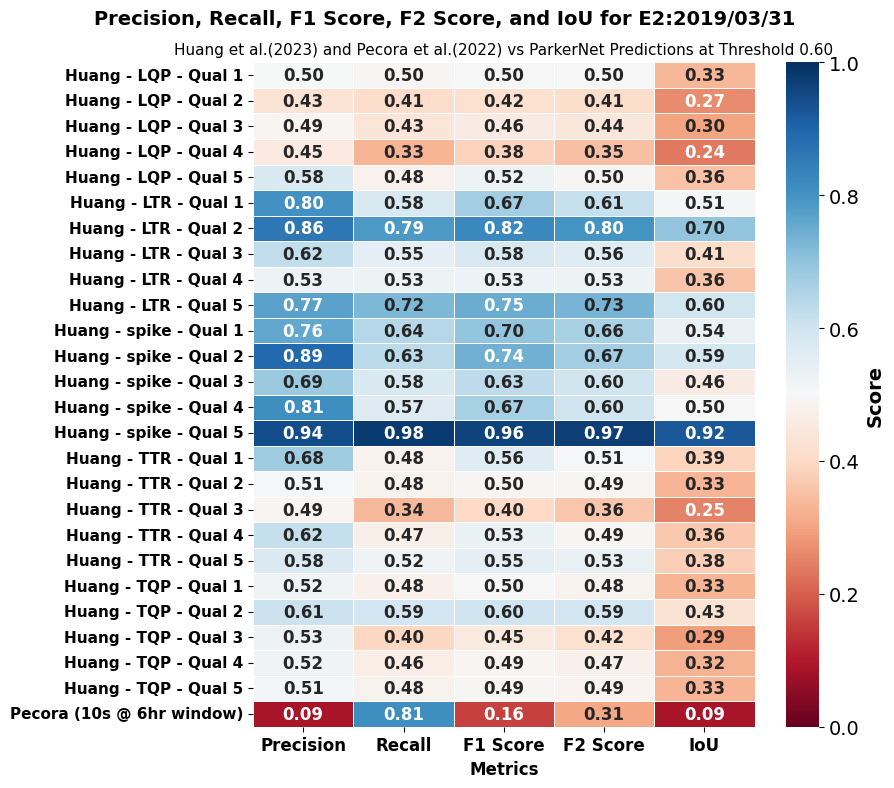

In [15]:


huang_data_path = 'SingalROI_E2_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E2['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E2['Class_Huang_E2_Range']

# Define threshold
threshold = 0.6

# Define regions for Huang ground truths
regions = {
    "LQP": ("LQP_Start_Index", "LQP_End_Index"),
    "LTR": ("LQP_End_Index", "spike_Start_Index"),
    "spike": ("spike_Start_Index", "spike_End_Index"),
    "TTR": ("spike_End_Index", "TQP_Start_Index"),
    "TQP": ("TQP_Start_Index", "TQP_End_Index")
}

# Initialize lists to store Precision, Recall, F1, F2, and IoU values for the heatmap
heatmap_data = []
row_labels = []

# Loop through regions and quality flags for Huang data
for region, (start_col, end_col) in regions.items():
    for quality in sorted(roi_data['QualityFlag'].unique()):
        row_labels.append(f"Huang - {region} - Qual {quality}")
        row_data = []

        # Filter quality rows for the current region and quality
        quality_rows = roi_data[roi_data['QualityFlag'] == quality]
        ground_truth_segment = []

        # Construct ground truth and predictions for the current region and quality
        for _, row in quality_rows.iterrows():
            start, end = row[start_col], row[end_col]
            gt_segment = ground_truth[start:end].values  # Get the ground truth for the segment
            pred_segment = (predictions[start:end] >= threshold).astype(int).values  # Get the predicted values
            ground_truth_segment.extend(gt_segment)
            ground_truth_segment.extend(pred_segment)

        # Calculate confusion matrix
        cm = confusion_matrix(ground_truth_segment[:len(ground_truth_segment)//2], ground_truth_segment[len(ground_truth_segment)//2:])

        # Get TP, FP, FN
        TN, FP, FN, TP = cm.ravel()

        # Calculate Precision, Recall, F1, and F2 for the current region and quality
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        F1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        F2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) != 0 else 0

        # Calculate IoU for the current region and quality
        iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0

        # Append Precision, Recall, F1, F2, IoU results for the current region and quality
        row_data.extend([precision, recall, F1_score, F2_score, iou])

        # Append the data for the current region and quality
        heatmap_data.append(row_data)



#Load Pecora d10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E2_Pecora_10s_6hr.txt', sep = '\t')
# Assuming df_ensemble_E2 contains model predictions
predictions_pecora = df_ensemble_E2['Weighted_Voting_AUC_PRC']

# Create binary predictions based on threshold for Pecora data
binary_predictions_pecora = (predictions_pecora >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices for Pecora (10 seconds)
ground_truth_pecora = np.zeros_like(binary_predictions_pecora)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Calculate Precision, Recall, F1, F2, and IoU for Pecora data (as one whole segment)
cm_pecora = confusion_matrix(ground_truth_pecora, binary_predictions_pecora)
TN_pecora, FP_pecora, FN_pecora, TP_pecora = cm_pecora.ravel()  # Get confusion matrix values

# Calculate Precision, Recall, F1, and F2 for Pecora (single value)
precision_pecora = TP_pecora / (TP_pecora + FP_pecora) if (TP_pecora + FP_pecora) != 0 else 0
recall_pecora = TP_pecora / (TP_pecora + FN_pecora) if (TP_pecora + FN_pecora) != 0 else 0
F1_score_pecora = (2 * precision_pecora * recall_pecora) / (precision_pecora + recall_pecora) if (precision_pecora + recall_pecora) != 0 else 0
F2_score_pecora = (5 * precision_pecora * recall_pecora) / (4 * precision_pecora + recall_pecora) if (4 * precision_pecora + recall_pecora) != 0 else 0

# Calculate IoU for Pecora
iou_pecora = TP_pecora / (TP_pecora + FP_pecora + FN_pecora) if (TP_pecora + FP_pecora + FN_pecora) != 0 else 0

# Append Pecora Precision, Recall, F1, F2, IoU to heatmap data
row_labels.append("Pecora (10s @ 6hr window)")
heatmap_data.append([precision_pecora, recall_pecora, F1_score_pecora, F2_score_pecora, iou_pecora])

# Convert heatmap data to DataFrame
heatmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=["Precision", "Recall", "F1 Score", "F2 Score", "IoU"])

# Plot combined heatmap for Precision, Recall, F1, F2, and IoU (including Huang and Pecora)
fig, ax = plt.subplots(figsize=(9, 8))  # Adjust figure size for better readability

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdBu", cbar_kws={'label': 'Score'},
            annot_kws={"weight": "bold", "size": 12},  # Make annotation bold
            linewidths=0.5,  # Optional: thin line between cells
            cbar=True, vmin=0, vmax=1, ax=ax)  # Set color scale to go from 0 to 1

# Title and labels in bold with line breaks for title
plt.suptitle("Precision, Recall, F1 Score, F2 Score, and IoU for E2:2019/03/31", fontsize=14, fontweight='bold', y=0.98)
ax.set_title("Huang et al.(2023) and Pecora et al.(2022) vs ParkerNet Predictions at Threshold 0.60", fontsize=11, fontweight='normal', loc='center')

# Set xlabel with bold font
ax.set_xlabel("Metrics", fontsize=12, fontweight='bold')

# Make the y-axis labels bold and adjust font size
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontweight='bold')

# Make the legend label bold
cbar = ax.collections[0].colorbar
cbar.set_label('Score', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=12, fontweight = 'bold')
# Adjust layout to ensure everything fits without excessive width

plt.tight_layout()
#plt.savefig('E2_heatmap_1.svg', dpi=600, bbox_inches='tight')
plt.show()




 (True Negatives):  56532
 (False Positives):  1259
(False Negatives):  30586
 (True Positives):  10453
Precision: 0.8925
Recall: 0.2547
F1 Score: 0.3963
Total Switchbacks (Ground Truth 1):  41039
Intersection over Union (IoU): 0.2471


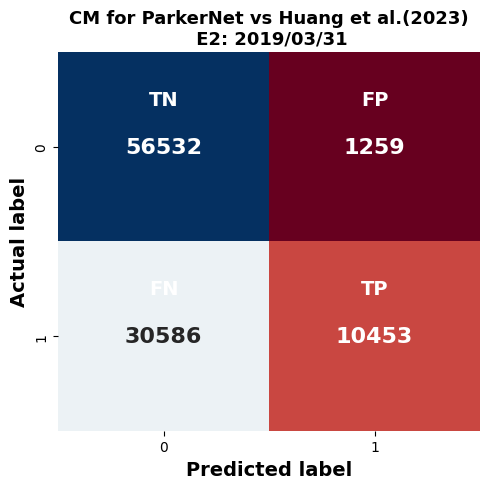

IoU at threshold 0.6: 0.2471


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Load the data
huang_data_path = 'SingalROI_E2_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E2['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E2['Class_Huang_E2_Range']

# Define threshold
threshold = 0.6

# Confusion Matrix Function
def plot_cm_and_metrics(labels, predictions, threshold=0.6):
    # Compute the confusion matrix
    cm = confusion_matrix(labels, predictions > threshold)

    # Plot the confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title('CM for ParkerNet vs Huang et al.(2023)\n E2: 2019/03/31', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')
    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()

    # Position the labels slightly above the center of each section
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')


    #plt.savefig('E2_Huang_CM.svg', dpi=600, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth, predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
print(f'IoU at threshold {threshold}: {iou:.4f}')

<ipython-input-62-80555fcfd893>:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)


   Threshold  Precision    Recall  F1 Score       AUC
0       0.50   0.791728  0.352177  0.487503  0.729596
1       0.55   0.844875  0.302054  0.445011  0.729596
2       0.60   0.892503  0.254709  0.396315  0.729596
3       0.65   0.934010  0.210726  0.343871  0.729596
4       0.70   0.981394  0.151661  0.262721  0.729596
5       0.75   1.000000  0.080095  0.148310  0.729596
6       0.80   1.000000  0.024294  0.047436  0.729596
7       0.85   0.000000  0.000000  0.000000  0.729596
8       0.90   0.000000  0.000000  0.000000  0.729596
9       0.95   0.000000  0.000000  0.000000  0.729596


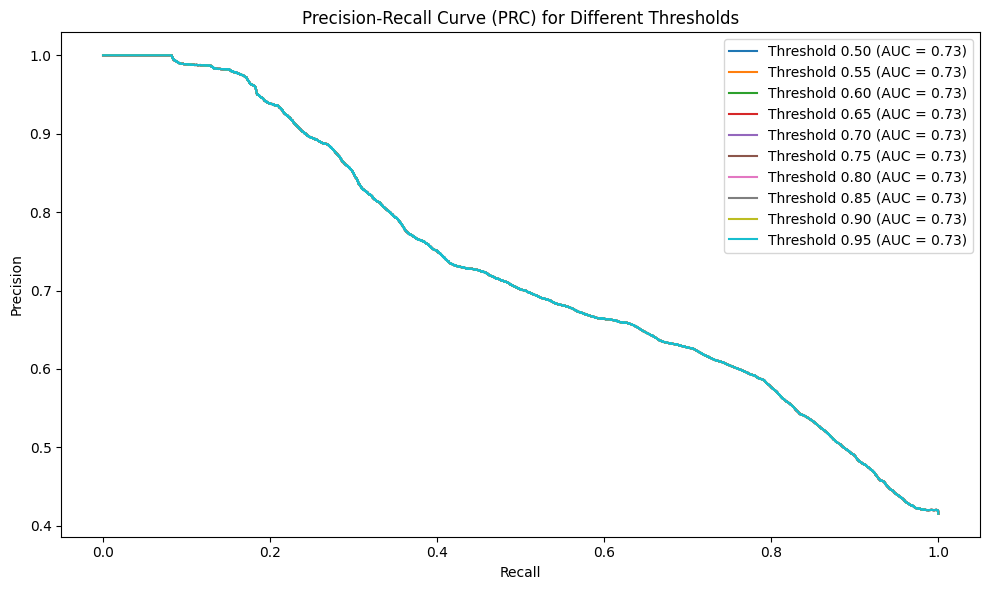

In [ ]:


# Load the data
huang_data_path = 'SingalROI_E2_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')

predictions = df_ensemble_E2['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E2['Class_Huang_E2_Range']

# Define thresholds for analysis
thresholds = np.arange(0.5, 1.0, 0.05)

# Initialize lists to store metrics for each threshold
precision_list = []
recall_list = []
f1_list = []
auc_list = []

# Create an empty DataFrame to store the metrics for each threshold
metrics_df = pd.DataFrame(columns=['Threshold', 'Precision', 'Recall', 'F1 Score', 'AUC'])

# Function to calculate confusion matrix and metrics
def calculate_metrics(labels, predictions, threshold):
    cm = confusion_matrix(labels, predictions > threshold)
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # Calculate Precision-Recall curve and AUC
    precision_curve, recall_curve, _ = precision_recall_curve(labels, predictions)
    auc_score = auc(recall_curve, precision_curve)

    return precision, recall, f1_score, auc_score

# Loop through each threshold and calculate metrics
for threshold in thresholds:
    precision, recall, f1_score, auc_score = calculate_metrics(ground_truth, predictions, threshold)

    # Add the results to the metrics dataframe using pd.concat
    new_row = pd.DataFrame({
        'Threshold': [threshold],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1_score],
        'AUC': [auc_score]
    })

    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Print the metrics DataFrame
print(metrics_df)

# Plot the Precision-Recall curve and include AUC in the legend
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    # Get precision and recall for the current threshold
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Plot each threshold with its AUC score in the legend
    plt.plot(recall_curve, precision_curve, label=f'Threshold {threshold:.2f} (AUC = {auc_score:.2f})')

plt.title('Precision-Recall Curve (PRC) for Different Thresholds')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

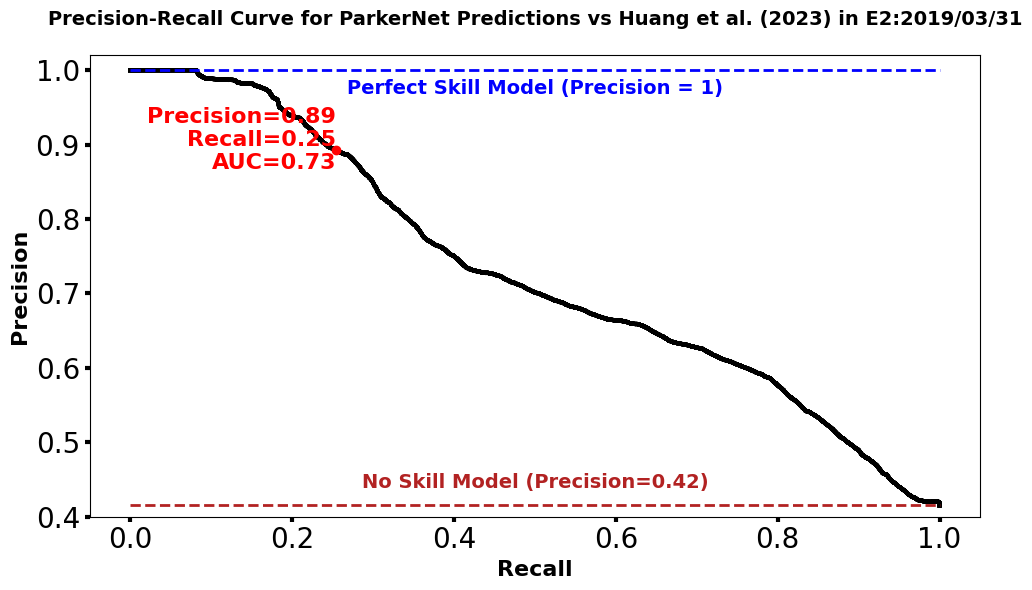

In [ ]:


# Load the data
huang_data_path = 'SingalROI_E2_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')

predictions = df_ensemble_E2['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E2['Class_Huang_E2_Range']

# Define thresholds (from 0.5 to 0.95)
thresholds = np.round(np.arange(0.5, 0.95, 0.05), 2)

# Initialize lists to store the Precision-Recall curve and AUC for each threshold
precision_dict = {}
recall_dict = {}
auc_dict = {}

# Calculate Precision-Recall curve and AUC for each threshold
for threshold in thresholds:
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Store precision, recall, and auc values for each threshold
    precision_dict[threshold] = precision_curve
    recall_dict[threshold] = recall_curve
    auc_dict[round(threshold, 2)] = auc_score  # Round threshold to two decimal places

# Plot Precision-Recall curves for all thresholds
plt.figure(figsize=(10, 6))

for threshold in thresholds:
    plt.plot(recall_dict[threshold], precision_dict[threshold], color='black', linewidth=3)

# Provided precision and recall at threshold 0.6
threshold_0_6_precision = 0.892503
threshold_0_6_recall = 0.254709

# Calculate AUC at threshold 0.6
auc_at_06 = auc_dict[0.6]  # AUC for threshold 0.6

# Plot the red dot for threshold 0.6
plt.plot(threshold_0_6_recall, threshold_0_6_precision, 'k-', label=f'Model Precision-Recall curve at 0.60 threshold')

# Calculate No Skill Model baseline
num_positives = np.sum(ground_truth == 1)
num_total = len(ground_truth)
no_skill_precision = num_positives / num_total
no_skill_recall = num_positives / num_total  # Recall is the same as the proportion of positives

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.005),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.95),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')

# Adding labels and title
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Huang et al. (2023) in E2:2019/03/31\n', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(threshold_0_6_recall, threshold_0_6_precision, color='red', zorder=5)

# Add the red dot annotation for threshold 0.6
plt.annotate(f'Precision={threshold_0_6_precision:.2f}\nRecall={threshold_0_6_recall:.2f}\nAUC={auc_at_06:.2f}',
             (threshold_0_6_recall, threshold_0_6_precision),
             textcoords="offset points",
             xytext=(0,10),
             ha='right', va= 'center_baseline', fontsize=16, fontweight='bold', color='red')

# Set y-axis limits to ensure the perfect skill line is visible
plt.ylim(0.4, 1.02)
# Customize y-axis ticks to show 0.1 and 0.9
plt.yticks(np.arange(0.4, 1.02, 0.1))  # Set y-ticks from 0 to 1 with step of 0.1

# Apply the tick parameters to all axes after plotting
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks

#plt.savefig('E2_HUang_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


 (True Negatives):  86876
 (False Positives):  10678
(False Negatives):  242
 (True Positives):  1034
Precision: 0.0883
Recall: 0.8103
F1 Score: 0.1592
Total Switchbacks (Ground Truth 1):  1276
Intersection over Union (IoU): 0.0865
IoU at threshold 0.6: 0.0865


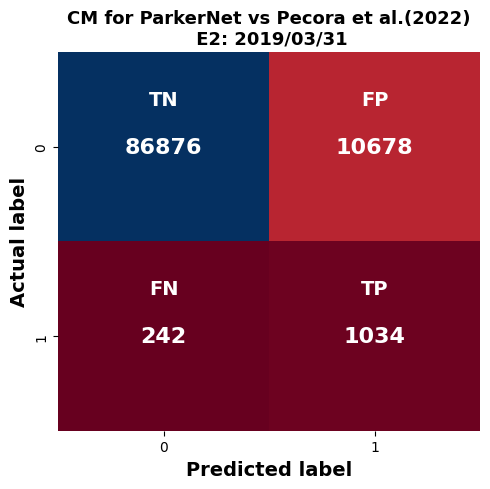

In [17]:



pecora_data = pd.read_csv('SignalROI_E2_Pecora_10s_6hr.txt', sep='\t')
predictions = df_ensemble_E2['Weighted_Voting_AUC_PRC']

# Define threshold
threshold = 0.6

# Create a binary prediction array based on the threshold
binary_predictions = (predictions >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices
ground_truth_pecora = np.zeros_like(binary_predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def plot_cm_and_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)
    if np.all(cm == 0):  # Check if cm is all zeros (invalid case)
        print("Warning: Confusion matrix is all zeros!")
        return None  # Return None if confusion matrix is empty

    # Plot confusion matrix using heatmap
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title(f'CM for ParkerNet vs Pecora et al.(2022)\n E2: 2019/03/31', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')

    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth_pecora, binary_predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
if iou is not None:
    print(f'IoU at threshold {threshold}: {iou:.4f}')

plt.tight_layout()
#plt.savefig('E2_Pecora_CM_1.svg', dpi=600, bbox_inches='tight')  # Save after the plot is created
plt.show()


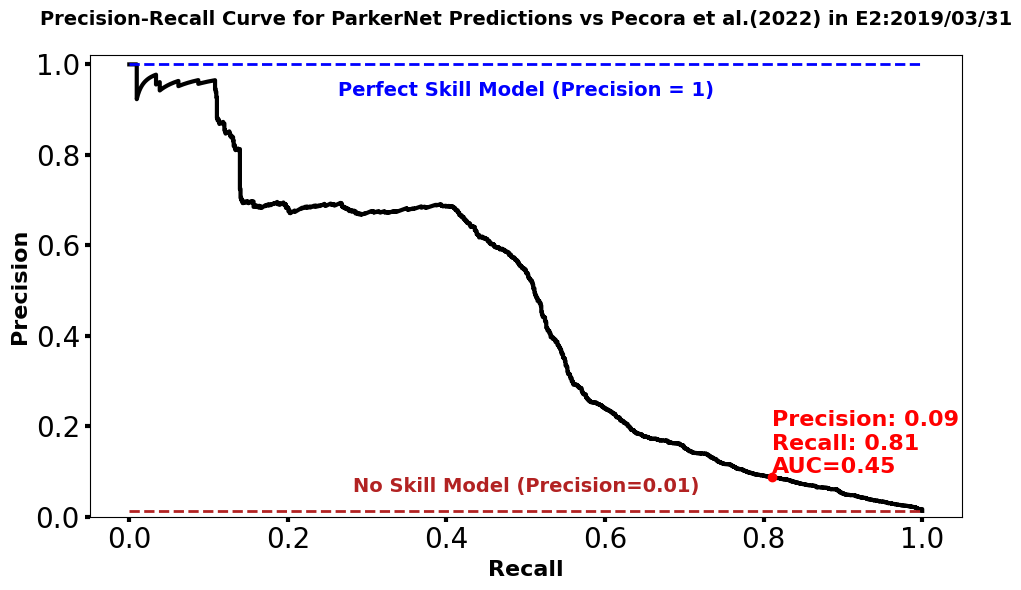

In [ ]:



pecora_data = pd.read_csv('SignalROI_E2_Pecora_10s_6hr.txt', sep='\t')
predictions = df_ensemble_E2['Weighted_Voting_AUC_PRC']

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Adjust Pecora data based on the start and end indices (10-second window)
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)

# Construct ground truth based on adjusted indices for Pecora data
ground_truth_pecora = np.zeros_like(predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Define thresholds to evaluate
thresholds = np.linspace(0.1, 0.9, 9)

# Initialize list to store metrics
metrics_list = []

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def calculate_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return precision, recall, f1_score

# Evaluate metrics at various thresholds
for threshold in thresholds:
    precision, recall, f1_score = calculate_metrics(ground_truth_pecora, predictions, threshold)
    metrics_list.append({'Threshold': threshold, 'Precision': precision, 'Recall': recall, 'F1 Score': f1_score})

# Convert metrics list to dataframe
metrics_df = pd.DataFrame(metrics_list)

# Plot the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ground_truth_pecora, predictions)

# **Perfect Skill** line will be precision=1, recall=1 across all recall values
perfect_skill = np.ones_like(recall)

# **No Skill** line is precision = the proportion of positive samples in the ground truth
no_skill_precision = np.sum(ground_truth_pecora == 1) / len(ground_truth_pecora)  # Proportion of positive samples
no_skill = np.full_like(recall, no_skill_precision)

# AUC at threshold 0.6
threshold_06_index = np.where(thresholds >= 0.6)[0][0]
precision_at_06 = metrics_df.loc[threshold_06_index, 'Precision']
recall_at_06 = metrics_df.loc[threshold_06_index, 'Recall']
auc_at_06 = auc(recall, precision)  # Calculate AUC value

plt.figure(figsize=(10, 6))

# Plot Precision-Recall Curve
plt.plot(recall, precision, color='black', lw=3, label=f'Model Precision-Recall Curve at 0.6 threshold')

# Plot No Skill line
#plt.plot(recall, no_skill, color='#B22222', linestyle='--', lw=2, label=f'No Skill Model (Precision={no_skill_precision:.2f})')


# Plot Perfect Skill line
#plt.plot(recall, perfect_skill, color='blue', linestyle='--', lw=2, label='Perfect Skill Model (Precision = 1)')

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.01),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.9),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')


# Plot Precision and Recall values at threshold 0.6 directly on the graph
plt.text(recall_at_06, precision_at_06, f'Precision: {precision_at_06:.2f}\nRecall: {recall_at_06:.2f}\nAUC={auc_at_06:.2f}', color='red', fontsize=16, fontweight = 'bold', ha='left', va='bottom')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(recall_at_06, precision_at_06, color='red', zorder=5)

# Labels and Title
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Pecora et al.(2022) in E2:2019/03/31\n', fontsize=14, fontweight='bold')

plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.02, 0.2))
# Display the dataframe with metrics at different thresholds
#display(metrics_df)
# Increase the size of the x and y axis tick marks
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks

#plt.savefig('E2_Pecora_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


ENCOUNTER 4

In [18]:
# Read in the dataset for predicting (Here we us a dataset containing data from 2019/03/31)
df_E4 = pd.read_csv('PSP_E4_ForPrediction.txt', sep="\t", parse_dates=['Datetime'])

# Separate the 'Class_Huang_Ex' column into df_gt
df_gt_E4 = df_E4[['Class_Huang_E4_Range']].copy()

pd.set_option('future.no_silent_downcasting', True)
df_gt_E4['Class_Huang_E4_Range'] = df_gt_E4['Class_Huang_E4_Range'].replace({True: 1, False: 0}).infer_objects(copy=False).astype(int)
# Create df_test by dropping the 'Class_Huang_Ex' column and other columns not needed
df_test_E4 = df_E4.drop(columns=['Class_Huang_E4_Range'])

df_test_E4.pop("X_HCI")
df_test_E4.pop("Y_HCI")
df_test_E4.pop("Z_HCI")

df_test_E4.head()

,Datetime,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2020-01-24 00:00:00.000000000,-54.971393,55.505030,6.204191,-4.523532,290.319,-4.53130,-7.78462,290.458697,9.007385,75.6870
1,2020-01-24 00:00:00.873799999,-54.983759,55.503786,5.895654,-4.764215,289.983,5.93158,-27.08480,291.305527,27.726703,77.1261
2,2020-01-24 00:00:01.747599999,-54.749427,55.456405,4.600898,-7.532919,303.232,7.23963,-18.40840,303.876500,19.780835,64.5267
3,2020-01-24 00:00:02.621399999,-54.775518,55.514759,5.824396,-6.899816,287.891,12.67510,-9.14296,288.314897,15.628560,72.8868
4,2020-01-24 00:00:03.495199999,-55.319875,55.828496,4.752707,-5.826167,292.176,6.86250,-12.67550,292.531327,14.413959,75.1667


In [21]:
df_gt_allpreds_E4 = pd.read_csv('ParkerNet_allModel_averaged_predictions_E4_20200124.csv')
display(df_gt_allpreds_E4)

,Class_Huang_E4_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,Preds_splitM_seed1843,Preds_splitM_seed2221,Preds_splitM_seed3060,Preds_splitM_seed3247,Preds_splitM_seed3364,Preds_splitM_seed3871,Preds_splitM_seed4032,Preds_splitM_seed983,SimpleSoftVoting_Predictions,Weighted_Voting_AUC_PRC
0,0,0.225500,0.106970,0.392752,0.201537,0.150364,0.125524,0.228964,0.192794,0.175591,...,0.225955,0.153370,0.119323,0.159710,0.171340,0.147778,0.142810,0.200169,0.175993,0.175623
1,0,0.225432,0.107076,0.394596,0.201684,0.151148,0.125573,0.229211,0.193477,0.175677,...,0.227199,0.153815,0.119333,0.159651,0.171748,0.147727,0.142920,0.201246,0.176232,0.175862
2,0,0.226401,0.107031,0.395282,0.202159,0.151360,0.125634,0.228885,0.194655,0.175807,...,0.227522,0.153916,0.119152,0.159745,0.171430,0.147735,0.142694,0.201445,0.176357,0.175987
3,0,0.226327,0.107098,0.397451,0.202588,0.151330,0.125653,0.228664,0.194406,0.175987,...,0.228092,0.153853,0.119182,0.159857,0.171366,0.147677,0.142857,0.201625,0.176492,0.176125
4,0,0.226108,0.107092,0.399911,0.202303,0.151105,0.125635,0.228947,0.194935,0.175625,...,0.227937,0.153865,0.119128,0.159541,0.171230,0.147450,0.143061,0.201978,0.176559,0.176193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.443982,0.194014,0.347529,0.330143,0.367308,0.177201,0.314858,0.192259,0.157163,...,0.271401,0.512314,0.252469,0.272554,0.413788,0.570779,0.190390,0.363223,0.296802,0.297407
98826,0,0.442554,0.194382,0.348945,0.330629,0.366183,0.177589,0.313551,0.192943,0.157315,...,0.270863,0.516448,0.254195,0.269873,0.415726,0.569725,0.190457,0.360733,0.296722,0.297336
98827,0,0.442976,0.194980,0.349515,0.330920,0.364817,0.176895,0.312067,0.192952,0.158103,...,0.270642,0.522542,0.256023,0.269093,0.420601,0.567960,0.189679,0.357633,0.296993,0.297623
98828,0,0.444663,0.196289,0.350982,0.330797,0.364652,0.177647,0.311237,0.194173,0.158330,...,0.270328,0.523269,0.258553,0.268292,0.427178,0.569208,0.191399,0.353896,0.297416,0.298041


In [22]:
df_test_E4.reset_index(drop=True, inplace=True)
df_gt_allpreds_E4.reset_index(drop=True, inplace=True)
df_ensemble_E4 = pd.concat([df_gt_allpreds_E4, df_test_E4], axis=1, join='inner')
display(df_ensemble_E4)

,Class_Huang_E4_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,0,0.225500,0.106970,0.392752,0.201537,0.150364,0.125524,0.228964,0.192794,0.175591,...,-54.971393,55.505030,6.204191,-4.523532,290.319,-4.53130,-7.78462,290.458697,9.007385,75.6870
1,0,0.225432,0.107076,0.394596,0.201684,0.151148,0.125573,0.229211,0.193477,0.175677,...,-54.983759,55.503786,5.895654,-4.764215,289.983,5.93158,-27.08480,291.305527,27.726703,77.1261
2,0,0.226401,0.107031,0.395282,0.202159,0.151360,0.125634,0.228885,0.194655,0.175807,...,-54.749427,55.456405,4.600898,-7.532919,303.232,7.23963,-18.40840,303.876500,19.780835,64.5267
3,0,0.226327,0.107098,0.397451,0.202588,0.151330,0.125653,0.228664,0.194406,0.175987,...,-54.775518,55.514759,5.824396,-6.899816,287.891,12.67510,-9.14296,288.314897,15.628560,72.8868
4,0,0.226108,0.107092,0.399911,0.202303,0.151105,0.125635,0.228947,0.194935,0.175625,...,-55.319875,55.828496,4.752707,-5.826167,292.176,6.86250,-12.67550,292.531327,14.413959,75.1667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.443982,0.194014,0.347529,0.330143,0.367308,0.177201,0.314858,0.192259,0.157163,...,-51.253870,60.103443,4.883095,31.010000,328.926,19.04000,61.42970,335.154357,64.312749,108.6550
98826,0,0.442554,0.194382,0.348945,0.330629,0.366183,0.177589,0.313551,0.192943,0.157315,...,-50.694612,59.782689,4.016715,31.430753,331.046,29.25060,63.08970,338.271137,69.540692,108.5290
98827,0,0.442976,0.194980,0.349515,0.330920,0.364817,0.176895,0.312067,0.192952,0.158103,...,-50.743110,60.242408,3.893364,32.235480,323.722,20.12880,56.92080,329.303932,60.375045,117.0130
98828,0,0.444663,0.196289,0.350982,0.330797,0.364652,0.177647,0.311237,0.194173,0.158330,...,-52.059228,60.190377,8.101530,29.104699,321.205,18.22770,50.59970,325.676574,53.782699,112.5950


In [ ]:
#df_ensemble_E4['prediction_0.6'] = (df_ensemble_E4['Weighted_Voting_AUC_PRC'] > 0.6).astype(int)
#df_ensemble_E4.to_csv('predictions_E4.csv', index=False)

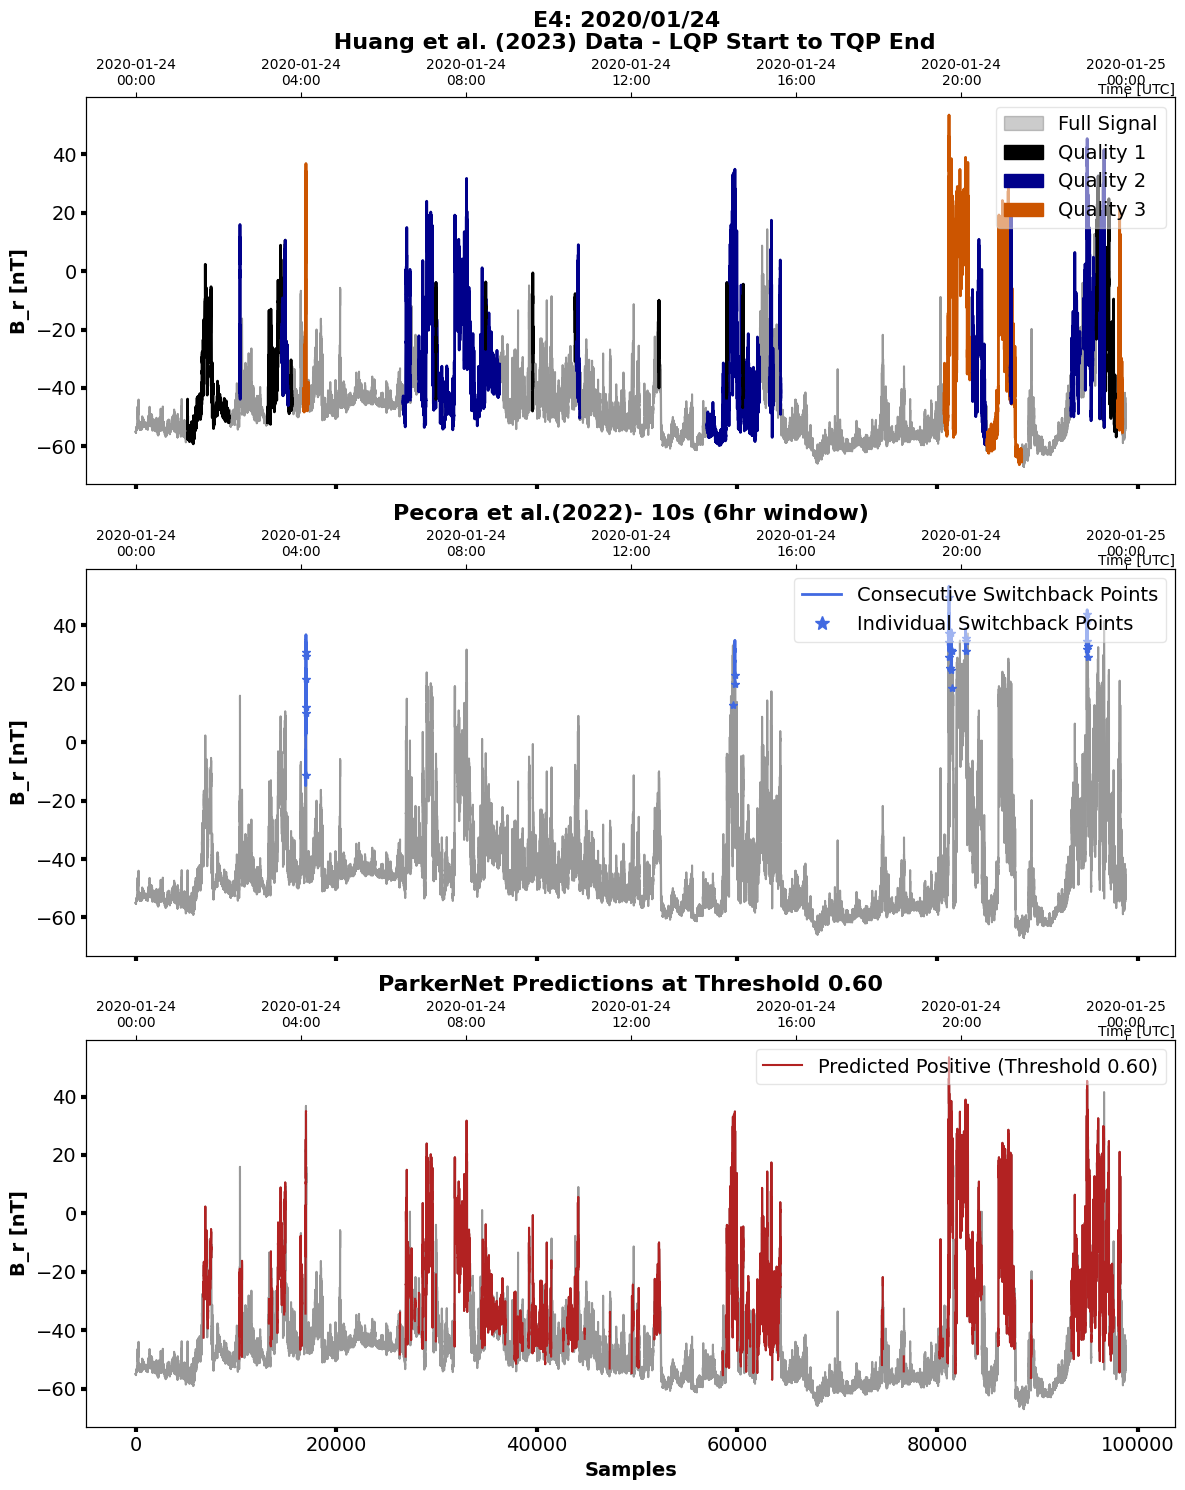

In [23]:


roi_data = pd.read_csv('SingalROI_E4_Huang_allRegions.txt', sep='\t')


signal_data = df_ensemble_E4['B_r']
datetime_axis = df_ensemble_E4['Datetime']
predictions = df_ensemble_E4['Weighted_Voting_AUC_PRC']

# Define the threshold (set to 0.6)
threshold = 0.6

# Define a color map for quality levels
quality_colors = {
    1: 'black',
    2: '#00008B',  # Dark Blue for Quality 1
    3: '#CC5500',  # Burnt Orange for Quality 2
    4: '#8B0000',  # Red Brown for Quality 3
    5: '#8B4513'   # Red Brown for Quality 4
}

# Load the Pecora data 10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E4_Pecora_10s_6hr.txt', sep='\t')

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds
# Create binary mask for predictions based on the threshold
binary_predictions = (predictions > threshold).astype(int)


# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Perform DBSCAN clustering on the start indices
indices = pecora_data['start_index'].values.reshape(-1, 1)  # Reshape for DBSCAN
db = DBSCAN(eps=15, min_samples=2)  # Adjust parameters as needed
labels = db.fit_predict(indices)

# Initialize clusters list
clusters = []

# Group indices by cluster labels
for label in np.unique(labels):
    if label != -1:  # Skip noise
        cluster_indices = indices[labels == label].flatten()
        start_index = int(cluster_indices[0])
        end_index = int(cluster_indices[-1])
        clusters.append((start_index, end_index))

# Create a figure with three subplots (top, middle, bottom)
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]})
# --- Top Subplot: Full Ground Truth Switchbacks (LQP Start to TQP End) for Huang ---
axs[0].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Track legend patches in defined order
legend_patches = [mpatches.Patch(color='black', alpha=0.2, label='Full Signal')]
added_qualities = set()  # Track added quality levels to avoid duplicates

# Plot each switchback (from LQP Start to TQP End) with color based on quality
for _, row in roi_data.iterrows():
    quality_flag = row['QualityFlag']
    color = quality_colors.get(quality_flag, 'gray')  # Default to gray if the quality level is unknown

    # Define start and end points of the full ground truth switchback
    switchback_start = row['LQP_Start_Index']
    switchback_end = row['TQP_End_Index']

    # Plot the full ground truth switchback as a solid line
    axs[0].plot(range(switchback_start, switchback_end), signal_data[switchback_start:switchback_end], color=color, linewidth=2)

    # Add switchback region to legend if not already added
    if quality_flag not in added_qualities:
        legend_patches.append(mpatches.Patch(color=color, label=f'Quality {quality_flag}'))
        added_qualities.add(quality_flag)

# Sort the legend patches to display qualities in ascending order
legend_patches = [legend_patches[0]] + sorted(legend_patches[1:], key=lambda x: int(x.get_label().split()[-1]))

# Add legend for the top plot
axs[0].legend(handles=legend_patches, loc='upper right', fontsize=14,framealpha=0.5)
axs[0].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[0].set_title('E4: 2020/01/24 \n Huang et al. (2023) Data - LQP Start to TQP End', fontsize=16, fontweight='bold')

# --- Middle Subplot: Pecora Data (Sparse Points and DBSCAN Segments) ---
axs[1].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Plot sparse points as asterisks
sparse_points_color = '#4169E1'  # Royal Blue
for _, row in pecora_data.iterrows():
    start_idx = int(row['start_index'])
    axs[1].plot(start_idx, signal_data[start_idx], marker='*', color=sparse_points_color)

# Plot clustered segments
for start_idx, end_idx in clusters:
    axs[1].plot(range(start_idx, end_idx), signal_data[start_idx:end_idx], color=sparse_points_color, linewidth=2)

# Add legend for Pecora data
pecora_line = Line2D([0], [0], color=sparse_points_color, lw=2, label='Consecutive Switchback Points')
sparse_asterisk = Line2D([0], [0], color=sparse_points_color, marker='*', linestyle='None', markersize=10, label='Individual Switchback Points')
axs[1].legend(handles=[pecora_line, sparse_asterisk], loc='upper right', fontsize=14, framealpha=0.5)

axs[1].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[1].set_title('Pecora et al.(2022)- 10s (6hr window)', fontsize=16, fontweight='bold')

# --- Bottom Subplot: Model Predictions ---
model_prediction_line = signal_data.copy()
model_prediction_line[binary_predictions == 0] = np.nan  # Mask out negative predictions
model_prediction_color = '#B22222'
axs[2].plot(signal_data, color='black', alpha=0.4)
axs[2].plot(model_prediction_line, color=model_prediction_color, linewidth=1.5, label=f'Predicted Positive (Threshold {threshold:.2f})')

axs[2].set_xlabel('Samples', fontsize=14, fontweight='bold')
axs[2].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[2].set_title(f'ParkerNet Predictions at Threshold {threshold:.2f}', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', fontsize=14, framealpha=0.5)

# --- Secondary datetime axis on top, ticks every 4 h ---
start_time    = datetime_axis.min().floor('h')
end_time      = datetime_axis.max().ceil('h')
four_hour_times = pd.date_range(start=start_time, end=end_time, freq='4h')
sample_ticks  = datetime_axis.searchsorted(four_hour_times)
tick_labels   = four_hour_times.strftime('%Y-%m-%d\n%H:%M')

# Apply tick parameters to all axes after plotting
for ax in axs:
    ax.tick_params(axis='x', labelsize=14, width=3)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=14, width=3)  # y-axis ticks
for ax in axs:
    twin = ax.twiny()
    twin.set_xlim(ax.get_xlim())
    twin.set_xticks(sample_ticks)
    twin.set_xticklabels(tick_labels, fontsize=10)
    twin.set_xlabel('Time [UTC]')
    twin.xaxis.label.set_horizontalalignment('right')
    twin.xaxis.set_label_coords(1, 1.01, transform=ax.transAxes)
# Adjust layout and show the plot for Pecora and Model Predictions
plt.tight_layout()

plt.savefig('APJS_E4.svg', dpi=600, bbox_inches='tight')
plt.savefig('APJS_E4.pdf', dpi=600, bbox_inches='tight')
plt.show()

#plt.savefig('E4_preds_DBSCAN.svg', dpi=600, bbox_inches='tight')


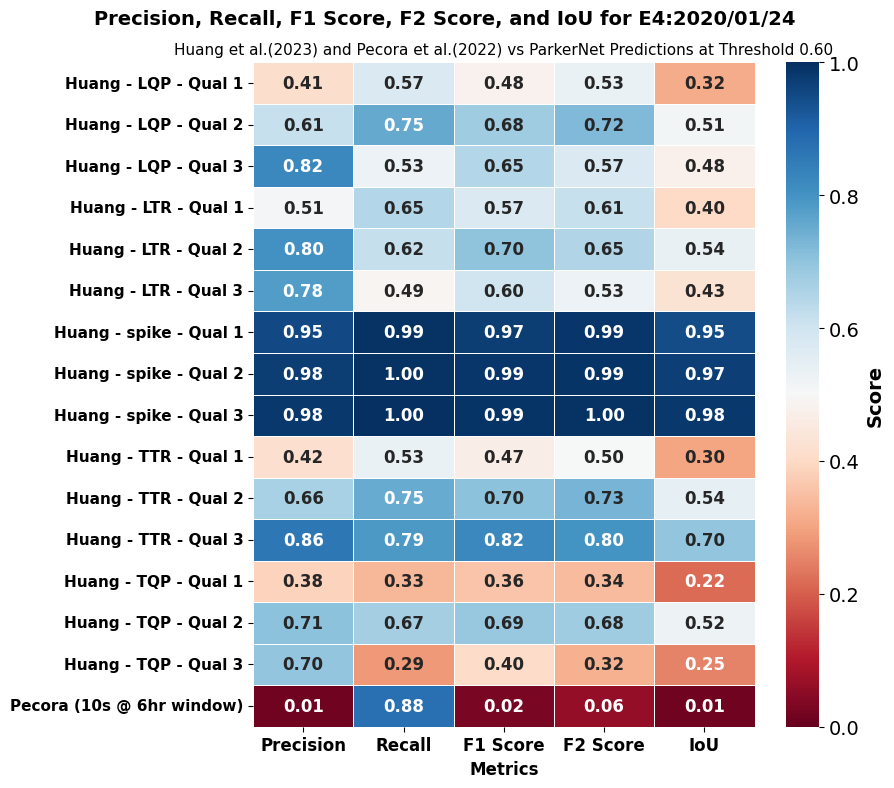

In [24]:

huang_data_path = 'SingalROI_E4_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')

predictions = df_ensemble_E4['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E4['Class_Huang_E4_Range']

# Define threshold
threshold = 0.6

# Define regions for Huang ground truths
regions = {
    "LQP": ("LQP_Start_Index", "LQP_End_Index"),
    "LTR": ("LQP_End_Index", "spike_Start_Index"),
    "spike": ("spike_Start_Index", "spike_End_Index"),
    "TTR": ("spike_End_Index", "TQP_Start_Index"),
    "TQP": ("TQP_Start_Index", "TQP_End_Index")
}

# Initialize lists to store Precision, Recall, F1, F2, and IoU values for the heatmap
heatmap_data = []
row_labels = []

# Loop through regions and quality flags for Huang data
for region, (start_col, end_col) in regions.items():
    for quality in sorted(roi_data['QualityFlag'].unique()):
        row_labels.append(f"Huang - {region} - Qual {quality}")
        row_data = []

        # Filter quality rows for the current region and quality
        quality_rows = roi_data[roi_data['QualityFlag'] == quality]
        ground_truth_segment = []

        # Construct ground truth and predictions for the current region and quality
        for _, row in quality_rows.iterrows():
            start, end = row[start_col], row[end_col]
            gt_segment = ground_truth[start:end].values  # Get the ground truth for the segment
            pred_segment = (predictions[start:end] >= threshold).astype(int).values  # Get the predicted values
            ground_truth_segment.extend(gt_segment)
            ground_truth_segment.extend(pred_segment)

        # Calculate confusion matrix
        cm = confusion_matrix(ground_truth_segment[:len(ground_truth_segment)//2], ground_truth_segment[len(ground_truth_segment)//2:])

        # Get TP, FP, FN
        TN, FP, FN, TP = cm.ravel()

        # Calculate Precision, Recall, F1, and F2 for the current region and quality
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        F1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        F2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) != 0 else 0

        # Calculate IoU for the current region and quality
        iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0

        # Append Precision, Recall, F1, F2, IoU results for the current region and quality
        row_data.extend([precision, recall, F1_score, F2_score, iou])

        # Append the data for the current region and quality
        heatmap_data.append(row_data)



#Load Pecora d10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E4_Pecora_10s_6hr.txt', sep = '\t')
# Assuming df_ensemble_E4 contains model predictions
predictions_pecora = df_ensemble_E4['Weighted_Voting_AUC_PRC']

# Create binary predictions based on threshold for Pecora data
binary_predictions_pecora = (predictions_pecora >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices for Pecora (10 seconds)
ground_truth_pecora = np.zeros_like(binary_predictions_pecora)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Calculate Precision, Recall, F1, F2, and IoU for Pecora data (as one whole segment)
cm_pecora = confusion_matrix(ground_truth_pecora, binary_predictions_pecora)
TN_pecora, FP_pecora, FN_pecora, TP_pecora = cm_pecora.ravel()  # Get confusion matrix values

# Calculate Precision, Recall, F1, and F2 for Pecora (single value)
precision_pecora = TP_pecora / (TP_pecora + FP_pecora) if (TP_pecora + FP_pecora) != 0 else 0
recall_pecora = TP_pecora / (TP_pecora + FN_pecora) if (TP_pecora + FN_pecora) != 0 else 0
F1_score_pecora = (2 * precision_pecora * recall_pecora) / (precision_pecora + recall_pecora) if (precision_pecora + recall_pecora) != 0 else 0
F2_score_pecora = (5 * precision_pecora * recall_pecora) / (4 * precision_pecora + recall_pecora) if (4 * precision_pecora + recall_pecora) != 0 else 0

# Calculate IoU for Pecora
iou_pecora = TP_pecora / (TP_pecora + FP_pecora + FN_pecora) if (TP_pecora + FP_pecora + FN_pecora) != 0 else 0

# Append Pecora Precision, Recall, F1, F2, IoU to heatmap data
row_labels.append("Pecora (10s @ 6hr window)")
heatmap_data.append([precision_pecora, recall_pecora, F1_score_pecora, F2_score_pecora, iou_pecora])

# Convert heatmap data to DataFrame
heatmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=["Precision", "Recall", "F1 Score", "F2 Score", "IoU"])

# Plot combined heatmap for Precision, Recall, F1, F2, and IoU (including Huang and Pecora)
fig, ax = plt.subplots(figsize=(9, 8))  # Adjust figure size for better readability

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdBu", cbar_kws={'label': 'Score'},
            annot_kws={"weight": "bold", "size": 12},  # Make annotation bold
            linewidths=0.5,  # Optional: thin line between cells
            cbar=True, vmin=0, vmax=1, ax=ax)  # Set color scale to go from 0 to 1

# Title and labels in bold with line breaks for title
plt.suptitle("Precision, Recall, F1 Score, F2 Score, and IoU for E4:2020/01/24", fontsize=14, fontweight='bold', y=0.98)
ax.set_title("Huang et al.(2023) and Pecora et al.(2022) vs ParkerNet Predictions at Threshold 0.60", fontsize=11, fontweight='normal', loc='center')

# Set xlabel with bold font
ax.set_xlabel("Metrics", fontsize=12, fontweight='bold')

# Make the y-axis labels bold and adjust font size
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontweight='bold')

# Make the legend label bold
cbar = ax.collections[0].colorbar
cbar.set_label('Score', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=12, fontweight = 'bold')
# Adjust layout to ensure everything fits without excessive width

plt.tight_layout()
#plt.savefig('E4_heatmap_1.svg', dpi=600, bbox_inches='tight')
plt.show()


 (True Negatives):  58549
 (False Positives):  6251
(False Negatives):  18102
 (True Positives):  15928
Precision: 0.7182
Recall: 0.4681
F1 Score: 0.5667
Total Switchbacks (Ground Truth 1):  34030
Intersection over Union (IoU): 0.3954


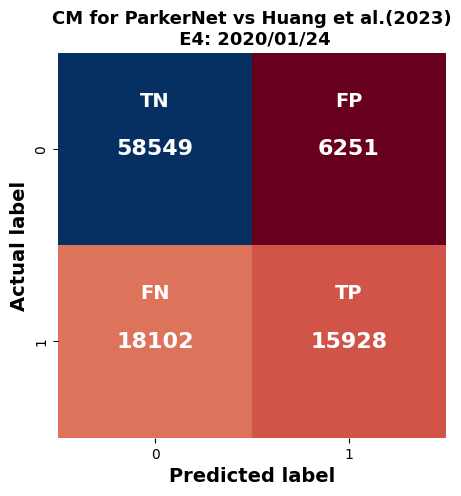

IoU at threshold 0.6: 0.3954


In [25]:


huang_data_path = 'SingalROI_E4_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E4['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E4['Class_Huang_E4_Range']

# Define threshold
threshold = 0.6

# Confusion Matrix Function
def plot_cm_and_metrics(labels, predictions, threshold=0.6):
    # Compute the confusion matrix
    cm = confusion_matrix(labels, predictions > threshold)

    # Plot the confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title('CM for ParkerNet vs Huang et al.(2023)\n E4: 2020/01/24', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')
    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()

    # Position the labels slightly above the center of each section
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # Show the plot
    #plt.savefig('E4_Huang_CM.svg', dpi=600, bbox_inches='tight')
    #plt.tight_layout()
    plt.show()

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth, predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
print(f'IoU at threshold {threshold}: {iou:.4f}')

<ipython-input-75-bee8519d50ea>:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)


   Threshold  Precision    Recall  F1 Score       AUC
0       0.50   0.658133  0.550720  0.599654  0.685741
1       0.55   0.688134  0.510550  0.586187  0.685741
2       0.60   0.718157  0.468058  0.566742  0.685741
3       0.65   0.747834  0.415957  0.534575  0.685741
4       0.70   0.785690  0.339788  0.474409  0.685741
5       0.75   0.852371  0.271466  0.411786  0.685741
6       0.80   0.920063  0.153894  0.263683  0.685741
7       0.85   0.000000  0.000000  0.000000  0.685741
8       0.90   0.000000  0.000000  0.000000  0.685741
9       0.95   0.000000  0.000000  0.000000  0.685741


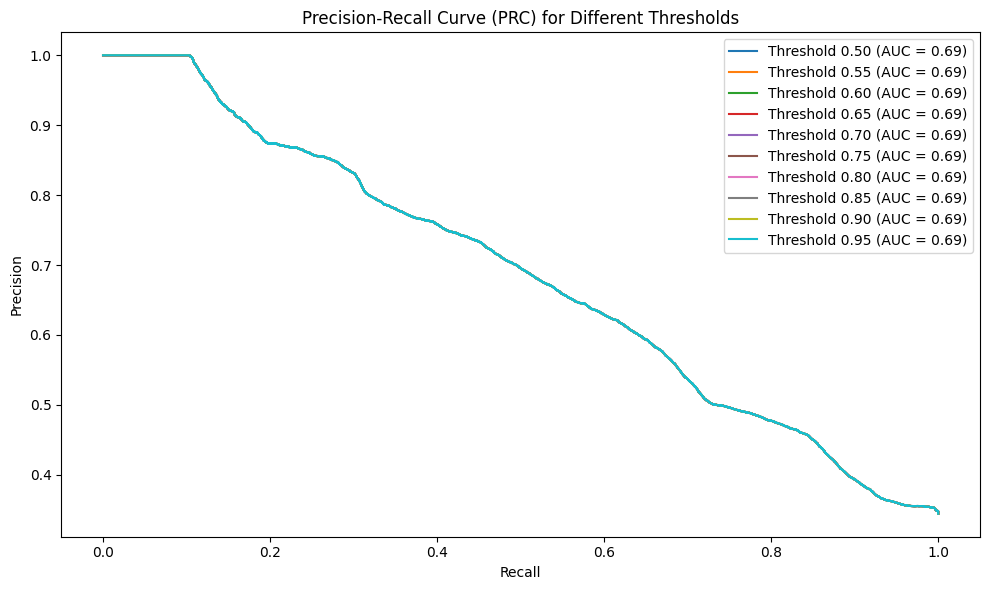

In [ ]:



huang_data_path = 'SingalROI_E4_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E4['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E4['Class_Huang_E4_Range']

# Define thresholds for analysis
thresholds = np.arange(0.5, 1.0, 0.05)

# Initialize lists to store metrics for each threshold
precision_list = []
recall_list = []
f1_list = []
auc_list = []

# Create an empty DataFrame to store the metrics for each threshold
metrics_df = pd.DataFrame(columns=['Threshold', 'Precision', 'Recall', 'F1 Score', 'AUC'])

# Function to calculate confusion matrix and metrics
def calculate_metrics(labels, predictions, threshold):
    cm = confusion_matrix(labels, predictions > threshold)
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # Calculate Precision-Recall curve and AUC
    precision_curve, recall_curve, _ = precision_recall_curve(labels, predictions)
    auc_score = auc(recall_curve, precision_curve)

    return precision, recall, f1_score, auc_score

# Loop through each threshold and calculate metrics
for threshold in thresholds:
    precision, recall, f1_score, auc_score = calculate_metrics(ground_truth, predictions, threshold)

    # Add the results to the metrics dataframe using pd.concat
    new_row = pd.DataFrame({
        'Threshold': [threshold],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1_score],
        'AUC': [auc_score]
    })

    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Print the metrics DataFrame
print(metrics_df)

# Plot the Precision-Recall curve and include AUC in the legend
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    # Get precision and recall for the current threshold
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Plot each threshold with its AUC score in the legend
    plt.plot(recall_curve, precision_curve, label=f'Threshold {threshold:.2f} (AUC = {auc_score:.2f})')

plt.title('Precision-Recall Curve (PRC) for Different Thresholds')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

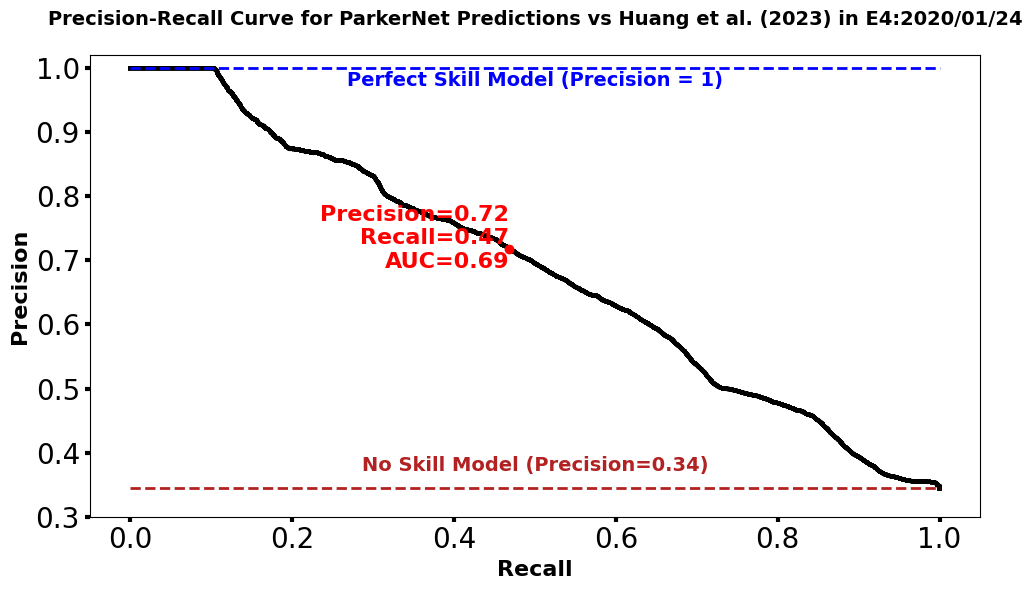

In [ ]:


huang_data_path = 'SingalROI_E4_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E4['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E4['Class_Huang_E4_Range']

# Define thresholds (from 0.5 to 0.95)
thresholds = np.round(np.arange(0.5, 0.95, 0.05), 2)

# Initialize lists to store the Precision-Recall curve and AUC for each threshold
precision_dict = {}
recall_dict = {}
auc_dict = {}

# Calculate Precision-Recall curve and AUC for each threshold
for threshold in thresholds:
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Store precision, recall, and auc values for each threshold
    precision_dict[threshold] = precision_curve
    recall_dict[threshold] = recall_curve
    auc_dict[round(threshold, 2)] = auc_score  # Round threshold to two decimal places

# Plot Precision-Recall curves for all thresholds
plt.figure(figsize=(10, 6))

for threshold in thresholds:
    plt.plot(recall_dict[threshold], precision_dict[threshold], color='black', linewidth=3)

# Provided precision and recall at threshold 0.6
threshold_0_6_precision = 0.718157
threshold_0_6_recall =  0.468058

# Calculate AUC at threshold 0.6
auc_at_06 = auc_dict[0.6]  # AUC for threshold 0.6

# Plot the red dot for threshold 0.6
plt.plot(threshold_0_6_recall, threshold_0_6_precision, 'k-', label=f'Model Precision-Recall curve at 0.60 threshold')

# Calculate No Skill Model baseline
num_positives = np.sum(ground_truth == 1)
num_total = len(ground_truth)
no_skill_precision = num_positives / num_total
no_skill_recall = num_positives / num_total  # Recall is the same as the proportion of positives

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.005),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.95),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')

# Adding labels and title
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Huang et al. (2023) in E4:2020/01/24\n', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(threshold_0_6_recall, threshold_0_6_precision, color='red', zorder=5)

# Add the red dot annotation for threshold 0.6
plt.annotate(f'Precision={threshold_0_6_precision:.2f}\nRecall={threshold_0_6_recall:.2f}\nAUC={auc_at_06:.2f}',
             (threshold_0_6_recall, threshold_0_6_precision),
             textcoords="offset points",
             xytext=(0,10),
             ha='right', va= 'center_baseline', fontsize=16, fontweight='bold', color='red')

# Set y-axis limits to ensure the perfect skill line is visible
plt.ylim(0.3, 1.02)
# Customize y-axis ticks to show 0.1 and 0.9
plt.yticks(np.arange(0.3, 1.02, 0.1))  # Set y-ticks from 0 to 1 with step of 0.1

# Apply the tick parameters to all axes after plotting
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks


#plt.savefig('E4_Huang_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


 (True Negatives):  76612
 (False Positives):  21899
(False Negatives):  39
 (True Positives):  280
Precision: 0.0126
Recall: 0.8777
F1 Score: 0.0249
Total Switchbacks (Ground Truth 1):  319
Intersection over Union (IoU): 0.0126
IoU at threshold 0.6: 0.0126


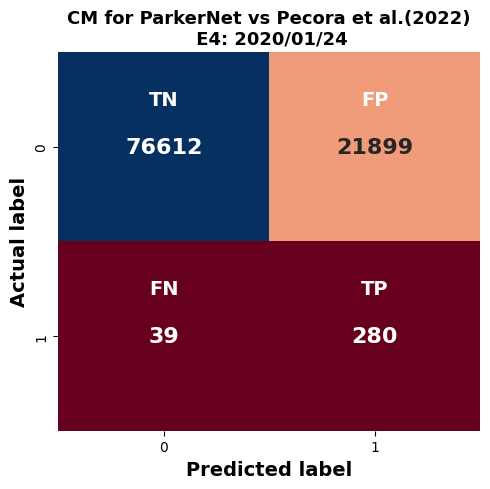

In [26]:



pecora_data = pd.read_csv('SignalROI_E4_Pecora_10s_6hr.txt', sep='\t')  # Pecora data

predictions = df_ensemble_E4['Weighted_Voting_AUC_PRC']

# Define threshold
threshold = 0.6

# Create a binary prediction array based on the threshold
binary_predictions = (predictions >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices
ground_truth_pecora = np.zeros_like(binary_predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def plot_cm_and_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)
    if np.all(cm == 0):  # Check if cm is all zeros (invalid case)
        print("Warning: Confusion matrix is all zeros!")
        return None  # Return None if confusion matrix is empty

    # Plot confusion matrix using heatmap
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title(f'CM for ParkerNet vs Pecora et al.(2022)\n E4: 2020/01/24', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')

    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth_pecora, binary_predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
if iou is not None:
    print(f'IoU at threshold {threshold}: {iou:.4f}')

# Show the plot
plt.tight_layout()
#plt.savefig('E4_Pecora_CM_1.svg', dpi=600, bbox_inches='tight')  # Save after the plot is created
plt.show()


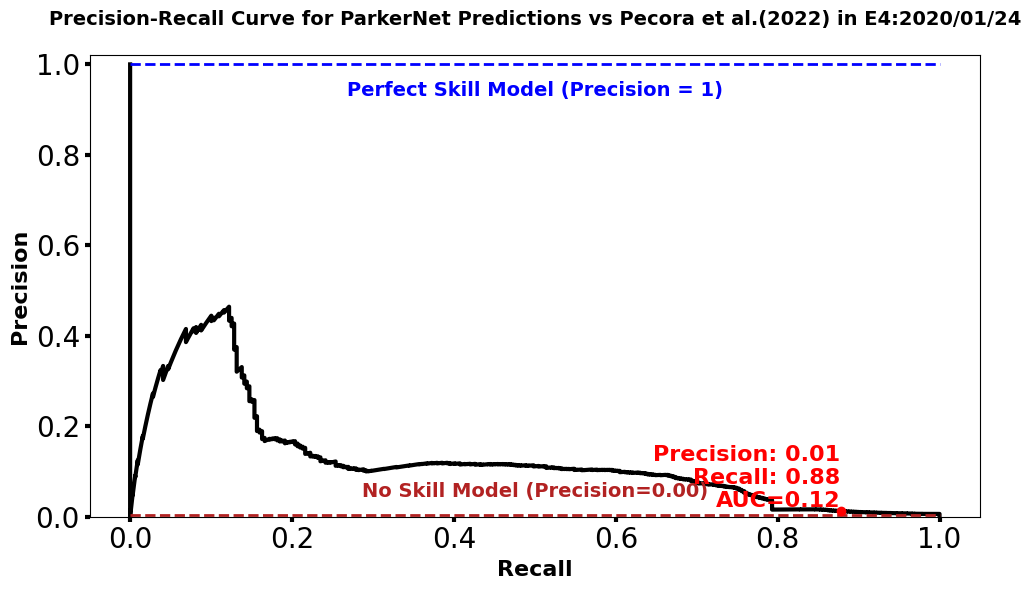

In [ ]:



pecora_data = pd.read_csv('SignalROI_E4_Pecora_10s_6hr.txt', sep='\t')  # Pecora data
predictions = df_ensemble_E4['Weighted_Voting_AUC_PRC']

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Adjust Pecora data based on the start and end indices (10-second window)
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)

# Construct ground truth based on adjusted indices for Pecora data
ground_truth_pecora = np.zeros_like(predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Define thresholds to evaluate
thresholds = np.linspace(0.1, 0.9, 9)

# Initialize list to store metrics
metrics_list = []

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def calculate_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return precision, recall, f1_score

# Evaluate metrics at various thresholds
for threshold in thresholds:
    precision, recall, f1_score = calculate_metrics(ground_truth_pecora, predictions, threshold)
    metrics_list.append({'Threshold': threshold, 'Precision': precision, 'Recall': recall, 'F1 Score': f1_score})

# Convert metrics list to dataframe
metrics_df = pd.DataFrame(metrics_list)

# Plot the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ground_truth_pecora, predictions)

# **Perfect Skill** line will be precision=1, recall=1 across all recall values
perfect_skill = np.ones_like(recall)

# **No Skill** line is precision = the proportion of positive samples in the ground truth
no_skill_precision = np.sum(ground_truth_pecora == 1) / len(ground_truth_pecora)  # Proportion of positive samples
no_skill = np.full_like(recall, no_skill_precision)

# AUC at threshold 0.6
threshold_06_index = np.where(thresholds >= 0.6)[0][0]
precision_at_06 = metrics_df.loc[threshold_06_index, 'Precision']
recall_at_06 = metrics_df.loc[threshold_06_index, 'Recall']
auc_at_06 = auc(recall, precision)  # Calculate AUC value

plt.figure(figsize=(10, 6))

# Plot Precision-Recall Curve
plt.plot(recall, precision, color='black', lw=3, label=f'Model Precision-Recall Curve at 0.6 threshold')


# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.01),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.9),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')


# Plot Precision and Recall values at threshold 0.6 directly on the graph
plt.text(recall_at_06, precision_at_06, f'Precision: {precision_at_06:.2f}\nRecall: {recall_at_06:.2f}\nAUC={auc_at_06:.2f}', color='red', fontsize=16, fontweight = 'bold', ha='right', va='bottom')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(recall_at_06, precision_at_06, color='red', zorder=5)

# Labels and Title
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Pecora et al.(2022) in E4:2020/01/24\n', fontsize=14, fontweight='bold')

plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.02, 0.2))
# Display the dataframe with metrics at different thresholds
#display(metrics_df)
# Increase the size of the x and y axis tick marks
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks
#
plt.savefig('E4_Pecora_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


ENCOUNTER 5

In [27]:
# Read in the dataset for predicting (provided as PSP_EX_yyyymmdd.txt)
df_E5 = pd.read_csv('PSP_E5_ForPrediction.txt', sep="\t", parse_dates=['Datetime'])

# Separate the 'Class_Huang_Ex' column into df_gt
df_gt_E5 = df_E5[['Class_Huang_E5_Range']].copy()

pd.set_option('future.no_silent_downcasting', True)
df_gt_E5['Class_Huang_E5_Range'] = df_gt_E5['Class_Huang_E5_Range'].replace({True: 1, False: 0}).infer_objects(copy=False).astype(int)
# Create df_test by dropping the 'Class_Huang_Ex' column and other columns not needed
df_test_E5= df_E5.drop(columns=['Class_Huang_E5_Range'])

df_test_E5.pop("X_HCI")
df_test_E5.pop("Y_HCI")
df_test_E5.pop("Z_HCI")

display(df_test_E5)

,Datetime,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2020-06-02 00:00:00.000000000,-27.592036,29.318841,1.956524,9.718333,311.194,-48.0702,-0.768381,314.885757,48.076341,183.734
1,2020-06-02 00:00:00.873799999,-27.443860,28.840827,2.098728,8.615290,311.553,-46.0696,7.363930,315.026836,46.654426,186.180
2,2020-06-02 00:00:01.747599999,-26.108516,28.161881,0.811848,10.525106,311.553,-46.0696,7.363930,315.026836,46.654426,186.180
3,2020-06-02 00:00:02.621399999,-26.550831,28.078335,1.747833,8.966119,312.886,-12.2667,-8.105480,313.231256,14.702746,182.125
4,2020-06-02 00:00:03.495199999,-24.769987,26.692135,1.405073,9.845992,318.381,-23.2815,12.811000,319.488045,26.573482,178.699
...,...,...,...,...,...,...,...,...,...,...,...
98875,2020-06-02 23:59:56.974996393,-40.309145,40.570341,-4.493635,0.965746,328.089,19.2629,-9.276990,328.784905,21.380408,170.089
98876,2020-06-02 23:59:57.848796393,-40.228346,40.841325,-7.016675,0.678428,327.969,22.0974,-20.759900,329.367475,30.319442,170.406
98877,2020-06-02 23:59:58.722596393,-39.698305,40.351528,-6.809375,2.433682,329.315,14.9919,-10.163800,329.812718,18.112424,188.329
98878,2020-06-02 23:59:59.596396393,-39.985005,40.647352,-7.278989,0.650318,329.102,29.4088,-7.310450,330.494246,30.303798,154.547


In [28]:
df_gt_allpreds_E5 = pd.read_csv('ParkerNet_allModel_averaged_predictions_E5_20200602.csv')
display(df_gt_allpreds_E5)

,Class_Huang_E5_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,Preds_splitM_seed1843,Preds_splitM_seed2221,Preds_splitM_seed3060,Preds_splitM_seed3247,Preds_splitM_seed3364,Preds_splitM_seed3871,Preds_splitM_seed4032,Preds_splitM_seed983,SimpleSoftVoting_Predictions,Weighted_Voting_AUC_PRC
0,0,0.570763,0.232343,0.485112,0.218837,0.181074,0.279574,0.283530,0.359763,0.256038,...,0.420954,0.204374,0.213345,0.252535,0.477024,0.347302,0.289034,0.194853,0.263074,0.262535
1,0,0.581264,0.231433,0.486383,0.220744,0.181846,0.283924,0.283317,0.364633,0.254886,...,0.420197,0.205000,0.216166,0.257802,0.488370,0.347854,0.295459,0.193695,0.265213,0.264738
2,0,0.585416,0.230878,0.489951,0.220401,0.181252,0.287227,0.285218,0.362337,0.250931,...,0.421066,0.207847,0.214420,0.258340,0.492982,0.346792,0.303363,0.192269,0.266347,0.265901
3,0,0.582163,0.231016,0.487332,0.220603,0.181804,0.289521,0.286117,0.357625,0.250020,...,0.419594,0.206610,0.218909,0.261824,0.488293,0.345434,0.304344,0.190109,0.266299,0.265851
4,0,0.592827,0.233985,0.484828,0.222116,0.181310,0.296338,0.284956,0.358371,0.247371,...,0.416350,0.205214,0.222505,0.265832,0.494649,0.347743,0.313354,0.192305,0.267996,0.267612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.273166,0.339677,0.424618,0.240860,0.344644,0.194452,0.341054,0.235415,0.204123,...,0.530829,0.209715,0.164272,0.191555,0.242123,0.315788,0.206032,0.248111,0.248949,0.246707
98826,0,0.273329,0.337241,0.423686,0.241588,0.344217,0.193519,0.340889,0.235549,0.204281,...,0.529474,0.211307,0.164087,0.192257,0.243150,0.315516,0.205692,0.247884,0.248804,0.246567
98827,0,0.273511,0.339482,0.421830,0.241563,0.343308,0.193554,0.340425,0.235538,0.204569,...,0.527778,0.210531,0.164777,0.192633,0.243361,0.316367,0.205436,0.247556,0.248855,0.246623
98828,0,0.273603,0.342966,0.421230,0.242303,0.342296,0.194399,0.340445,0.234805,0.204437,...,0.526034,0.210374,0.165485,0.192876,0.244949,0.318525,0.204730,0.247102,0.249114,0.246886


In [29]:
df_test_E5.reset_index(drop=True, inplace=True)
df_gt_allpreds_E5.reset_index(drop=True, inplace=True)
df_ensemble_E5 = pd.concat([df_gt_allpreds_E5, df_test_E5], axis=1, join='inner')
display(df_ensemble_E5)

,Class_Huang_E5_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,0,0.570763,0.232343,0.485112,0.218837,0.181074,0.279574,0.283530,0.359763,0.256038,...,-27.592036,29.318841,1.956524,9.718333,311.194,-48.0702,-0.768381,314.885757,48.076341,183.734
1,0,0.581264,0.231433,0.486383,0.220744,0.181846,0.283924,0.283317,0.364633,0.254886,...,-27.443860,28.840827,2.098728,8.615290,311.553,-46.0696,7.363930,315.026836,46.654426,186.180
2,0,0.585416,0.230878,0.489951,0.220401,0.181252,0.287227,0.285218,0.362337,0.250931,...,-26.108516,28.161881,0.811848,10.525106,311.553,-46.0696,7.363930,315.026836,46.654426,186.180
3,0,0.582163,0.231016,0.487332,0.220603,0.181804,0.289521,0.286117,0.357625,0.250020,...,-26.550831,28.078335,1.747833,8.966119,312.886,-12.2667,-8.105480,313.231256,14.702746,182.125
4,0,0.592827,0.233985,0.484828,0.222116,0.181310,0.296338,0.284956,0.358371,0.247371,...,-24.769987,26.692135,1.405073,9.845992,318.381,-23.2815,12.811000,319.488045,26.573482,178.699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.273166,0.339677,0.424618,0.240860,0.344644,0.194452,0.341054,0.235415,0.204123,...,-40.798783,40.888127,-2.586822,-0.778839,328.870,23.7687,-13.934800,330.022131,27.552309,166.227
98826,0,0.273329,0.337241,0.423686,0.241588,0.344217,0.193519,0.340889,0.235549,0.204281,...,-40.715283,40.806286,-2.540100,-0.983153,331.045,27.5148,-24.483500,333.087523,36.830775,177.147
98827,0,0.273511,0.339482,0.421830,0.241563,0.343308,0.193554,0.340425,0.235538,0.204569,...,-41.058765,41.132035,-2.415677,-0.432064,329.403,19.6713,-11.664100,330.195923,22.869440,156.186
98828,0,0.273603,0.342966,0.421230,0.242303,0.342296,0.194399,0.340445,0.234805,0.204437,...,-40.856298,40.935985,-2.175884,-1.335390,324.919,21.3360,-9.071140,325.745095,23.184272,158.539


In [ ]:
#df_ensemble_E5['prediction_0.6'] = (df_ensemble_E5['Weighted_Voting_AUC_PRC'] > 0.6).astype(int)
#df_ensemble_E5.to_csv('predictions_E5.csv', index=False)

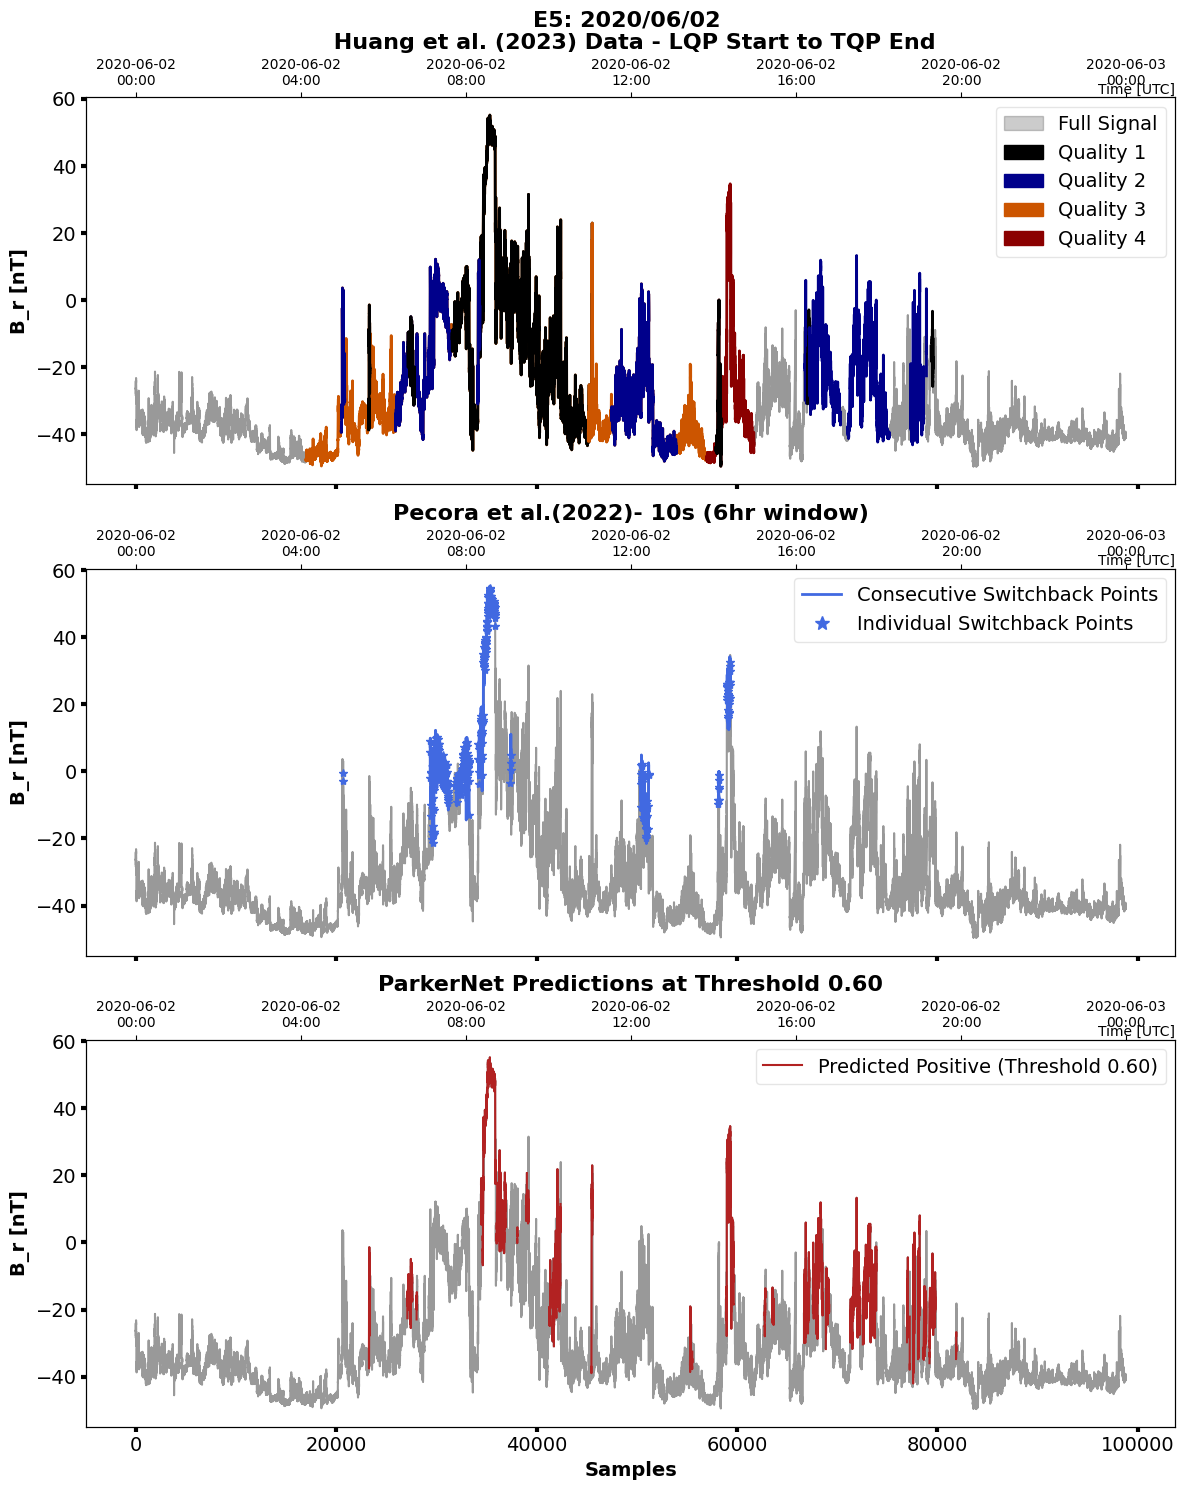

In [30]:


roi_data = pd.read_csv('SingalROI_E5_Huang_allRegions.txt', sep='\t')

#
signal_data = df_ensemble_E5['B_r']
datetime_axis = df_ensemble_E5['Datetime']
predictions = df_ensemble_E5['Weighted_Voting_AUC_PRC']

# Define the threshold (set to 0.6)
threshold = 0.6

# Define a color map for quality levels
quality_colors = {
    1: 'black',
    2: '#00008B',  # Dark Blue for Quality 1
    3: '#CC5500',  # Burnt Orange for Quality 2
    4: '#8B0000',  # Red Brown for Quality 3
    5: '#8B4513'   # Red Brown for Quality 4
}

# Load the Pecora data 10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E5_Pecora_10s_6hr.txt', sep='\t')

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds
# Create binary mask for predictions based on the threshold
binary_predictions = (predictions > threshold).astype(int)


# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Perform DBSCAN clustering on the start indices
indices = pecora_data['start_index'].values.reshape(-1, 1)  # Reshape for DBSCAN
db = DBSCAN(eps=15, min_samples=2)  # Adjust parameters as needed
labels = db.fit_predict(indices)

# Initialize clusters list
clusters = []

# Group indices by cluster labels
for label in np.unique(labels):
    if label != -1:  # Skip noise
        cluster_indices = indices[labels == label].flatten()
        start_index = int(cluster_indices[0])
        end_index = int(cluster_indices[-1])
        clusters.append((start_index, end_index))

# Create a figure with three subplots (top, middle, bottom)
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]})
# --- Top Subplot: Full Ground Truth Switchbacks (LQP Start to TQP End) for Huang ---
axs[0].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Track legend patches in defined order
legend_patches = [mpatches.Patch(color='black', alpha=0.2, label='Full Signal')]
added_qualities = set()  # Track added quality levels to avoid duplicates

# Plot each switchback (from LQP Start to TQP End) with color based on quality
for _, row in roi_data.iterrows():
    quality_flag = row['QualityFlag']
    color = quality_colors.get(quality_flag, 'gray')  # Default to gray if the quality level is unknown

    # Define start and end points of the full ground truth switchback
    switchback_start = row['LQP_Start_Index']
    switchback_end = row['TQP_End_Index']

    # Plot the full ground truth switchback as a solid line
    axs[0].plot(range(switchback_start, switchback_end), signal_data[switchback_start:switchback_end], color=color, linewidth=2)

    # Add switchback region to legend if not already added
    if quality_flag not in added_qualities:
        legend_patches.append(mpatches.Patch(color=color, label=f'Quality {quality_flag}'))
        added_qualities.add(quality_flag)

# Sort the legend patches to display qualities in ascending order
legend_patches = [legend_patches[0]] + sorted(legend_patches[1:], key=lambda x: int(x.get_label().split()[-1]))

# Add legend for the top plot
axs[0].legend(handles=legend_patches, loc='upper right', fontsize=14,framealpha=0.5)
axs[0].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[0].set_title('E5: 2020/06/02 \n Huang et al. (2023) Data - LQP Start to TQP End', fontsize=16, fontweight='bold')

# --- Middle Subplot: Pecora Data (Sparse Points and DBSCAN Segments) ---
axs[1].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Plot sparse points as asterisks
sparse_points_color = '#4169E1'  # Royal Blue
for _, row in pecora_data.iterrows():
    start_idx = int(row['start_index'])
    axs[1].plot(start_idx, signal_data[start_idx], marker='*', color=sparse_points_color)

# Plot clustered segments
for start_idx, end_idx in clusters:
    axs[1].plot(range(start_idx, end_idx), signal_data[start_idx:end_idx], color=sparse_points_color, linewidth=2)

# Add legend for Pecora data
pecora_line = Line2D([0], [0], color=sparse_points_color, lw=2, label='Consecutive Switchback Points')
sparse_asterisk = Line2D([0], [0], color=sparse_points_color, marker='*', linestyle='None', markersize=10, label='Individual Switchback Points')
axs[1].legend(handles=[pecora_line, sparse_asterisk], loc='upper right', fontsize=14, framealpha=0.5)

axs[1].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[1].set_title('Pecora et al.(2022)- 10s (6hr window)', fontsize=16, fontweight='bold')

# --- Bottom Subplot: Model Predictions ---
model_prediction_line = signal_data.copy()
model_prediction_line[binary_predictions == 0] = np.nan  # Mask out negative predictions
model_prediction_color = '#B22222'
axs[2].plot(signal_data, color='black', alpha=0.4)
axs[2].plot(model_prediction_line, color=model_prediction_color, linewidth=1.5, label=f'Predicted Positive (Threshold {threshold:.2f})')

axs[2].set_xlabel('Samples', fontsize=14, fontweight='bold')
axs[2].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[2].set_title(f'ParkerNet Predictions at Threshold {threshold:.2f}', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', fontsize=14, framealpha=0.5)

# --- Secondary datetime axis on top, ticks every 4 h ---
start_time    = datetime_axis.min().floor('h')
end_time      = datetime_axis.max().ceil('h')
four_hour_times = pd.date_range(start=start_time, end=end_time, freq='4h')
sample_ticks  = datetime_axis.searchsorted(four_hour_times)
tick_labels   = four_hour_times.strftime('%Y-%m-%d\n%H:%M')
# Apply tick parameters to all axes after plotting
for ax in axs:
    ax.tick_params(axis='x', labelsize=14, width=3)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=14, width=3)  # y-axis ticks
for ax in axs:
    twin = ax.twiny()
    twin.set_xlim(ax.get_xlim())
    twin.set_xticks(sample_ticks)
    twin.set_xticklabels(tick_labels, fontsize=10)
    twin.set_xlabel('Time [UTC]')
    twin.xaxis.label.set_horizontalalignment('right')
    twin.xaxis.set_label_coords(1, 1.01, transform=ax.transAxes)
# Adjust layout and show the plot for Pecora and Model Predictions
plt.tight_layout()

plt.savefig('APJS_E5.svg', dpi=600, bbox_inches='tight')
plt.savefig('APJS_E5.pdf', dpi=600, bbox_inches='tight')
plt.show()

#plt.savefig('E5_preds_DBSCAN.svg', dpi=600, bbox_inches='tight')
plt.show()

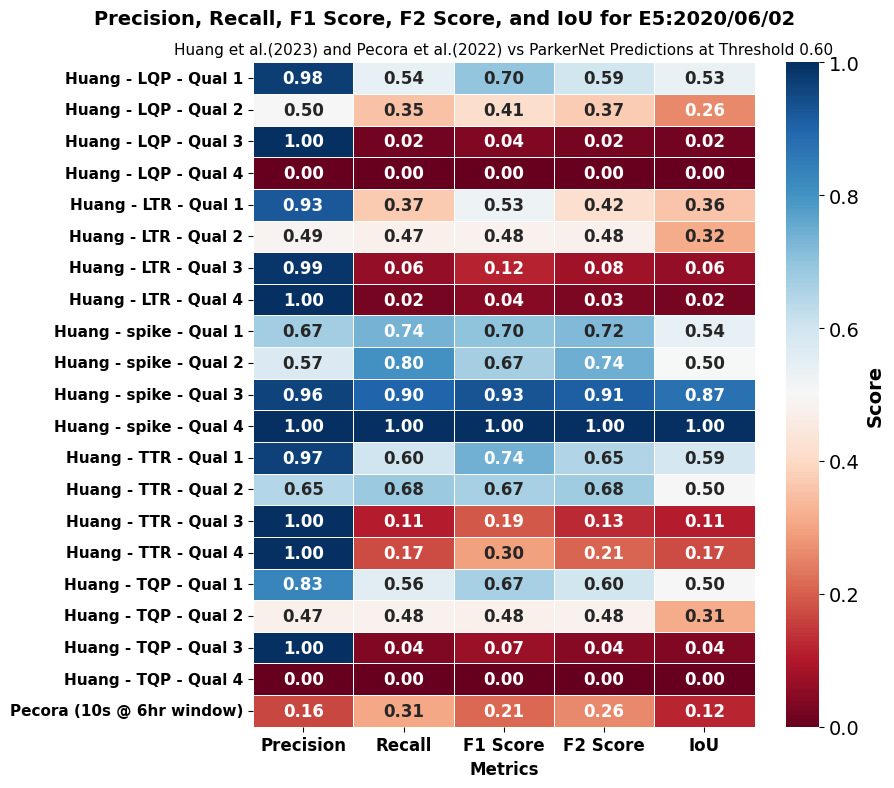

In [31]:



huang_data_path = 'SingalROI_E5_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E5['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E5['Class_Huang_E5_Range']

# Define threshold, using 0.61 instead of 0.6 because CM fails as decision boundary is very close in certain regions of Huang vs model
threshold = 0.61

# Define regions for Huang ground truths
regions = {
    "LQP": ("LQP_Start_Index", "LQP_End_Index"),
    "LTR": ("LQP_End_Index", "spike_Start_Index"),
    "spike": ("spike_Start_Index", "spike_End_Index"),
    "TTR": ("spike_End_Index", "TQP_Start_Index"),
    "TQP": ("TQP_Start_Index", "TQP_End_Index")
}

# Initialize lists to store Precision, Recall, F1, F2, and IoU values for the heatmap
heatmap_data = []
row_labels = []

# Loop through regions and quality flags for Huang data
for region, (start_col, end_col) in regions.items():
    for quality in sorted(roi_data['QualityFlag'].unique()):
        row_labels.append(f"Huang - {region} - Qual {quality}")
        row_data = []

        # Filter quality rows for the current region and quality
        quality_rows = roi_data[roi_data['QualityFlag'] == quality]
        ground_truth_segment = []



        # Construct ground truth and predictions for the current region and quality
        for _, row in quality_rows.iterrows():
            start, end = row[start_col], row[end_col]
            gt_segment = ground_truth[start:end].values  # Get the ground truth for the segment
            pred_segment = (predictions[start:end] >= threshold).astype(int).values  # Get the predicted values
            ground_truth_segment.extend(gt_segment)
            ground_truth_segment.extend(pred_segment)

        # Calculate confusion matrix
        cm = confusion_matrix(ground_truth_segment[:len(ground_truth_segment)//2], ground_truth_segment[len(ground_truth_segment)//2:])

        # Get TP, FP, FN
        TN, FP, FN, TP = cm.ravel()

        # Calculate Precision, Recall, F1, and F2 for the current region and quality
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        F1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        F2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) != 0 else 0

        # Calculate IoU for the current region and quality
        iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0

        # Append Precision, Recall, F1, F2, IoU results for the current region and quality
        row_data.extend([precision, recall, F1_score, F2_score, iou])

        # Append the data for the current region and quality
        heatmap_data.append(row_data)



#Load Pecora d10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E5_Pecora_10s_6hr.txt', sep = '\t')
# Assuming df_ensemble_E5 contains model predictions
predictions_pecora = df_ensemble_E5['Weighted_Voting_AUC_PRC']

# Create binary predictions based on threshold for Pecora data
binary_predictions_pecora = (predictions_pecora >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices for Pecora (10 seconds)
ground_truth_pecora = np.zeros_like(binary_predictions_pecora)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Calculate Precision, Recall, F1, F2, and IoU for Pecora data (as one whole segment)
cm_pecora = confusion_matrix(ground_truth_pecora, binary_predictions_pecora)
TN_pecora, FP_pecora, FN_pecora, TP_pecora = cm_pecora.ravel()  # Get confusion matrix values

# Calculate Precision, Recall, F1, and F2 for Pecora (single value)
precision_pecora = TP_pecora / (TP_pecora + FP_pecora) if (TP_pecora + FP_pecora) != 0 else 0
recall_pecora = TP_pecora / (TP_pecora + FN_pecora) if (TP_pecora + FN_pecora) != 0 else 0
F1_score_pecora = (2 * precision_pecora * recall_pecora) / (precision_pecora + recall_pecora) if (precision_pecora + recall_pecora) != 0 else 0
F2_score_pecora = (5 * precision_pecora * recall_pecora) / (4 * precision_pecora + recall_pecora) if (4 * precision_pecora + recall_pecora) != 0 else 0

# Calculate IoU for Pecora
iou_pecora = TP_pecora / (TP_pecora + FP_pecora + FN_pecora) if (TP_pecora + FP_pecora + FN_pecora) != 0 else 0

# Append Pecora Precision, Recall, F1, F2, IoU to heatmap data
row_labels.append("Pecora (10s @ 6hr window)")
heatmap_data.append([precision_pecora, recall_pecora, F1_score_pecora, F2_score_pecora, iou_pecora])

# Convert heatmap data to DataFrame
heatmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=["Precision", "Recall", "F1 Score", "F2 Score", "IoU"])

# Plot combined heatmap for Precision, Recall, F1, F2, and IoU (including Huang and Pecora)
fig, ax = plt.subplots(figsize=(9, 8))  # Adjust figure size for better readability

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdBu", cbar_kws={'label': 'Score'},
            annot_kws={"weight": "bold", "size": 12},  # Make annotation bold
            linewidths=0.5,  # Optional: thin line between cells
            cbar=True, vmin=0, vmax=1, ax=ax)  # Set color scale to go from 0 to 1

# Title and labels in bold with line breaks for title
plt.suptitle("Precision, Recall, F1 Score, F2 Score, and IoU for E5:2020/06/02", fontsize=14, fontweight='bold', y=0.98)
ax.set_title("Huang et al.(2023) and Pecora et al.(2022) vs ParkerNet Predictions at Threshold 0.60", fontsize=11, fontweight='normal', loc='center')

# Set xlabel with bold font
ax.set_xlabel("Metrics", fontsize=12, fontweight='bold')

# Make the y-axis labels bold and adjust font size
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontweight='bold')

# Make the legend label bold
cbar = ax.collections[0].colorbar
cbar.set_label('Score', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=12, fontweight = 'bold')
# Adjust layout to ensure everything fits without excessive width

plt.tight_layout()
#plt.savefig('E5_heatmap_1.svg', dpi=600, bbox_inches='tight')
plt.show()


 (True Negatives):  43958
 (False Positives):  1123
(False Negatives):  45433
 (True Positives):  8316
Precision: 0.8810
Recall: 0.1547
F1 Score: 0.2632
Total Switchbacks (Ground Truth 1):  53749
Intersection over Union (IoU): 0.1516


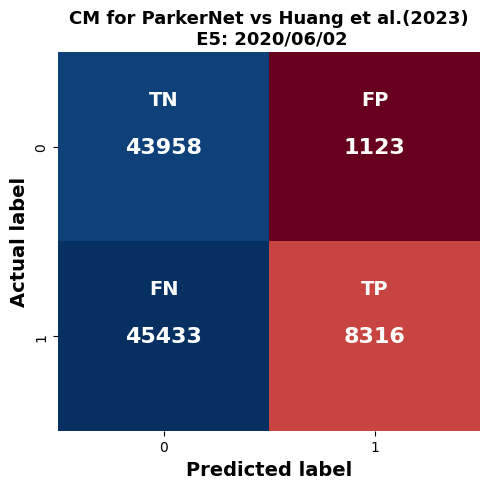

IoU at threshold 0.6: 0.1516


In [32]:


huang_data_path = 'SingalROI_E5_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E5['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E5['Class_Huang_E5_Range']

# Define threshold
threshold = 0.6

# Confusion Matrix Function
def plot_cm_and_metrics(labels, predictions, threshold=0.6):
    # Compute the confusion matrix
    cm = confusion_matrix(labels, predictions > threshold)

    # Plot the confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title('CM for ParkerNet vs Huang et al.(2023)\n E5: 2020/06/02', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')
    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()

    # Position the labels slightly above the center of each section
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # Show the plot
    #plt.savefig('E5_Huang_CM.svg', dpi=600, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth, predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
print(f'IoU at threshold {threshold}: {iou:.4f}')

   Threshold  Precision    Recall  F1 Score       AUC
0       0.50   0.875196  0.218404  0.349573  0.769061
1       0.55   0.878703  0.185994  0.307005  0.769061
2       0.60   0.881026  0.154719  0.263215  0.769061
3       0.65   0.895551  0.121714  0.214302  0.769061
4       0.70   0.906689  0.092560  0.167972  0.769061
5       0.75   0.997779  0.050159  0.095516  0.769061
6       0.80   1.000000  0.006995  0.013894  0.769061
7       0.85   0.000000  0.000000  0.000000  0.769061
8       0.90   0.000000  0.000000  0.000000  0.769061
9       0.95   0.000000  0.000000  0.000000  0.769061


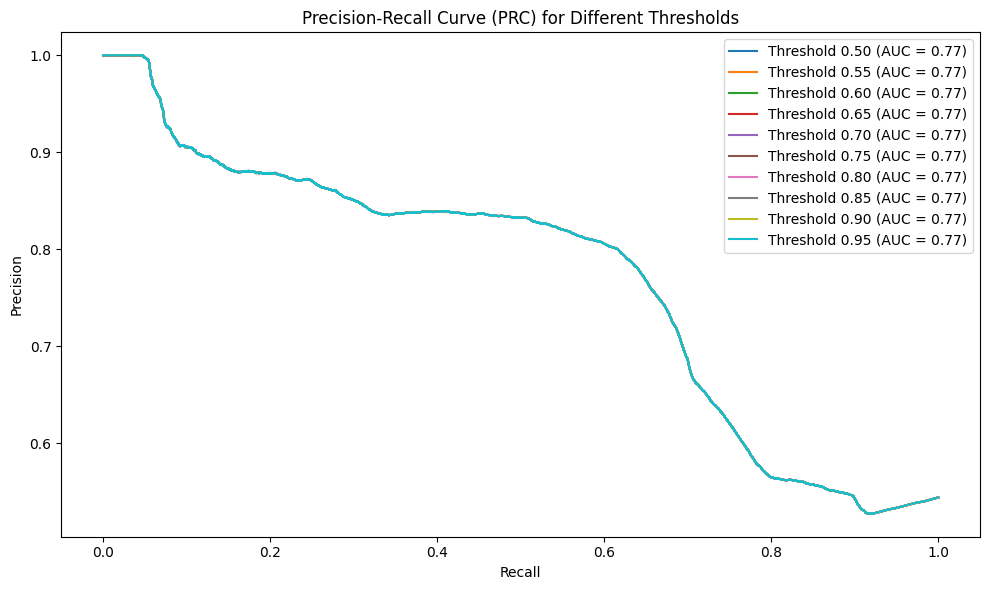

In [ ]:



huang_data_path = 'SingalROI_E5_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E5['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E5['Class_Huang_E5_Range']

# Define thresholds for analysis
thresholds = np.arange(0.5, 1.0, 0.05)

# Initialize lists to store metrics for each threshold
precision_list = []
recall_list = []
f1_list = []
auc_list = []

# Create an empty DataFrame to store the metrics for each threshold
metrics_df = pd.DataFrame(columns=['Threshold', 'Precision', 'Recall', 'F1 Score', 'AUC'])

# Function to calculate confusion matrix and metrics
def calculate_metrics(labels, predictions, threshold):
    cm = confusion_matrix(labels, predictions > threshold)
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # Calculate Precision-Recall curve and AUC
    precision_curve, recall_curve, _ = precision_recall_curve(labels, predictions)
    auc_score = auc(recall_curve, precision_curve)

    return precision, recall, f1_score, auc_score

# Loop through each threshold and calculate metrics
for threshold in thresholds:
    precision, recall, f1_score, auc_score = calculate_metrics(ground_truth, predictions, threshold)

    # Add the results to the metrics dataframe using pd.concat
    new_row = pd.DataFrame({
        'Threshold': [threshold],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1_score],
        'AUC': [auc_score]
    })

    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Print the metrics DataFrame
print(metrics_df)

# Plot the Precision-Recall curve and include AUC in the legend
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    # Get precision and recall for the current threshold
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Plot each threshold with its AUC score in the legend
    plt.plot(recall_curve, precision_curve, label=f'Threshold {threshold:.2f} (AUC = {auc_score:.2f})')

plt.title('Precision-Recall Curve (PRC) for Different Thresholds')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

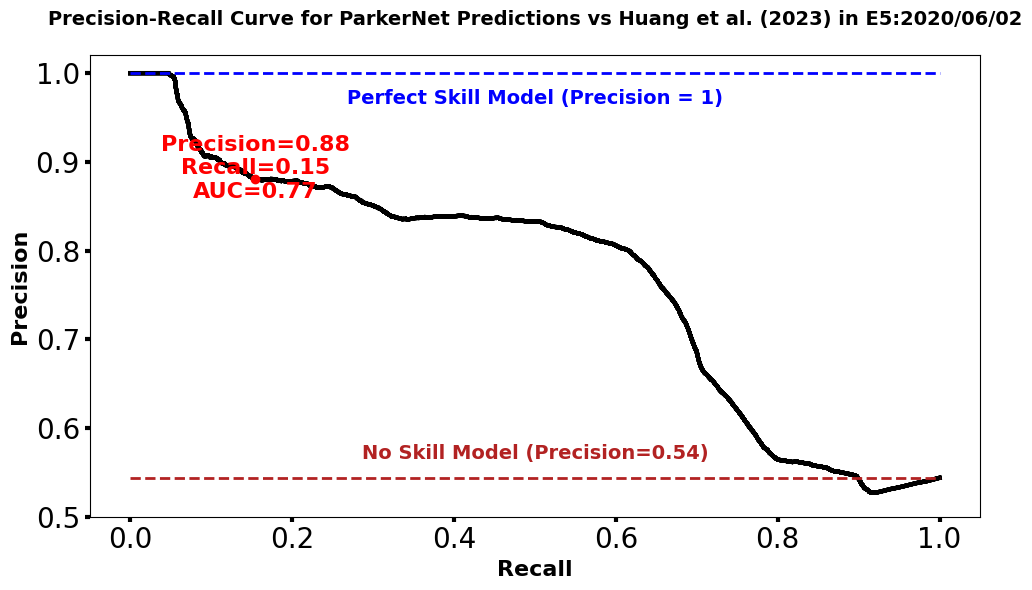

In [ ]:

# Load the data
huang_data_path = 'SingalROI_E5_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E5['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E5['Class_Huang_E5_Range']

# Define thresholds (from 0.5 to 0.95)
thresholds = np.round(np.arange(0.5, 0.95, 0.05), 2)

# Initialize lists to store the Precision-Recall curve and AUC for each threshold
precision_dict = {}
recall_dict = {}
auc_dict = {}

# Calculate Precision-Recall curve and AUC for each threshold
for threshold in thresholds:
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Store precision, recall, and auc values for each threshold
    precision_dict[threshold] = precision_curve
    recall_dict[threshold] = recall_curve
    auc_dict[round(threshold, 2)] = auc_score  # Round threshold to two decimal places

# Plot Precision-Recall curves for all thresholds
plt.figure(figsize=(10, 6))

for threshold in thresholds:
    plt.plot(recall_dict[threshold], precision_dict[threshold], color='black', linewidth=3)

# Provided precision and recall at threshold 0.6
threshold_0_6_precision = 0.881026
threshold_0_6_recall =  0.154719

# Calculate AUC at threshold 0.6
auc_at_06 = auc_dict[0.6]  # AUC for threshold 0.6

# Plot the red dot for threshold 0.6
plt.plot(threshold_0_6_recall, threshold_0_6_precision, 'k-', label=f'Model Precision-Recall curve at 0.60 threshold')

# Calculate No Skill Model baseline
num_positives = np.sum(ground_truth == 1)
num_total = len(ground_truth)
no_skill_precision = num_positives / num_total
no_skill_recall = num_positives / num_total  # Recall is the same as the proportion of positives

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.005),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.95),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')

# Adding labels and title
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Huang et al. (2023) in E5:2020/06/02\n', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(threshold_0_6_recall, threshold_0_6_precision, color='red', zorder=5)

# Add the red dot annotation for threshold 0.6
plt.annotate(f'Precision={threshold_0_6_precision:.2f}\nRecall={threshold_0_6_recall:.2f}\nAUC={auc_at_06:.2f}',
             (threshold_0_6_recall, threshold_0_6_precision),
             textcoords="offset points",
             xytext=(0,10),
             ha='center', va= 'center_baseline', fontsize=16, fontweight='bold', color='red')

# Set y-axis limits to ensure the perfect skill line is visible
plt.ylim(0.5, 1.02)
# Customize y-axis ticks to show 0.1 and 0.9
plt.yticks(np.arange(0.5, 1.02, 0.1))  # Set y-ticks from 0 to 1 with step of 0.1

# Apply the tick parameters to all axes after plotting
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks


#plt.savefig('E5_Huang_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


 (True Negatives):  86079
 (False Positives):  7922
(False Negatives):  3312
 (True Positives):  1517
Precision: 0.1607
Recall: 0.3141
F1 Score: 0.2126
Total Switchbacks (Ground Truth 1):  4829
Intersection over Union (IoU): 0.1190
IoU at threshold 0.6: 0.1190


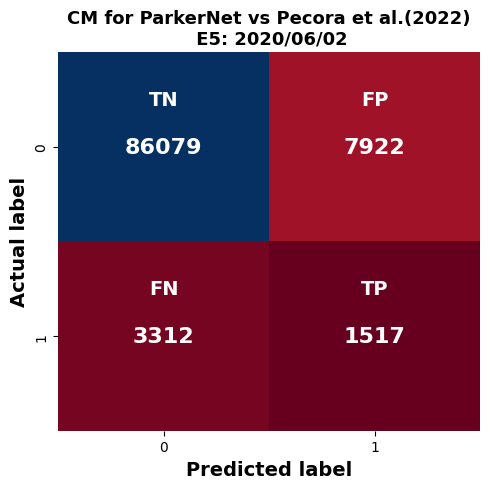

In [33]:



pecora_data = pd.read_csv('SignalROI_E5_Pecora_10s_6hr.txt', sep='\t')

predictions = df_ensemble_E5['Weighted_Voting_AUC_PRC']

# Define threshold
threshold = 0.6

# Create a binary prediction array based on the threshold
binary_predictions = (predictions >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices
ground_truth_pecora = np.zeros_like(binary_predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def plot_cm_and_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)
    if np.all(cm == 0):  # Check if cm is all zeros (invalid case)
        print("Warning: Confusion matrix is all zeros!")
        return None  # Return None if confusion matrix is empty

    # Plot confusion matrix using heatmap
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title(f'CM for ParkerNet vs Pecora et al.(2022)\n E5: 2020/06/02', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')

    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth_pecora, binary_predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
if iou is not None:
    print(f'IoU at threshold {threshold}: {iou:.4f}')

# Show the plot
plt.tight_layout()
#plt.savefig('E5_Pecora_CM_1.svg', dpi=600, bbox_inches='tight')  # Save after the plot is created
plt.show()

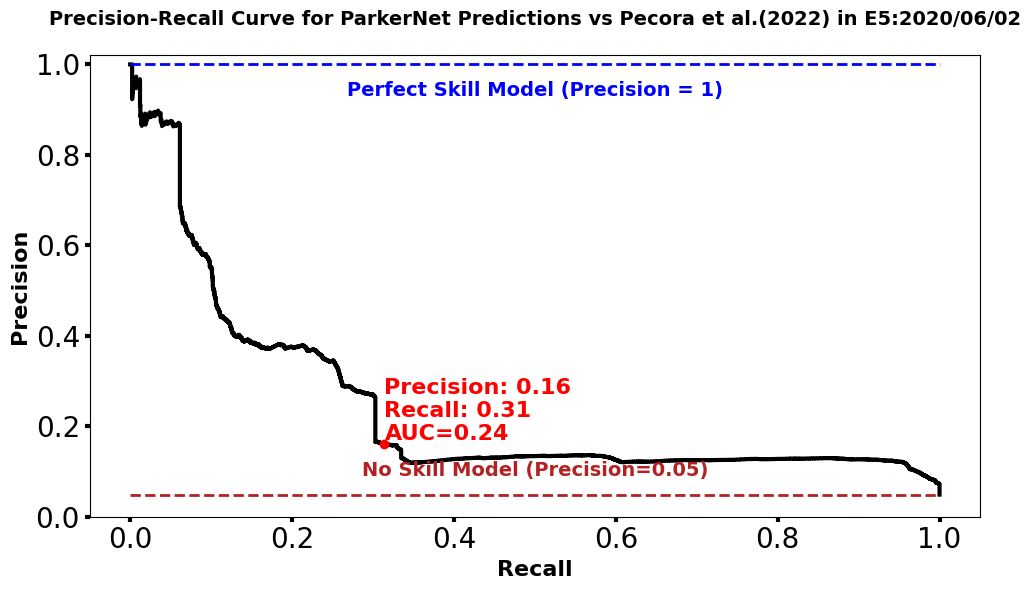

In [ ]:



pecora_data = pd.read_csv('SignalROI_E5_Pecora_10s_6hr.txt', sep='\t')  # Pecora data
predictions = df_ensemble_E5['Weighted_Voting_AUC_PRC']

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Adjust Pecora data based on the start and end indices (10-second window)
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)

# Construct ground truth based on adjusted indices for Pecora data
ground_truth_pecora = np.zeros_like(predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Define thresholds to evaluate
thresholds = np.linspace(0.1, 0.9, 9)

# Initialize list to store metrics
metrics_list = []

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def calculate_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return precision, recall, f1_score

# Evaluate metrics at various thresholds
for threshold in thresholds:
    precision, recall, f1_score = calculate_metrics(ground_truth_pecora, predictions, threshold)
    metrics_list.append({'Threshold': threshold, 'Precision': precision, 'Recall': recall, 'F1 Score': f1_score})

# Convert metrics list to dataframe
metrics_df = pd.DataFrame(metrics_list)

# Plot the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ground_truth_pecora, predictions)

# **Perfect Skill** line will be precision=1, recall=1 across all recall values
perfect_skill = np.ones_like(recall)

# **No Skill** line is precision = the proportion of positive samples in the ground truth
no_skill_precision = np.sum(ground_truth_pecora == 1) / len(ground_truth_pecora)  # Proportion of positive samples
no_skill = np.full_like(recall, no_skill_precision)

# AUC at threshold 0.6
threshold_06_index = np.where(thresholds >= 0.6)[0][0]
precision_at_06 = metrics_df.loc[threshold_06_index, 'Precision']
recall_at_06 = metrics_df.loc[threshold_06_index, 'Recall']
auc_at_06 = auc(recall, precision)  # Calculate AUC value

plt.figure(figsize=(10, 6))

# Plot Precision-Recall Curve
plt.plot(recall, precision, color='black', lw=3, label=f'Model Precision-Recall Curve at 0.6 threshold')


# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.01),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.9),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')


# Plot Precision and Recall values at threshold 0.6 directly on the graph
plt.text(recall_at_06, precision_at_06, f'Precision: {precision_at_06:.2f}\nRecall: {recall_at_06:.2f}\nAUC={auc_at_06:.2f}', color='red', fontsize=16, fontweight = 'bold', ha='left', va='bottom')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(recall_at_06, precision_at_06, color='red', zorder=5)

# Labels and Title
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Pecora et al.(2022) in E5:2020/06/02\n', fontsize=14, fontweight='bold')

plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.02, 0.2))

# Increase the size of the x and y axis tick marks
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks

#plt.savefig('E5_Pecora_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


ENCOUNTER 6

In [34]:
# Read in the dataset for predicting
df_E6 = pd.read_csv('PSP_E6_ForPrediction.txt', sep="\t", parse_dates=['Datetime'])

# Separate the 'Class_Huang_Ex' column into df_gt
df_gt_E6 = df_E6[['Class_Huang_E6_Range']].copy()

pd.set_option('future.no_silent_downcasting', True)
df_gt_E6['Class_Huang_E6_Range'] = df_gt_E6['Class_Huang_E6_Range'].replace({True: 1, False: 0}).infer_objects(copy=False).astype(int)
# Create df_test by dropping the 'Class_Huang_Ex' column and other columns not needed
df_test_E6= df_E6.drop(columns=['Class_Huang_E6_Range'])

df_test_E6.pop("X_HCI")
df_test_E6.pop("Y_HCI")
df_test_E6.pop("Z_HCI")
display(df_test_E6)

,Datetime,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2020-09-18 00:00:00.000000000,-20.550350,29.086024,18.378670,9.268462,238.944,-8.68878,15.65330,239.613764,17.903092,98.5854
1,2020-09-18 00:00:00.873799999,-20.573168,29.108490,18.346702,9.351335,245.351,-12.02090,14.65370,246.081991,18.953442,86.7583
2,2020-09-18 00:00:01.747599999,-20.546205,29.106085,18.353771,9.389182,245.705,-21.68060,13.69210,247.039408,25.642192,84.1120
3,2020-09-18 00:00:02.621399999,-20.547378,29.184900,18.426395,9.488499,242.377,-24.12100,22.36100,244.598543,32.891290,100.0340
4,2020-09-18 00:00:03.495199999,-20.560779,29.194042,18.470095,9.402237,240.810,-19.91930,12.34370,241.947518,23.433852,98.1609
...,...,...,...,...,...,...,...,...,...,...,...
98875,2020-09-18 23:59:56.974996393,-8.193979,27.132018,23.457845,10.896542,292.089,15.85880,10.02900,292.691077,18.763858,98.8086
98876,2020-09-18 23:59:57.848796393,-6.320918,27.256590,23.700745,11.884545,301.806,19.11380,8.57005,302.532056,20.947150,86.8920
98877,2020-09-18 23:59:58.722596393,-5.030788,27.131246,24.366213,10.820507,298.524,12.54360,6.90969,298.867302,14.320814,91.4599
98878,2020-09-18 23:59:59.596396393,-4.644556,27.057048,24.210868,11.151045,298.524,12.54360,6.90969,298.867302,14.320814,91.4599


In [35]:
df_gt_allpreds_E6 = pd.read_csv('ParkerNet_allModel_averaged_predictions_E6_20200918.csv')
display(df_gt_allpreds_E6)

,Class_Huang_E6_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,Preds_splitM_seed1843,Preds_splitM_seed2221,Preds_splitM_seed3060,Preds_splitM_seed3247,Preds_splitM_seed3364,Preds_splitM_seed3871,Preds_splitM_seed4032,Preds_splitM_seed983,SimpleSoftVoting_Predictions,Weighted_Voting_AUC_PRC
0,0,0.645610,0.112656,0.414840,0.202445,0.176920,0.128426,0.235047,0.189638,0.185047,...,0.366588,0.146322,0.139766,0.194231,0.151197,0.269255,0.188555,0.212083,0.202468,0.200188
1,0,0.642459,0.112732,0.415061,0.201921,0.176641,0.128363,0.235319,0.188946,0.185479,...,0.366058,0.146294,0.139530,0.194071,0.150896,0.268808,0.187930,0.211577,0.202215,0.199946
2,0,0.636577,0.112746,0.413814,0.202410,0.176797,0.128412,0.235362,0.189175,0.186441,...,0.365703,0.146205,0.139110,0.193861,0.150221,0.268737,0.187442,0.211983,0.201925,0.199672
3,0,0.636488,0.112688,0.414263,0.202487,0.176458,0.128479,0.235040,0.188955,0.187280,...,0.367510,0.146099,0.139211,0.193711,0.149731,0.268637,0.187243,0.212504,0.201984,0.199727
4,0,0.635847,0.112547,0.415488,0.202580,0.176932,0.128225,0.235161,0.189155,0.187323,...,0.366602,0.146131,0.138765,0.193551,0.149041,0.269155,0.186447,0.211713,0.201950,0.199697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.667033,0.118505,0.513097,0.254968,0.402710,0.171260,0.427529,0.207427,0.549883,...,0.559772,0.161424,0.157072,0.256398,0.271568,0.354851,0.156596,0.519986,0.303380,0.302551
98826,0,0.666931,0.118516,0.512436,0.254337,0.400777,0.170734,0.425907,0.207401,0.549906,...,0.557982,0.161444,0.157280,0.255993,0.268846,0.353993,0.156423,0.517863,0.302420,0.301569
98827,0,0.665490,0.118359,0.511426,0.253347,0.396747,0.170427,0.425608,0.207628,0.549698,...,0.556811,0.161232,0.157505,0.255637,0.266959,0.354262,0.155750,0.515664,0.301592,0.300727
98828,0,0.664121,0.118278,0.511948,0.253152,0.395861,0.170310,0.424614,0.207239,0.548902,...,0.555635,0.161155,0.157194,0.255181,0.265138,0.354042,0.155247,0.513273,0.300969,0.300096


In [36]:
df_test_E6.reset_index(drop=True, inplace=True)
df_gt_allpreds_E6.reset_index(drop=True, inplace=True)
df_ensemble_E6 = pd.concat([df_gt_allpreds_E6, df_test_E6], axis=1, join='inner')
display(df_ensemble_E6)

,Class_Huang_E6_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,0,0.645610,0.112656,0.414840,0.202445,0.176920,0.128426,0.235047,0.189638,0.185047,...,-20.550350,29.086024,18.378670,9.268462,238.944,-8.68878,15.65330,239.613764,17.903092,98.5854
1,0,0.642459,0.112732,0.415061,0.201921,0.176641,0.128363,0.235319,0.188946,0.185479,...,-20.573168,29.108490,18.346702,9.351335,245.351,-12.02090,14.65370,246.081991,18.953442,86.7583
2,0,0.636577,0.112746,0.413814,0.202410,0.176797,0.128412,0.235362,0.189175,0.186441,...,-20.546205,29.106085,18.353771,9.389182,245.705,-21.68060,13.69210,247.039408,25.642192,84.1120
3,0,0.636488,0.112688,0.414263,0.202487,0.176458,0.128479,0.235040,0.188955,0.187280,...,-20.547378,29.184900,18.426395,9.488499,242.377,-24.12100,22.36100,244.598543,32.891290,100.0340
4,0,0.635847,0.112547,0.415488,0.202580,0.176932,0.128225,0.235161,0.189155,0.187323,...,-20.560779,29.194042,18.470095,9.402237,240.810,-19.91930,12.34370,241.947518,23.433852,98.1609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.667033,0.118505,0.513097,0.254968,0.402710,0.171260,0.427529,0.207427,0.549883,...,-0.548851,26.989199,26.112734,6.800055,309.562,17.34040,5.70185,310.099714,18.253782,83.7530
98826,0,0.666931,0.118516,0.512436,0.254337,0.400777,0.170734,0.425907,0.207401,0.549906,...,-1.179301,27.085828,26.124704,7.053449,307.491,19.76140,4.15825,308.153402,20.194157,84.4674
98827,0,0.665490,0.118359,0.511426,0.253347,0.396747,0.170427,0.425608,0.207628,0.549698,...,-1.586161,27.035086,25.962548,7.370623,306.059,20.80110,2.55548,306.775696,20.957486,86.6656
98828,0,0.664121,0.118278,0.511948,0.253152,0.395861,0.170310,0.424614,0.207239,0.548902,...,-1.138273,27.031415,25.659211,8.426545,303.097,13.52650,5.24234,303.443965,14.506837,88.9100


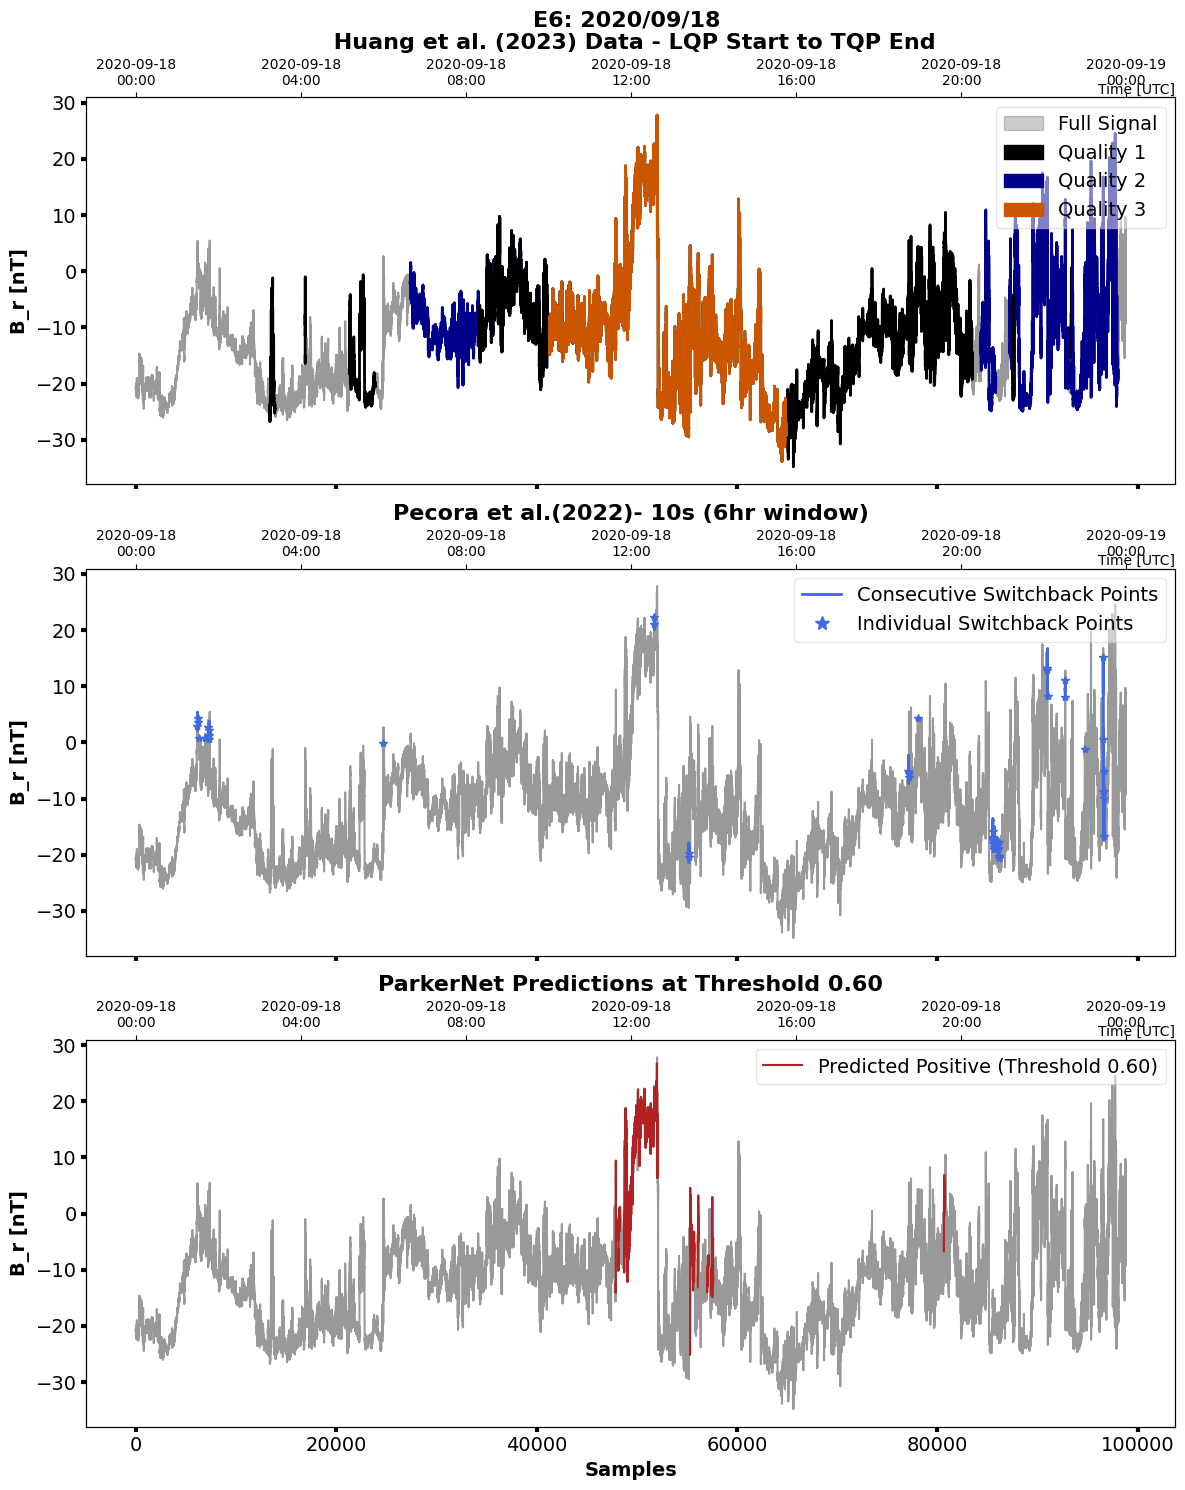

In [37]:



roi_data = pd.read_csv('SingalROI_E6_Huang_allRegions.txt', sep='\t')

signal_data = df_ensemble_E6['B_r']
datetime_axis = df_ensemble_E6['Datetime']
predictions = df_ensemble_E6['Weighted_Voting_AUC_PRC']

# Define the threshold (set to 0.6)
threshold = 0.6

# Define a color map for quality levels
quality_colors = {
    1: 'black',
    2: '#00008B',  # Dark Blue for Quality 1
    3: '#CC5500',  # Burnt Orange for Quality 2
    4: '#8B0000',  # Red Brown for Quality 3
    5: '#8B4513'   # Red Brown for Quality 4
}

# Load the Pecora data 10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E6_Pecora_10s_6hr.txt', sep='\t')

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds
# Create binary mask for predictions based on the threshold
binary_predictions = (predictions > threshold).astype(int)


# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Perform DBSCAN clustering on the start indices
indices = pecora_data['start_index'].values.reshape(-1, 1)  # Reshape for DBSCAN
db = DBSCAN(eps=15, min_samples=2)  # Adjust parameters as needed
labels = db.fit_predict(indices)

# Initialize clusters list
clusters = []

# Group indices by cluster labels
for label in np.unique(labels):
    if label != -1:  # Skip noise
        cluster_indices = indices[labels == label].flatten()
        start_index = int(cluster_indices[0])
        end_index = int(cluster_indices[-1])
        clusters.append((start_index, end_index))

# Create a figure with three subplots (top, middle, bottom)
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]})
# --- Top Subplot: Full Ground Truth Switchbacks (LQP Start to TQP End) for Huang ---
axs[0].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Track legend patches in defined order
legend_patches = [mpatches.Patch(color='black', alpha=0.2, label='Full Signal')]
added_qualities = set()  # Track added quality levels to avoid duplicates

# Plot each switchback (from LQP Start to TQP End) with color based on quality
for _, row in roi_data.iterrows():
    quality_flag = row['QualityFlag']
    color = quality_colors.get(quality_flag, 'gray')  # Default to gray if the quality level is unknown

    # Define start and end points of the full ground truth switchback
    switchback_start = row['LQP_Start_Index']
    switchback_end = row['TQP_End_Index']

    # Plot the full ground truth switchback as a solid line
    axs[0].plot(range(switchback_start, switchback_end), signal_data[switchback_start:switchback_end], color=color, linewidth=2)

    # Add switchback region to legend if not already added
    if quality_flag not in added_qualities:
        legend_patches.append(mpatches.Patch(color=color, label=f'Quality {quality_flag}'))
        added_qualities.add(quality_flag)

# Sort the legend patches to display qualities in ascending order
legend_patches = [legend_patches[0]] + sorted(legend_patches[1:], key=lambda x: int(x.get_label().split()[-1]))

# Add legend for the top plot
axs[0].legend(handles=legend_patches, loc='upper right', fontsize=14,framealpha=0.5)
axs[0].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[0].set_title('E6: 2020/09/18 \n Huang et al. (2023) Data - LQP Start to TQP End', fontsize=16, fontweight='bold')

# --- Middle Subplot: Pecora Data (Sparse Points and DBSCAN Segments) ---
axs[1].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Plot sparse points as asterisks
sparse_points_color = '#4169E1'  # Royal Blue
for _, row in pecora_data.iterrows():
    start_idx = int(row['start_index'])
    axs[1].plot(start_idx, signal_data[start_idx], marker='*', color=sparse_points_color)

# Plot clustered segments
for start_idx, end_idx in clusters:
    axs[1].plot(range(start_idx, end_idx), signal_data[start_idx:end_idx], color=sparse_points_color, linewidth=2)

# Add legend for Pecora data
pecora_line = Line2D([0], [0], color=sparse_points_color, lw=2, label='Consecutive Switchback Points')
sparse_asterisk = Line2D([0], [0], color=sparse_points_color, marker='*', linestyle='None', markersize=10, label='Individual Switchback Points')
axs[1].legend(handles=[pecora_line, sparse_asterisk], loc='upper right', fontsize=14, framealpha=0.5)

axs[1].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[1].set_title('Pecora et al.(2022)- 10s (6hr window)', fontsize=16, fontweight='bold')

# --- Bottom Subplot: Model Predictions ---
model_prediction_line = signal_data.copy()
model_prediction_line[binary_predictions == 0] = np.nan  # Mask out negative predictions
model_prediction_color = '#B22222'
axs[2].plot(signal_data, color='black', alpha=0.4)
axs[2].plot(model_prediction_line, color=model_prediction_color, linewidth=1.5, label=f'Predicted Positive (Threshold {threshold:.2f})')

axs[2].set_xlabel('Samples', fontsize=14, fontweight='bold')
axs[2].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[2].set_title(f'ParkerNet Predictions at Threshold {threshold:.2f}', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', fontsize=14, framealpha=0.5)

# --- Secondary datetime axis on top, ticks every 4 h ---
start_time    = datetime_axis.min().floor('h')
end_time      = datetime_axis.max().ceil('h')
four_hour_times = pd.date_range(start=start_time, end=end_time, freq='4h')
sample_ticks  = datetime_axis.searchsorted(four_hour_times)
tick_labels   = four_hour_times.strftime('%Y-%m-%d\n%H:%M')



# Apply tick parameters to all axes after plotting
for ax in axs:
    ax.tick_params(axis='x', labelsize=14, width=3)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=14, width=3)  # y-axis ticks
for ax in axs:
    twin = ax.twiny()
    twin.set_xlim(ax.get_xlim())
    twin.set_xticks(sample_ticks)
    twin.set_xticklabels(tick_labels, fontsize=10)
    twin.set_xlabel('Time [UTC]')
    twin.xaxis.label.set_horizontalalignment('right')
    twin.xaxis.set_label_coords(1, 1.01, transform=ax.transAxes)
# Adjust layout and show the plot for Pecora and Model Predictions
plt.tight_layout()

plt.savefig('APJS_E6.svg', dpi=600, bbox_inches='tight')
plt.savefig('APJS_E6.pdf', dpi=600, bbox_inches='tight')
plt.show()




#plt.savefig('E6_preds_DBSCAN.svg', dpi=600, bbox_inches='tight')
#plt.show()

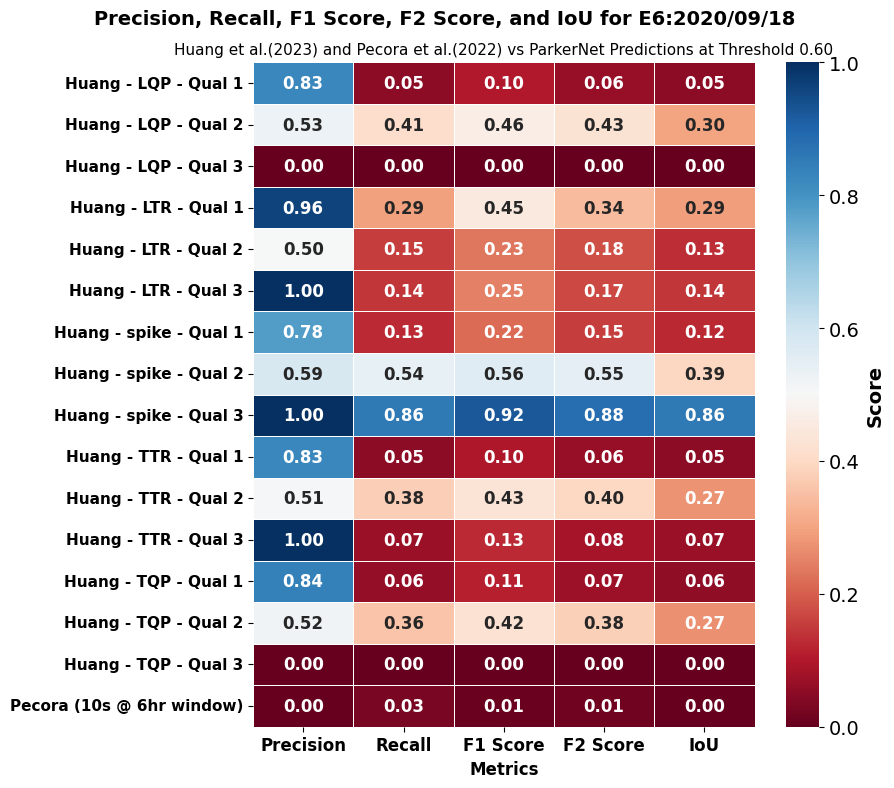

In [38]:



huang_data_path = 'SingalROI_E6_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E6['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E6['Class_Huang_E6_Range']

# Define threshold
threshold = 0.6

# Define regions for Huang ground truths
regions = {
    "LQP": ("LQP_Start_Index", "LQP_End_Index"),
    "LTR": ("LQP_End_Index", "spike_Start_Index"),
    "spike": ("spike_Start_Index", "spike_End_Index"),
    "TTR": ("spike_End_Index", "TQP_Start_Index"),
    "TQP": ("TQP_Start_Index", "TQP_End_Index")
}

# Initialize lists to store Precision, Recall, F1, F2, and IoU values for the heatmap
heatmap_data = []
row_labels = []

# Loop through regions and quality flags for Huang data
for region, (start_col, end_col) in regions.items():
    for quality in sorted(roi_data['QualityFlag'].unique()):
        row_labels.append(f"Huang - {region} - Qual {quality}")
        row_data = []

        # Filter quality rows for the current region and quality
        quality_rows = roi_data[roi_data['QualityFlag'] == quality]
        ground_truth_segment = []



        # Construct ground truth and predictions for the current region and quality
        for _, row in quality_rows.iterrows():
            start, end = row[start_col], row[end_col]
            gt_segment = ground_truth[start:end].values  # Get the ground truth for the segment
            pred_segment = (predictions[start:end] >= threshold).astype(int).values  # Get the predicted values
            ground_truth_segment.extend(gt_segment)
            ground_truth_segment.extend(pred_segment)

        # Calculate confusion matrix
        cm = confusion_matrix(ground_truth_segment[:len(ground_truth_segment)//2], ground_truth_segment[len(ground_truth_segment)//2:])

        # Get TP, FP, FN
        TN, FP, FN, TP = cm.ravel()

        # Calculate Precision, Recall, F1, and F2 for the current region and quality
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        F1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        F2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) != 0 else 0

        # Calculate IoU for the current region and quality
        iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0

        # Append Precision, Recall, F1, F2, IoU results for the current region and quality
        row_data.extend([precision, recall, F1_score, F2_score, iou])

        # Append the data for the current region and quality
        heatmap_data.append(row_data)



#Load Pecora d10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E6_Pecora_10s_6hr.txt', sep = '\t')
# Assuming df_ensemble_E6 contains model predictions
predictions_pecora = df_ensemble_E6['Weighted_Voting_AUC_PRC']

# Create binary predictions based on threshold for Pecora data
binary_predictions_pecora = (predictions_pecora >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices for Pecora (10 seconds)
ground_truth_pecora = np.zeros_like(binary_predictions_pecora)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Calculate Precision, Recall, F1, F2, and IoU for Pecora data (as one whole segment)
cm_pecora = confusion_matrix(ground_truth_pecora, binary_predictions_pecora)
TN_pecora, FP_pecora, FN_pecora, TP_pecora = cm_pecora.ravel()  # Get confusion matrix values

# Calculate Precision, Recall, F1, and F2 for Pecora (single value)
precision_pecora = TP_pecora / (TP_pecora + FP_pecora) if (TP_pecora + FP_pecora) != 0 else 0
recall_pecora = TP_pecora / (TP_pecora + FN_pecora) if (TP_pecora + FN_pecora) != 0 else 0
F1_score_pecora = (2 * precision_pecora * recall_pecora) / (precision_pecora + recall_pecora) if (precision_pecora + recall_pecora) != 0 else 0
F2_score_pecora = (5 * precision_pecora * recall_pecora) / (4 * precision_pecora + recall_pecora) if (4 * precision_pecora + recall_pecora) != 0 else 0

# Calculate IoU for Pecora
iou_pecora = TP_pecora / (TP_pecora + FP_pecora + FN_pecora) if (TP_pecora + FP_pecora + FN_pecora) != 0 else 0

# Append Pecora Precision, Recall, F1, F2, IoU to heatmap data
row_labels.append("Pecora (10s @ 6hr window)")
heatmap_data.append([precision_pecora, recall_pecora, F1_score_pecora, F2_score_pecora, iou_pecora])

# Convert heatmap data to DataFrame
heatmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=["Precision", "Recall", "F1 Score", "F2 Score", "IoU"])

# Plot combined heatmap for Precision, Recall, F1, F2, and IoU (including Huang and Pecora)
fig, ax = plt.subplots(figsize=(9, 8))  # Adjust figure size for better readability

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdBu", cbar_kws={'label': 'Score'},
            annot_kws={"weight": "bold", "size": 12},  # Make annotation bold
            linewidths=0.5,  # Optional: thin line between cells
            cbar=True, vmin=0, vmax=1, ax=ax)  # Set color scale to go from 0 to 1

# Title and labels in bold with line breaks for title
plt.suptitle("Precision, Recall, F1 Score, F2 Score, and IoU for E6:2020/09/18", fontsize=14, fontweight='bold', y=0.98)
ax.set_title("Huang et al.(2023) and Pecora et al.(2022) vs ParkerNet Predictions at Threshold 0.60", fontsize=11, fontweight='normal', loc='center')

# Set xlabel with bold font
ax.set_xlabel("Metrics", fontsize=12, fontweight='bold')

# Make the y-axis labels bold and adjust font size
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontweight='bold')

# Make the legend label bold
cbar = ax.collections[0].colorbar
cbar.set_label('Score', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=12, fontweight = 'bold')
# Adjust layout to ensure everything fits without excessive width

plt.tight_layout()
#plt.savefig('E6_heatmap_1.svg', dpi=600, bbox_inches='tight')
plt.show()


 (True Negatives):  27794
 (False Positives):  0
(False Negatives):  66860
 (True Positives):  4176
Precision: 1.0000
Recall: 0.0588
F1 Score: 0.1110
Total Switchbacks (Ground Truth 1):  71036
Intersection over Union (IoU): 0.0588


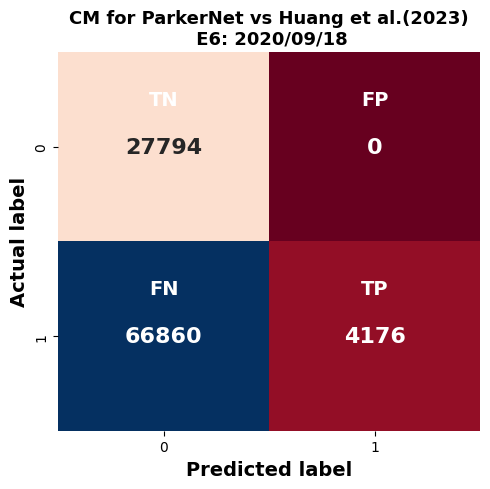

IoU at threshold 0.6: 0.0588


In [39]:


# Load the data
huang_data_path = 'SingalROI_E6_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')

predictions = df_ensemble_E6['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E6['Class_Huang_E6_Range']

# Define threshold
threshold = 0.6

# Confusion Matrix Function
def plot_cm_and_metrics(labels, predictions, threshold=0.6):
    # Compute the confusion matrix
    cm = confusion_matrix(labels, predictions > threshold)

    # Plot the confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title('CM for ParkerNet vs Huang et al.(2023)\n E6: 2020/09/18', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')
    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()

    # Position the labels slightly above the center of each section
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # Show the plot
    plt.savefig('E6_Huang_CM.svg', dpi=600, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth, predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
print(f'IoU at threshold {threshold}: {iou:.4f}')

<ipython-input-98-05af11608f6e>:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)


   Threshold  Precision    Recall  F1 Score       AUC
0       0.50        1.0  0.136607  0.240377  0.905084
1       0.55        1.0  0.091616  0.167853  0.905084
2       0.60        1.0  0.058787  0.111046  0.905084
3       0.65        1.0  0.027521  0.053568  0.905084
4       0.70        1.0  0.004885  0.009722  0.905084
5       0.75        1.0  0.002168  0.004326  0.905084
6       0.80        0.0  0.000000  0.000000  0.905084
7       0.85        0.0  0.000000  0.000000  0.905084
8       0.90        0.0  0.000000  0.000000  0.905084
9       0.95        0.0  0.000000  0.000000  0.905084


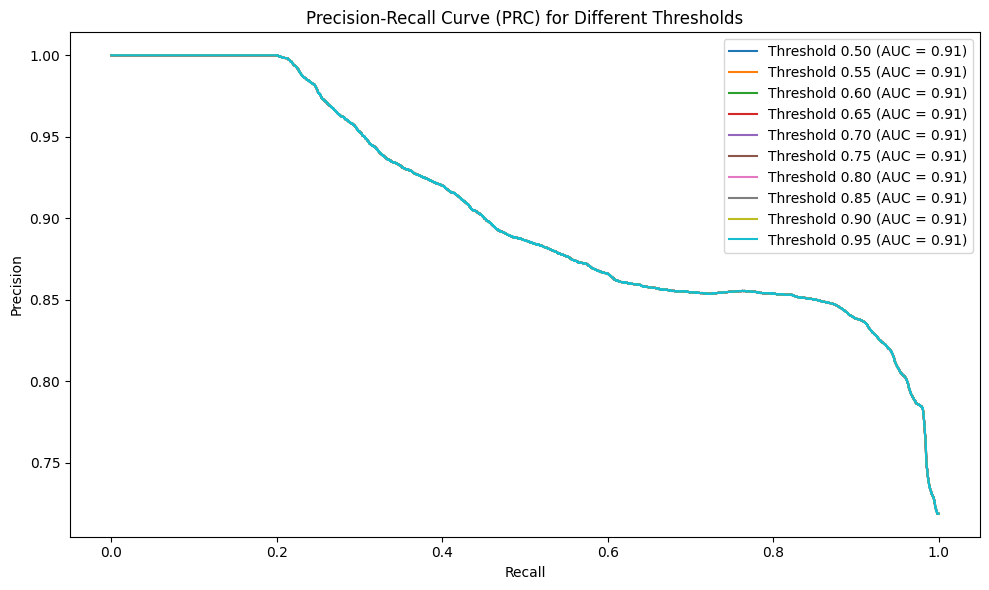

In [ ]:



huang_data_path = 'SingalROI_E6_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E6['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E6['Class_Huang_E6_Range']

# Define thresholds for analysis
thresholds = np.arange(0.5, 1.0, 0.05)

# Initialize lists to store metrics for each threshold
precision_list = []
recall_list = []
f1_list = []
auc_list = []

# Create an empty DataFrame to store the metrics for each threshold
metrics_df = pd.DataFrame(columns=['Threshold', 'Precision', 'Recall', 'F1 Score', 'AUC'])

# Function to calculate confusion matrix and metrics
def calculate_metrics(labels, predictions, threshold):
    cm = confusion_matrix(labels, predictions > threshold)
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # Calculate Precision-Recall curve and AUC
    precision_curve, recall_curve, _ = precision_recall_curve(labels, predictions)
    auc_score = auc(recall_curve, precision_curve)

    return precision, recall, f1_score, auc_score

# Loop through each threshold and calculate metrics
for threshold in thresholds:
    precision, recall, f1_score, auc_score = calculate_metrics(ground_truth, predictions, threshold)

    # Add the results to the metrics dataframe using pd.concat
    new_row = pd.DataFrame({
        'Threshold': [threshold],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1_score],
        'AUC': [auc_score]
    })

    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Print the metrics DataFrame
print(metrics_df)

# Plot the Precision-Recall curve and include AUC in the legend
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    # Get precision and recall for the current threshold
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Plot each threshold with its AUC score in the legend
    plt.plot(recall_curve, precision_curve, label=f'Threshold {threshold:.2f} (AUC = {auc_score:.2f})')

plt.title('Precision-Recall Curve (PRC) for Different Thresholds')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

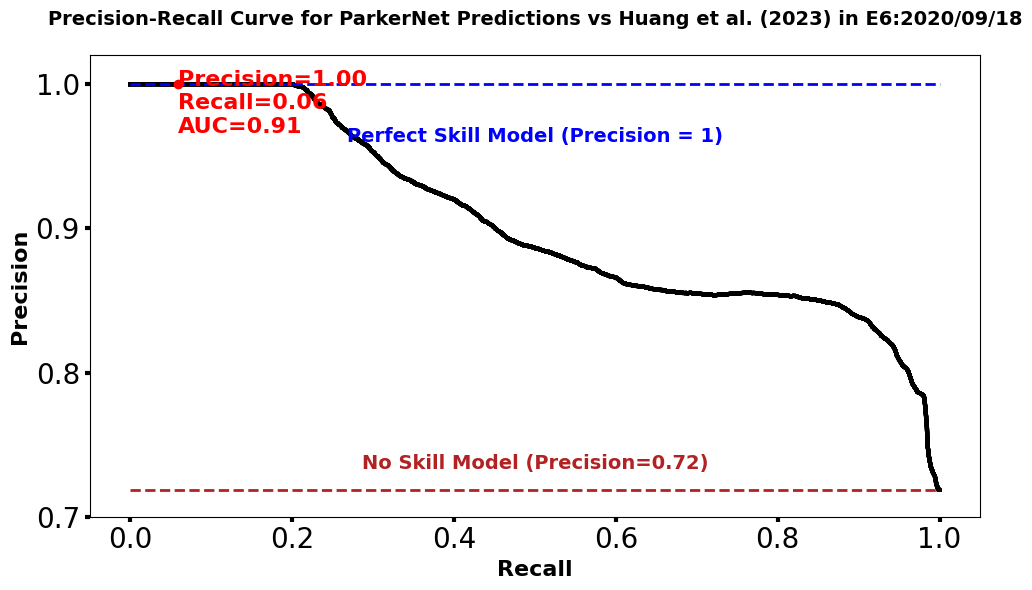

In [ ]:

# Load the data
huang_data_path = 'SingalROI_E6_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E6['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E6['Class_Huang_E6_Range']

# Define thresholds (from 0.5 to 0.95)
thresholds = np.round(np.arange(0.5, 0.95, 0.05), 2)

# Initialize lists to store the Precision-Recall curve and AUC for each threshold
precision_dict = {}
recall_dict = {}
auc_dict = {}

# Calculate Precision-Recall curve and AUC for each threshold
for threshold in thresholds:
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Store precision, recall, and auc values for each threshold
    precision_dict[threshold] = precision_curve
    recall_dict[threshold] = recall_curve
    auc_dict[round(threshold, 2)] = auc_score  # Round threshold to two decimal places

# Plot Precision-Recall curves for all thresholds
plt.figure(figsize=(10, 6))

for threshold in thresholds:
    plt.plot(recall_dict[threshold], precision_dict[threshold], color='black', linewidth=3)

# Provided precision and recall at threshold 0.6
threshold_0_6_precision = 1
threshold_0_6_recall =  0.058787

# Calculate AUC at threshold 0.6
auc_at_06 = auc_dict[0.6]  # AUC for threshold 0.6

# Plot the red dot for threshold 0.6
plt.plot(threshold_0_6_recall, threshold_0_6_precision, 'k-', label=f'Model Precision-Recall curve at 0.60 threshold')

# Calculate No Skill Model baseline
num_positives = np.sum(ground_truth == 1)
num_total = len(ground_truth)
no_skill_precision = num_positives / num_total
no_skill_recall = num_positives / num_total  # Recall is the same as the proportion of positives

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.005),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.95),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')

# Adding labels and title
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Huang et al. (2023) in E6:2020/09/18\n', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(threshold_0_6_recall, threshold_0_6_precision, color='red', zorder=5)

# Add the red dot annotation for threshold 0.6
plt.annotate(f'Precision={threshold_0_6_precision:.2f}\nRecall={threshold_0_6_recall:.2f}\nAUC={auc_at_06:.2f}',
             (threshold_0_6_recall, threshold_0_6_precision),
             textcoords="offset points",
             xytext=(0,10),
             ha='left', va= 'top', fontsize=16, fontweight='bold', color='red')

# Set y-axis limits to ensure the perfect skill line is visible
plt.ylim(0.7, 1.02)
# Customize y-axis ticks to show 0.1 and 0.9
plt.yticks(np.arange(0.7, 1.02, 0.1))  # Set y-ticks from 0 to 1 with step of 0.1

# Apply the tick parameters to all axes after plotting
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks


#plt.savefig('E6_Huang_Prc.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


 (True Negatives):  94065
 (False Positives):  4160
(False Negatives):  589
 (True Positives):  16
Precision: 0.0038
Recall: 0.0264
F1 Score: 0.0067
Total Switchbacks (Ground Truth 1):  605
Intersection over Union (IoU): 0.0034
IoU at threshold 0.6: 0.0034


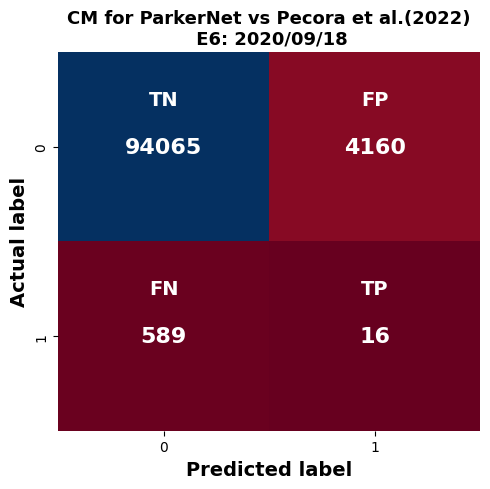

In [40]:


pecora_data = pd.read_csv('SignalROI_E6_Pecora_10s_6hr.txt', sep='\t')

predictions = df_ensemble_E6['Weighted_Voting_AUC_PRC']

# Define threshold
threshold = 0.6

# Create a binary prediction array based on the threshold
binary_predictions = (predictions >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices
ground_truth_pecora = np.zeros_like(binary_predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def plot_cm_and_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)
    if np.all(cm == 0):  # Check if cm is all zeros (invalid case)
        print("Warning: Confusion matrix is all zeros!")
        return None  # Return None if confusion matrix is empty

    # Plot confusion matrix using heatmap
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title(f'CM for ParkerNet vs Pecora et al.(2022)\n E6: 2020/09/18', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')

    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth_pecora, binary_predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
if iou is not None:
    print(f'IoU at threshold {threshold}: {iou:.4f}')

# Show the plot
plt.tight_layout()
#plt.savefig('E6_Pecora_CM_1.svg', dpi=600, bbox_inches='tight')  # Save after the plot is created
plt.show()

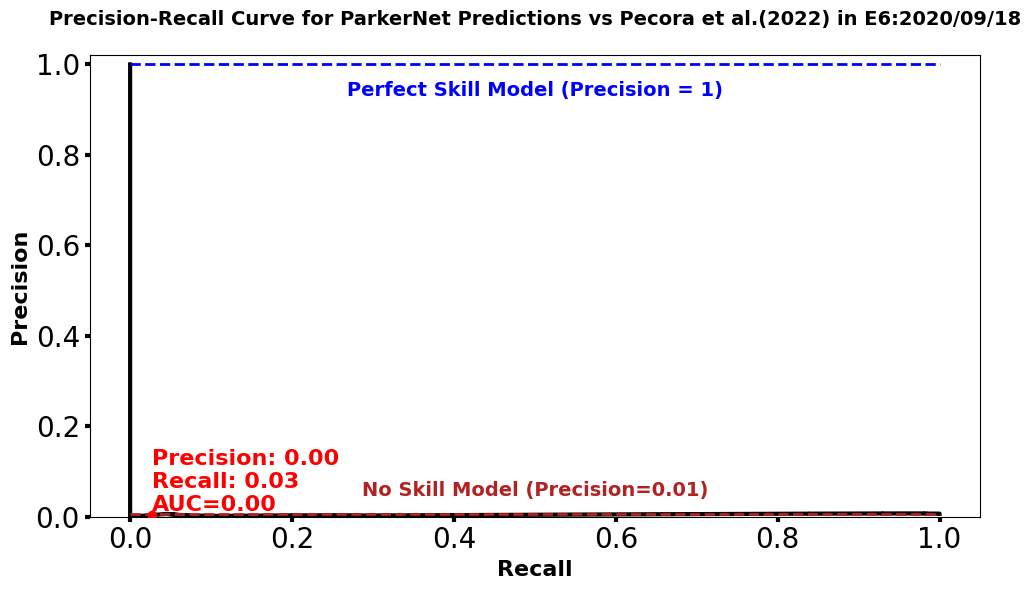

In [ ]:



pecora_data = pd.read_csv('SignalROI_E6_Pecora_10s_6hr.txt', sep='\t')  # Pecora data
predictions = df_ensemble_E6['Weighted_Voting_AUC_PRC']

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Adjust Pecora data based on the start and end indices (10-second window)
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)

# Construct ground truth based on adjusted indices for Pecora data
ground_truth_pecora = np.zeros_like(predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Define thresholds to evaluate
thresholds = np.linspace(0.1, 0.9, 9)

# Initialize list to store metrics
metrics_list = []

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def calculate_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return precision, recall, f1_score

# Evaluate metrics at various thresholds
for threshold in thresholds:
    precision, recall, f1_score = calculate_metrics(ground_truth_pecora, predictions, threshold)
    metrics_list.append({'Threshold': threshold, 'Precision': precision, 'Recall': recall, 'F1 Score': f1_score})

# Convert metrics list to dataframe
metrics_df = pd.DataFrame(metrics_list)

# Plot the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ground_truth_pecora, predictions)

# **Perfect Skill** line will be precision=1, recall=1 across all recall values
perfect_skill = np.ones_like(recall)

# **No Skill** line is precision = the proportion of positive samples in the ground truth
no_skill_precision = np.sum(ground_truth_pecora == 1) / len(ground_truth_pecora)  # Proportion of positive samples
no_skill = np.full_like(recall, no_skill_precision)

# AUC at threshold 0.6
threshold_06_index = np.where(thresholds >= 0.6)[0][0]
precision_at_06 = metrics_df.loc[threshold_06_index, 'Precision']
recall_at_06 = metrics_df.loc[threshold_06_index, 'Recall']
auc_at_06 = auc(recall, precision)  # Calculate AUC value

plt.figure(figsize=(10, 6))

# Plot Precision-Recall Curve
plt.plot(recall, precision, color='black', lw=3, label=f'Model Precision-Recall Curve at 0.6 threshold')


# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.01),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.9),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')


# Plot Precision and Recall values at threshold 0.6 directly on the graph
plt.text(recall_at_06, precision_at_06, f'Precision: {precision_at_06:.2f}\nRecall: {recall_at_06:.2f}\nAUC={auc_at_06:.2f}', color='red', fontsize=16, fontweight = 'bold', ha='left', va='bottom')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(recall_at_06, precision_at_06, color='red', zorder=5)

# Labels and Title
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Pecora et al.(2022) in E6:2020/09/18\n', fontsize=14, fontweight='bold')

plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.02, 0.2))
# Display the dataframe with metrics at different thresholds
#display(metrics_df)
# Increase the size of the x and y axis tick marks
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks
#
#plt.savefig('E6_Pecora_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


ENCOUNTER 7

In [41]:
# Read in the dataset for predicting
df_E7 = pd.read_csv('PSP_E7_ForPrediction.txt', sep="\t", parse_dates=['Datetime'])

# Separate the 'Class_Huang_Ex' column into df_gt
df_gt_E7 = df_E7[['Class_Huang_E7_Range']].copy()

pd.set_option('future.no_silent_downcasting', True)
df_gt_E7['Class_Huang_E7_Range'] = df_gt_E7['Class_Huang_E7_Range'].replace({True: 1, False: 0}).infer_objects(copy=False).astype(int)
# Create df_test by dropping the 'Class_Huang_Ex' column and other columns not needed
df_test_E7= df_E7.drop(columns=['Class_Huang_E7_Range'])

df_test_E7.pop("X_HCI")
df_test_E7.pop("Y_HCI")
df_test_E7.pop("Z_HCI")
display(df_test_E7)

,Datetime,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2021-01-12 00:00:00.000000000,17.814236,41.535600,-37.521449,-8.362526,306.013,40.28250,-0.77722,308.652938,40.289997,140.8950
1,2021-01-12 00:00:00.873799999,19.399466,42.466661,-37.776686,-6.637471,306.013,40.28250,-0.77722,308.652938,40.289997,140.8950
2,2021-01-12 00:00:01.747599999,17.717973,42.221923,-38.324460,-6.609310,306.013,40.28250,-0.77722,308.652938,40.289997,140.8950
3,2021-01-12 00:00:02.621399999,13.897688,41.848888,-39.473836,-8.688779,317.594,44.25850,-1.91183,320.663006,44.299773,122.3400
4,2021-01-12 00:00:03.495199999,19.183878,42.398007,-37.809652,-5.241170,305.668,36.07300,-0.63640,307.789193,36.078613,131.8760
...,...,...,...,...,...,...,...,...,...,...,...
98875,2021-01-12 23:59:56.974996393,68.940170,70.108894,-12.747940,5.482871,440.637,-1.34368,-2.09731,440.639049,2.490820,55.4445
98876,2021-01-12 23:59:57.848796393,69.154457,70.432934,-13.358862,5.307204,445.379,-3.35166,-1.94347,445.391611,3.874365,50.4560
98877,2021-01-12 23:59:58.722596393,68.644681,70.209396,-14.739983,6.438635,447.851,-9.68090,2.95539,447.955621,10.121964,47.5483
98878,2021-01-12 23:59:59.596396393,68.875864,70.423596,-14.683262,5.664733,447.851,-9.68090,2.95539,447.955621,10.121964,47.5483


In [42]:
df_gt_allpreds_E7 = pd.read_csv('ParkerNet_allModel_averaged_predictions_E7_20210112.csv')
display(df_gt_allpreds_E7)

,Class_Huang_E7_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,Preds_splitM_seed1843,Preds_splitM_seed2221,Preds_splitM_seed3060,Preds_splitM_seed3247,Preds_splitM_seed3364,Preds_splitM_seed3871,Preds_splitM_seed4032,Preds_splitM_seed983,SimpleSoftVoting_Predictions,Weighted_Voting_AUC_PRC
0,0,0.636117,0.778164,0.588504,0.765886,0.582340,0.616913,0.649699,0.697456,0.643355,...,0.761302,0.821427,0.809603,0.778581,0.597045,0.784108,0.754330,0.840811,0.652387,0.649764
1,0,0.636482,0.777926,0.588714,0.766686,0.581585,0.611313,0.649776,0.697938,0.645148,...,0.761142,0.822361,0.808814,0.779287,0.594154,0.783862,0.751140,0.841016,0.652057,0.649400
2,0,0.639039,0.777701,0.589028,0.767213,0.580806,0.606789,0.650461,0.698042,0.647063,...,0.761228,0.822558,0.808534,0.779732,0.593298,0.783538,0.750893,0.841008,0.651963,0.649292
3,0,0.641618,0.777965,0.589636,0.767859,0.580301,0.601268,0.649226,0.698384,0.648608,...,0.762085,0.823634,0.808042,0.780256,0.592322,0.783155,0.750088,0.840959,0.651543,0.648848
4,0,0.643883,0.777323,0.589132,0.768660,0.577425,0.595551,0.651783,0.699033,0.650894,...,0.761935,0.824129,0.807168,0.780727,0.590951,0.783383,0.746872,0.840916,0.651216,0.648510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.751036,0.789669,0.727342,0.811545,0.833985,0.261037,0.696583,0.702812,0.811021,...,0.755369,0.859219,0.761755,0.855420,0.699583,0.819264,0.880864,0.861675,0.769576,0.765197
98826,0,0.750871,0.789899,0.727330,0.811665,0.833850,0.261655,0.697217,0.702985,0.810512,...,0.754813,0.859299,0.763793,0.855317,0.700561,0.819498,0.881000,0.861843,0.769710,0.765338
98827,0,0.750999,0.789716,0.727558,0.811800,0.833556,0.261928,0.696529,0.702671,0.810981,...,0.754911,0.859294,0.763531,0.855336,0.700974,0.819053,0.881282,0.861860,0.769550,0.765179
98828,0,0.750388,0.789510,0.727604,0.812236,0.833917,0.263382,0.696101,0.702940,0.810357,...,0.755045,0.859239,0.762727,0.855259,0.700953,0.819073,0.881176,0.862006,0.769298,0.764931


In [45]:
df_test_E7.reset_index(drop=True, inplace=True)
df_gt_allpreds_E7.reset_index(drop=True, inplace=True)
df_ensemble_E7 = pd.concat([df_gt_allpreds_E7, df_test_E7], axis=1, join='inner')
display(df_ensemble_E7)

,Class_Huang_E7_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,0,0.636117,0.778164,0.588504,0.765886,0.582340,0.616913,0.649699,0.697456,0.643355,...,17.814236,41.535600,-37.521449,-8.362526,306.013,40.282500,-0.777220,308.652938,40.289997,140.8950
1,0,0.636482,0.777926,0.588714,0.766686,0.581585,0.611313,0.649776,0.697938,0.645148,...,19.399466,42.466661,-37.776686,-6.637471,306.013,40.282500,-0.777220,308.652938,40.289997,140.8950
2,0,0.639039,0.777701,0.589028,0.767213,0.580806,0.606789,0.650461,0.698042,0.647063,...,17.717973,42.221923,-38.324460,-6.609310,306.013,40.282500,-0.777220,308.652938,40.289997,140.8950
3,0,0.641618,0.777965,0.589636,0.767859,0.580301,0.601268,0.649226,0.698384,0.648608,...,13.897688,41.848888,-39.473836,-8.688779,317.594,44.258500,-1.911830,320.663006,44.299773,122.3400
4,0,0.643883,0.777323,0.589132,0.768660,0.577425,0.595551,0.651783,0.699033,0.650894,...,19.183878,42.398007,-37.809652,-5.241170,305.668,36.073000,-0.636400,307.789193,36.078613,131.8760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98825,0,0.751036,0.789669,0.727342,0.811545,0.833985,0.261037,0.696583,0.702812,0.811021,...,69.725159,71.129804,-14.065960,4.196412,451.635,1.779270,3.053840,451.638505,3.534366,55.5261
98826,0,0.750871,0.789899,0.727330,0.811665,0.833850,0.261655,0.697217,0.702985,0.810512,...,69.313484,71.201214,-16.286615,6.390343,447.955,-0.433786,-1.999790,447.955210,2.046297,53.4005
98827,0,0.750999,0.789716,0.727558,0.811800,0.833556,0.261928,0.696529,0.702671,0.810981,...,68.699975,70.562405,-16.104859,7.386460,450.147,-1.284780,1.484070,450.148833,1.962937,48.9033
98828,0,0.750388,0.789510,0.727604,0.812236,0.833917,0.263382,0.696101,0.702940,0.810357,...,68.814132,70.581157,-15.694422,6.746629,449.524,13.756900,0.656624,449.734454,13.772562,53.7512


In [46]:
df_ensemble_E7['prediction_0.6'] = (df_ensemble_E7['Weighted_Voting_AUC_PRC'] > 0.6).astype(int)
df_ensemble_E7.to_csv('predictions_E7.csv', index=False)

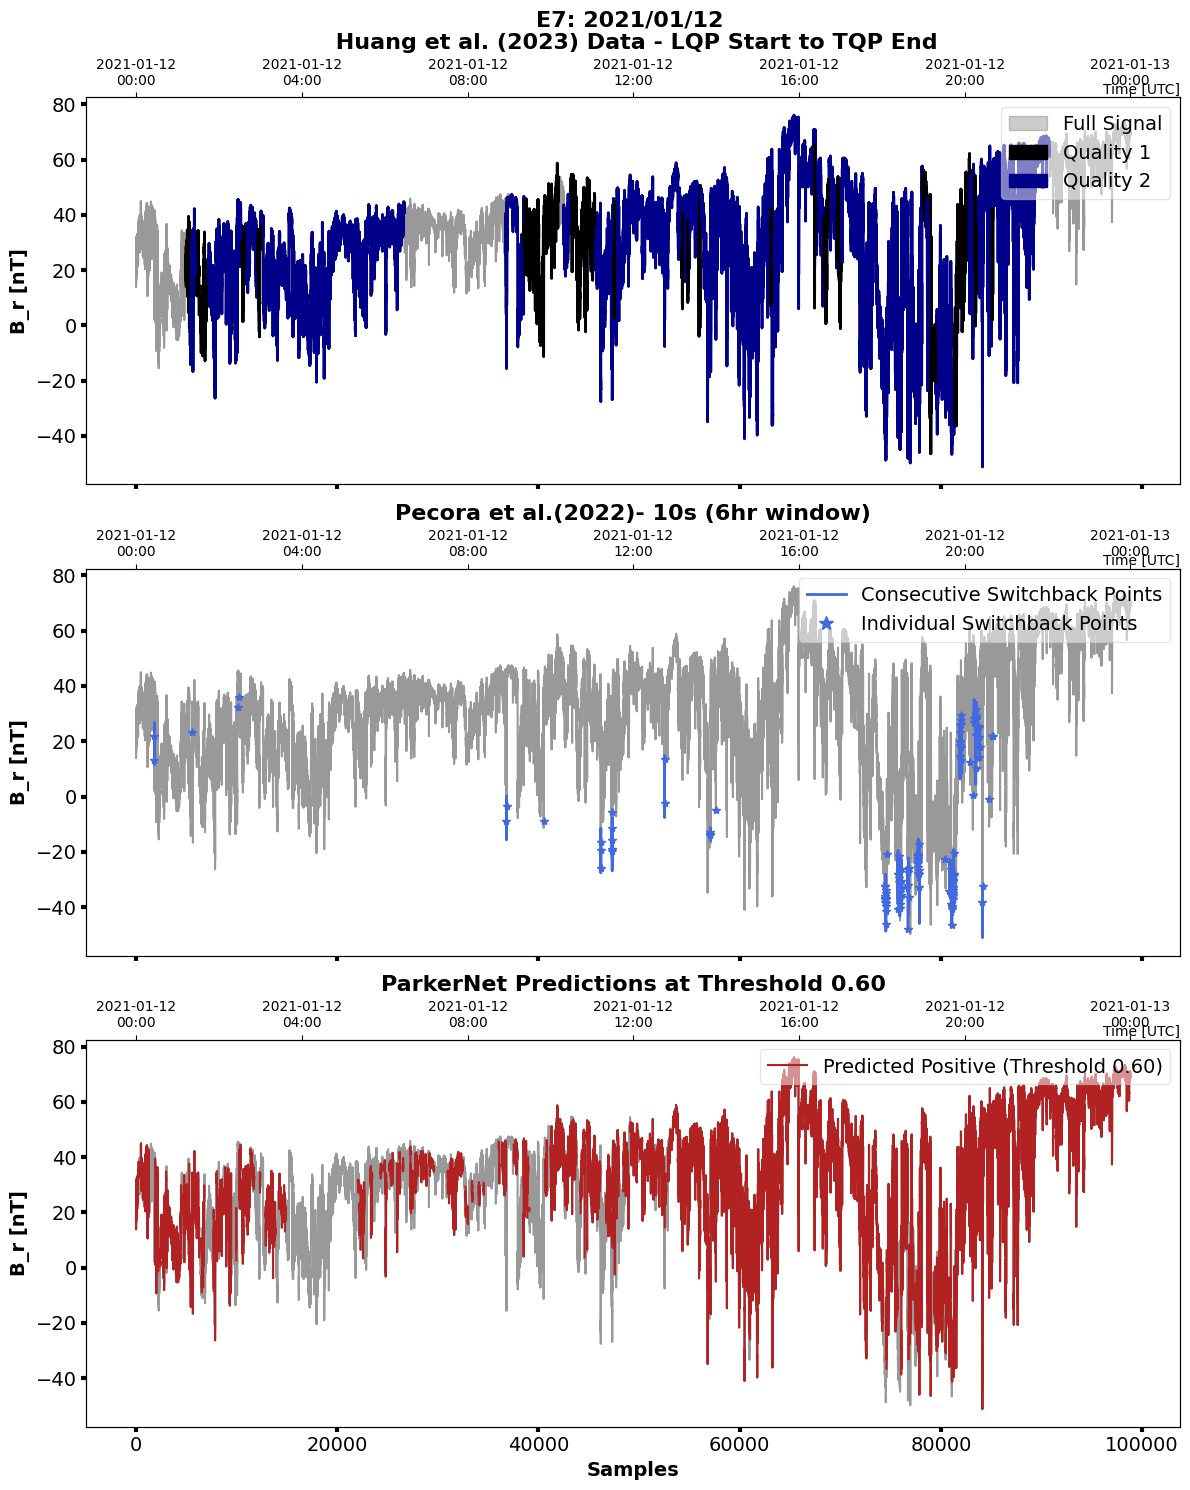

In [47]:



roi_data = pd.read_csv('SingalROI_E7_Huang_allRegions.txt', sep='\t')


signal_data = df_ensemble_E7['B_r']
datetime_axis = df_ensemble_E7['Datetime']
predictions = df_ensemble_E7['Weighted_Voting_AUC_PRC']

# Define the threshold (set to 0.6)
threshold = 0.6

# Define a color map for quality levels
quality_colors = {
    1: 'black',
    2: '#00008B',  # Dark Blue for Quality 1
    3: '#CC5500',  # Burnt Orange for Quality 2
    4: '#8B0000',  # Red Brown for Quality 3
    5: '#8B4513'   # Red Brown for Quality 4
}

# Load the Pecora data 10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E7_Pecora_10s_6hr.txt', sep='\t')

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds
# Create binary mask for predictions based on the threshold
binary_predictions = (predictions > threshold).astype(int)


# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Perform DBSCAN clustering on the start indices
indices = pecora_data['start_index'].values.reshape(-1, 1)  # Reshape for DBSCAN
db = DBSCAN(eps=15, min_samples=2)  # Adjust parameters as needed
labels = db.fit_predict(indices)

# Initialize clusters list
clusters = []

# Group indices by cluster labels
for label in np.unique(labels):
    if label != -1:  # Skip noise
        cluster_indices = indices[labels == label].flatten()
        start_index = int(cluster_indices[0])
        end_index = int(cluster_indices[-1])
        clusters.append((start_index, end_index))

# Create a figure with three subplots (top, middle, bottom)
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]})
# --- Top Subplot: Full Ground Truth Switchbacks (LQP Start to TQP End) for Huang ---
axs[0].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Track legend patches in defined order
legend_patches = [mpatches.Patch(color='black', alpha=0.2, label='Full Signal')]
added_qualities = set()  # Track added quality levels to avoid duplicates

# Plot each switchback (from LQP Start to TQP End) with color based on quality
for _, row in roi_data.iterrows():
    quality_flag = row['QualityFlag']
    color = quality_colors.get(quality_flag, 'gray')  # Default to gray if the quality level is unknown

    # Define start and end points of the full ground truth switchback
    switchback_start = row['LQP_Start_Index']
    switchback_end = row['TQP_End_Index']

    # Plot the full ground truth switchback as a solid line
    axs[0].plot(range(switchback_start, switchback_end), signal_data[switchback_start:switchback_end], color=color, linewidth=2)

    # Add switchback region to legend if not already added
    if quality_flag not in added_qualities:
        legend_patches.append(mpatches.Patch(color=color, label=f'Quality {quality_flag}'))
        added_qualities.add(quality_flag)

# Sort the legend patches to display qualities in ascending order
legend_patches = [legend_patches[0]] + sorted(legend_patches[1:], key=lambda x: int(x.get_label().split()[-1]))

# Add legend for the top plot
axs[0].legend(handles=legend_patches, loc='upper right', fontsize=14,framealpha=0.5)
axs[0].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[0].set_title('E7: 2021/01/12 \n Huang et al. (2023) Data - LQP Start to TQP End', fontsize=16, fontweight='bold')

# --- Middle Subplot: Pecora Data (Sparse Points and DBSCAN Segments) ---
axs[1].plot(signal_data, color='black', alpha=0.4, label='Full Signal')  # Faint background for context

# Plot sparse points as asterisks
sparse_points_color = '#4169E1'  # Royal Blue
for _, row in pecora_data.iterrows():
    start_idx = int(row['start_index'])
    axs[1].plot(start_idx, signal_data[start_idx], marker='*', color=sparse_points_color)

# Plot clustered segments
for start_idx, end_idx in clusters:
    axs[1].plot(range(start_idx, end_idx), signal_data[start_idx:end_idx], color=sparse_points_color, linewidth=2)

# Add legend for Pecora data
pecora_line = Line2D([0], [0], color=sparse_points_color, lw=2, label='Consecutive Switchback Points')
sparse_asterisk = Line2D([0], [0], color=sparse_points_color, marker='*', linestyle='None', markersize=10, label='Individual Switchback Points')
axs[1].legend(handles=[pecora_line, sparse_asterisk], loc='upper right', fontsize=14, framealpha=0.5)

axs[1].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[1].set_title('Pecora et al.(2022)- 10s (6hr window)', fontsize=16, fontweight='bold')

# --- Bottom Subplot: Model Predictions ---
model_prediction_line = signal_data.copy()
model_prediction_line[binary_predictions == 0] = np.nan  # Mask out negative predictions
model_prediction_color = '#B22222'
axs[2].plot(signal_data, color='black', alpha=0.4)
axs[2].plot(model_prediction_line, color=model_prediction_color, linewidth=1.5, label=f'Predicted Positive (Threshold {threshold:.2f})')

axs[2].set_xlabel('Samples', fontsize=14, fontweight='bold')
axs[2].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[2].set_title(f'ParkerNet Predictions at Threshold {threshold:.2f}', fontsize=16, fontweight='bold')
axs[2].legend(loc='upper right', fontsize=14, framealpha=0.5)


# --- Secondary datetime axis on top, ticks every 4 h ---
start_time    = datetime_axis.min().floor('h')
end_time      = datetime_axis.max().ceil('h')
four_hour_times = pd.date_range(start=start_time, end=end_time, freq='4h')
sample_ticks  = datetime_axis.searchsorted(four_hour_times)
tick_labels   = four_hour_times.strftime('%Y-%m-%d\n%H:%M')



# Apply tick parameters to all axes after plotting
for ax in axs:
    ax.tick_params(axis='x', labelsize=14, width=3)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=14, width=3)  # y-axis ticks
for ax in axs:
    twin = ax.twiny()
    twin.set_xlim(ax.get_xlim())
    twin.set_xticks(sample_ticks)
    twin.set_xticklabels(tick_labels, fontsize=10)
    twin.set_xlabel('Time [UTC]')
    twin.xaxis.label.set_horizontalalignment('right')
    twin.xaxis.set_label_coords(1, 1.01, transform=ax.transAxes)
# Adjust layout and show the plot for Pecora and Model Predictions
plt.tight_layout()
plt.tight_layout()
plt.savefig('APJS_E7.svg', dpi=600, bbox_inches='tight')
plt.savefig('APJS_E7.pdf', dpi=600, bbox_inches='tight')
plt.show()

#plt.savefig('E7_preds_DBSCAN.svg', dpi=600, bbox_inches='tight')
#plt.show()

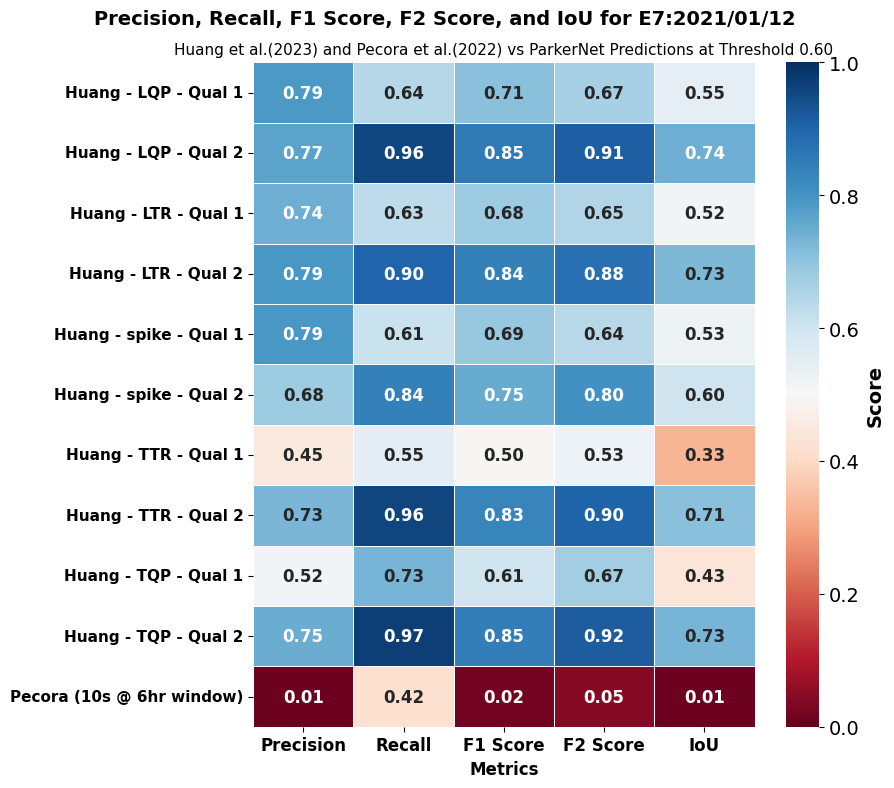

In [48]:



huang_data_path = 'SingalROI_E7_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E7['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E7['Class_Huang_E7_Range']

# Define threshold
threshold = 0.6

# Define regions for Huang ground truths
regions = {
    "LQP": ("LQP_Start_Index", "LQP_End_Index"),
    "LTR": ("LQP_End_Index", "spike_Start_Index"),
    "spike": ("spike_Start_Index", "spike_End_Index"),
    "TTR": ("spike_End_Index", "TQP_Start_Index"),
    "TQP": ("TQP_Start_Index", "TQP_End_Index")
}

# Initialize lists to store Precision, Recall, F1, F2, and IoU values for the heatmap
heatmap_data = []
row_labels = []

# Loop through regions and quality flags for Huang data
for region, (start_col, end_col) in regions.items():
    for quality in sorted(roi_data['QualityFlag'].unique()):
        row_labels.append(f"Huang - {region} - Qual {quality}")
        row_data = []

        # Filter quality rows for the current region and quality
        quality_rows = roi_data[roi_data['QualityFlag'] == quality]
        ground_truth_segment = []



        # Construct ground truth and predictions for the current region and quality
        for _, row in quality_rows.iterrows():
            start, end = row[start_col], row[end_col]
            gt_segment = ground_truth[start:end].values  # Get the ground truth for the segment
            pred_segment = (predictions[start:end] >= threshold).astype(int).values  # Get the predicted values
            ground_truth_segment.extend(gt_segment)
            ground_truth_segment.extend(pred_segment)

        # Calculate confusion matrix
        cm = confusion_matrix(ground_truth_segment[:len(ground_truth_segment)//2], ground_truth_segment[len(ground_truth_segment)//2:])

        # Get TP, FP, FN
        TN, FP, FN, TP = cm.ravel()

        # Calculate Precision, Recall, F1, and F2 for the current region and quality
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        F1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        F2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) != 0 else 0

        # Calculate IoU for the current region and quality
        iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0

        # Append Precision, Recall, F1, F2, IoU results for the current region and quality
        row_data.extend([precision, recall, F1_score, F2_score, iou])

        # Append the data for the current region and quality
        heatmap_data.append(row_data)

# Load Pecora 10s 3 hr window data and model predictions
#pecora_data = pd.read_csv('SingalROI_E7_Pecora.txt', sep='\t')  # Pecora data

#Load Pecora d10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E7_Pecora_10s_6hr.txt', sep = '\t')
# Assuming df_ensemble_E7 contains model predictions
predictions_pecora = df_ensemble_E7['Weighted_Voting_AUC_PRC']

# Create binary predictions based on threshold for Pecora data
binary_predictions_pecora = (predictions_pecora >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices for Pecora (10 seconds)
ground_truth_pecora = np.zeros_like(binary_predictions_pecora)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Calculate Precision, Recall, F1, F2, and IoU for Pecora data (as one whole segment)
cm_pecora = confusion_matrix(ground_truth_pecora, binary_predictions_pecora)
TN_pecora, FP_pecora, FN_pecora, TP_pecora = cm_pecora.ravel()  # Get confusion matrix values

# Calculate Precision, Recall, F1, and F2 for Pecora (single value)
precision_pecora = TP_pecora / (TP_pecora + FP_pecora) if (TP_pecora + FP_pecora) != 0 else 0
recall_pecora = TP_pecora / (TP_pecora + FN_pecora) if (TP_pecora + FN_pecora) != 0 else 0
F1_score_pecora = (2 * precision_pecora * recall_pecora) / (precision_pecora + recall_pecora) if (precision_pecora + recall_pecora) != 0 else 0
F2_score_pecora = (5 * precision_pecora * recall_pecora) / (4 * precision_pecora + recall_pecora) if (4 * precision_pecora + recall_pecora) != 0 else 0

# Calculate IoU for Pecora
iou_pecora = TP_pecora / (TP_pecora + FP_pecora + FN_pecora) if (TP_pecora + FP_pecora + FN_pecora) != 0 else 0

# Append Pecora Precision, Recall, F1, F2, IoU to heatmap data
row_labels.append("Pecora (10s @ 6hr window)")
heatmap_data.append([precision_pecora, recall_pecora, F1_score_pecora, F2_score_pecora, iou_pecora])

# Convert heatmap data to DataFrame
heatmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=["Precision", "Recall", "F1 Score", "F2 Score", "IoU"])

# Plot combined heatmap for Precision, Recall, F1, F2, and IoU (including Huang and Pecora)
fig, ax = plt.subplots(figsize=(9, 8))  # Adjust figure size for better readability

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdBu", cbar_kws={'label': 'Score'},
            annot_kws={"weight": "bold", "size": 12},  # Make annotation bold
            linewidths=0.5,  # Optional: thin line between cells
            cbar=True, vmin=0, vmax=1, ax=ax)  # Set color scale to go from 0 to 1

# Title and labels in bold with line breaks for title
plt.suptitle("Precision, Recall, F1 Score, F2 Score, and IoU for E7:2021/01/12", fontsize=14, fontweight='bold', y=0.98)
ax.set_title("Huang et al.(2023) and Pecora et al.(2022) vs ParkerNet Predictions at Threshold 0.60", fontsize=11, fontweight='normal', loc='center')

# Set xlabel with bold font
ax.set_xlabel("Metrics", fontsize=12, fontweight='bold')

# Make the y-axis labels bold and adjust font size
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontweight='bold')

# Make the legend label bold
cbar = ax.collections[0].colorbar
cbar.set_label('Score', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=12, fontweight = 'bold')
# Adjust layout to ensure everything fits without excessive width

plt.tight_layout()
#plt.savefig('E7_heatmap_1.svg', dpi=600, bbox_inches='tight')
plt.show()


 (True Negatives):  8810
 (False Positives):  14993
(False Negatives):  25829
 (True Positives):  49198
Precision: 0.7664
Recall: 0.6557
F1 Score: 0.7068
Total Switchbacks (Ground Truth 1):  75027
Intersection over Union (IoU): 0.5465


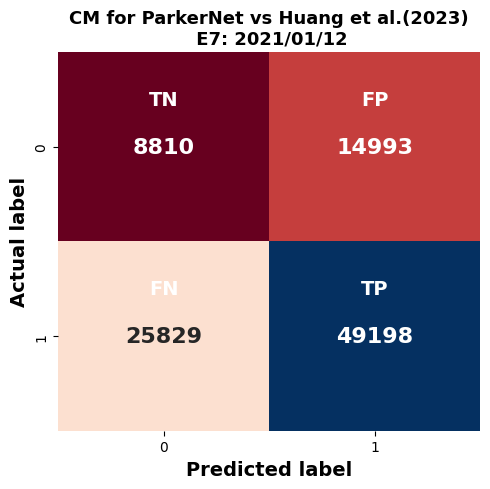

IoU at threshold 0.6: 0.5465


In [50]:



huang_data_path = 'SingalROI_E7_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E7['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E7['Class_Huang_E7_Range']

# Define threshold
threshold = 0.6

# Confusion Matrix Function
def plot_cm_and_metrics(labels, predictions, threshold=0.6):
    # Compute the confusion matrix
    cm = confusion_matrix(labels, predictions > threshold)

    # Plot the confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title('CM for ParkerNet vs Huang et al.(2023)\n E7: 2021/01/12', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')
    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()

    # Position the labels slightly above the center of each section
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # Show the plot
    plt.savefig('E7_Huang_CM.svg', dpi=600, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth, predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
print(f'IoU at threshold {threshold}: {iou:.4f}')

<ipython-input-116-3e9484d7aec3>:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)


   Threshold  Precision    Recall  F1 Score      AUC
0       0.50   0.739201  0.882042  0.804329  0.71131
1       0.55   0.738605  0.798459  0.767366  0.71131
2       0.60   0.766431  0.655737  0.706776  0.71131
3       0.65   0.786030  0.481747  0.597372  0.71131
4       0.70   0.757548  0.334746  0.464319  0.71131
5       0.75   0.607858  0.164767  0.259259  0.71131
6       0.80   0.452061  0.013009  0.025290  0.71131
7       0.85   0.000000  0.000000  0.000000  0.71131
8       0.90   0.000000  0.000000  0.000000  0.71131
9       0.95   0.000000  0.000000  0.000000  0.71131


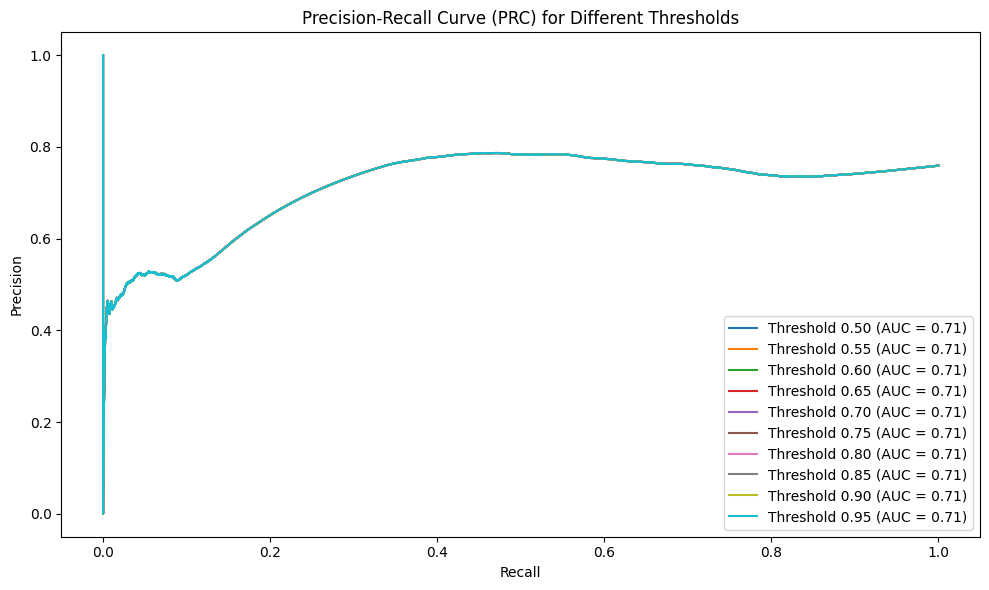

In [ ]:

huang_data_path = 'SingalROI_E7_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E7['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E7['Class_Huang_E7_Range']

# Define thresholds for analysis
thresholds = np.arange(0.5, 1.0, 0.05)

# Initialize lists to store metrics for each threshold
precision_list = []
recall_list = []
f1_list = []
auc_list = []

# Create an empty DataFrame to store the metrics for each threshold
metrics_df = pd.DataFrame(columns=['Threshold', 'Precision', 'Recall', 'F1 Score', 'AUC'])

# Function to calculate confusion matrix and metrics
def calculate_metrics(labels, predictions, threshold):
    cm = confusion_matrix(labels, predictions > threshold)
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # Calculate Precision-Recall curve and AUC
    precision_curve, recall_curve, _ = precision_recall_curve(labels, predictions)
    auc_score = auc(recall_curve, precision_curve)

    return precision, recall, f1_score, auc_score

# Loop through each threshold and calculate metrics
for threshold in thresholds:
    precision, recall, f1_score, auc_score = calculate_metrics(ground_truth, predictions, threshold)

    # Add the results to the metrics dataframe using pd.concat
    new_row = pd.DataFrame({
        'Threshold': [threshold],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1_score],
        'AUC': [auc_score]
    })

    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Print the metrics DataFrame
print(metrics_df)

# Plot the Precision-Recall curve and include AUC in the legend
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    # Get precision and recall for the current threshold
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Plot each threshold with its AUC score in the legend
    plt.plot(recall_curve, precision_curve, label=f'Threshold {threshold:.2f} (AUC = {auc_score:.2f})')

plt.title('Precision-Recall Curve (PRC) for Different Thresholds')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

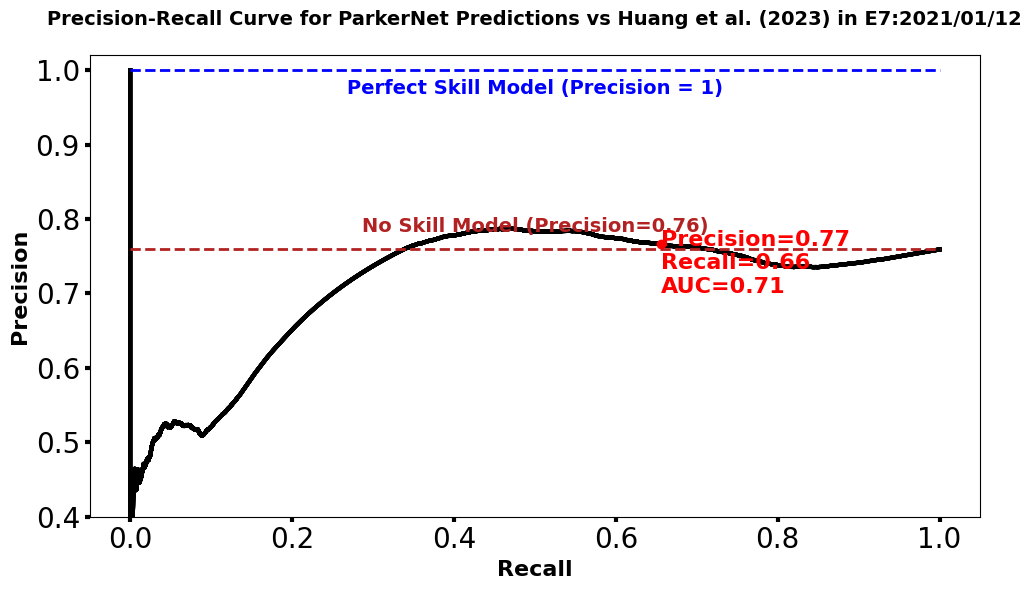

In [ ]:


huang_data_path = 'SingalROI_E7_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E7['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E7['Class_Huang_E7_Range']

# Define thresholds (from 0.5 to 0.95)
thresholds = np.round(np.arange(0.5, 0.95, 0.05), 2)

# Initialize lists to store the Precision-Recall curve and AUC for each threshold
precision_dict = {}
recall_dict = {}
auc_dict = {}

# Calculate Precision-Recall curve and AUC for each threshold
for threshold in thresholds:
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Store precision, recall, and auc values for each threshold
    precision_dict[threshold] = precision_curve
    recall_dict[threshold] = recall_curve
    auc_dict[round(threshold, 2)] = auc_score  # Round threshold to two decimal places

# Plot Precision-Recall curves for all thresholds
plt.figure(figsize=(10, 6))

for threshold in thresholds:
    plt.plot(recall_dict[threshold], precision_dict[threshold], color='black', linewidth=3)

# Provided precision and recall at threshold 0.6

threshold_0_6_precision = 0.766431
threshold_0_6_recall =  0.655737
# Calculate AUC at threshold 0.6
auc_at_06 = auc_dict[0.6]  # AUC for threshold 0.6

# Plot the red dot for threshold 0.6
plt.plot(threshold_0_6_recall, threshold_0_6_precision, 'k-', label=f'Model Precision-Recall curve at 0.60 threshold')

# Calculate No Skill Model baseline
num_positives = np.sum(ground_truth == 1)
num_total = len(ground_truth)
no_skill_precision = num_positives / num_total
no_skill_recall = num_positives / num_total  # Recall is the same as the proportion of positives

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.005),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.95),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')

# Adding labels and title
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Huang et al. (2023) in E7:2021/01/12\n', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(threshold_0_6_recall, threshold_0_6_precision, color='red', zorder=5)

# Add the red dot annotation for threshold 0.6
plt.annotate(f'Precision={threshold_0_6_precision:.2f}\nRecall={threshold_0_6_recall:.2f}\nAUC={auc_at_06:.2f}',
             (threshold_0_6_recall, threshold_0_6_precision),
             textcoords="offset points",
             xytext=(0,10),
             ha='left', va= 'top', fontsize=16, fontweight='bold', color='red')

# Set y-axis limits to ensure the perfect skill line is visible
plt.ylim(0.4, 1.02)
# Customize y-axis ticks to show 0.1 and 0.9
plt.yticks(np.arange(0.4, 1.02, 0.1))  # Set y-ticks from 0 to 1 with step of 0.1

# Apply the tick parameters to all axes after plotting
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks

# Remove the legend as per request
#plt.legend(loc='upper right', bbox_to_anchor=(1, 0.95), fontsize=16, prop={'weight': 'bold'},labelspacing=0.5, markerscale=1.5)
plt.savefig('E7_Huang_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


 (True Negatives):  33761
 (False Positives):  63551
(False Negatives):  878
 (True Positives):  640
Precision: 0.0100
Recall: 0.4216
F1 Score: 0.0195
Total Switchbacks (Ground Truth 1):  1518
Intersection over Union (IoU): 0.0098
IoU at threshold 0.6: 0.0098


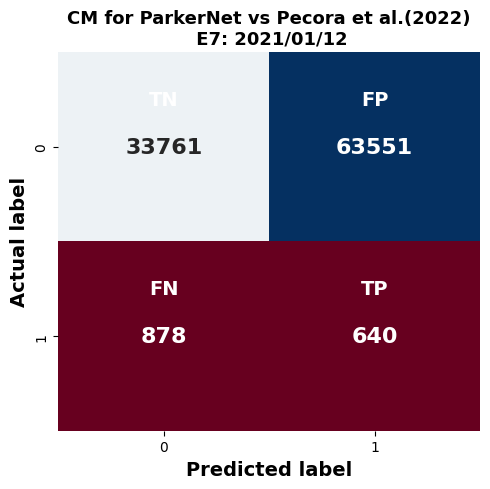

In [51]:



pecora_data = pd.read_csv('SignalROI_E7_Pecora_10s_6hr.txt', sep='\t')

predictions = df_ensemble_E7['Weighted_Voting_AUC_PRC']


threshold = 0.6

# Create a binary prediction array based on the threshold
binary_predictions = (predictions >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices
ground_truth_pecora = np.zeros_like(binary_predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def plot_cm_and_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)
    if np.all(cm == 0):  # Check if cm is all zeros (invalid case)
        print("Warning: Confusion matrix is all zeros!")
        return None  # Return None if confusion matrix is empty

    # Plot confusion matrix using heatmap
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title(f'CM for ParkerNet vs Pecora et al.(2022)\n E7: 2021/01/12', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')

    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth_pecora, binary_predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
if iou is not None:
    print(f'IoU at threshold {threshold}: {iou:.4f}')

# Show the plot
plt.tight_layout()
#plt.savefig('E7_Pecora_CM_1.svg', dpi=600, bbox_inches='tight')  # Save after the plot is created
plt.show()

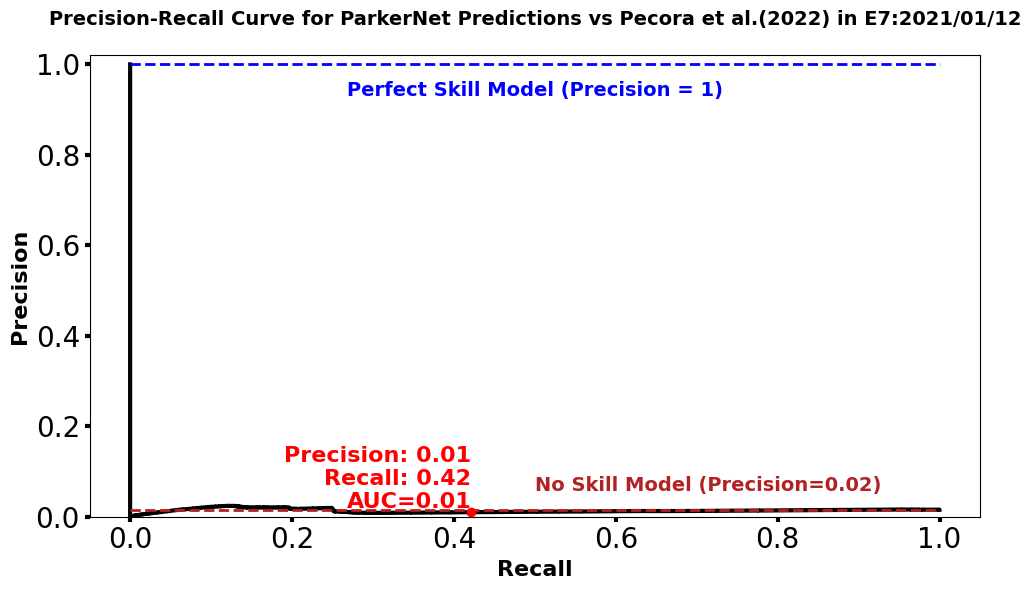

In [ ]:



pecora_data = pd.read_csv('SignalROI_E7_Pecora_10s_6hr.txt', sep='\t')
predictions = df_ensemble_E7['Weighted_Voting_AUC_PRC']

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Adjust Pecora data based on the start and end indices (10-second window)
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)

# Construct ground truth based on adjusted indices for Pecora data
ground_truth_pecora = np.zeros_like(predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Define thresholds to evaluate
thresholds = np.linspace(0.1, 0.9, 9)

# Initialize list to store metrics
metrics_list = []

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def calculate_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return precision, recall, f1_score

# Evaluate metrics at various thresholds
for threshold in thresholds:
    precision, recall, f1_score = calculate_metrics(ground_truth_pecora, predictions, threshold)
    metrics_list.append({'Threshold': threshold, 'Precision': precision, 'Recall': recall, 'F1 Score': f1_score})

# Convert metrics list to dataframe
metrics_df = pd.DataFrame(metrics_list)

# Plot the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ground_truth_pecora, predictions)

# **Perfect Skill** line will be precision=1, recall=1 across all recall values
perfect_skill = np.ones_like(recall)

# **No Skill** line is precision = the proportion of positive samples in the ground truth
no_skill_precision = np.sum(ground_truth_pecora == 1) / len(ground_truth_pecora)  # Proportion of positive samples
no_skill = np.full_like(recall, no_skill_precision)

# AUC at threshold 0.6
threshold_06_index = np.where(thresholds >= 0.6)[0][0]
precision_at_06 = metrics_df.loc[threshold_06_index, 'Precision']
recall_at_06 = metrics_df.loc[threshold_06_index, 'Recall']
auc_at_06 = auc(recall, precision)  # Calculate AUC value

plt.figure(figsize=(10, 6))

# Plot Precision-Recall Curve
plt.plot(recall, precision, color='black', lw=3, label=f'Model Precision-Recall Curve at 0.6 threshold')

# Plot No Skill line
#plt.plot(recall, no_skill, color='#B22222', linestyle='--', lw=2, label=f'No Skill Model (Precision={no_skill_precision:.2f})')


# Plot Perfect Skill line
#plt.plot(recall, perfect_skill, color='blue', linestyle='--', lw=2, label='Perfect Skill Model (Precision = 1)')

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.01),
             textcoords="offset points",
             xytext=(0, 10),
             ha='left', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.9),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')


# Plot Precision and Recall values at threshold 0.6 directly on the graph
plt.text(recall_at_06, precision_at_06, f'Precision: {precision_at_06:.2f}\nRecall: {recall_at_06:.2f}\nAUC={auc_at_06:.2f}', color='red', fontsize=16, fontweight = 'bold', ha='right', va='bottom')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(recall_at_06, precision_at_06, color='red', zorder=5)

# Labels and Title
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Pecora et al.(2022) in E7:2021/01/12\n', fontsize=14, fontweight='bold')

plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.02, 0.2))

# Increase the size of the x and y axis tick marks
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks

#plt.savefig('E7_Pecora_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


ENCOUNTER 8

In [52]:
# Read in the entire dataset
df_E8 = pd.read_csv('PSP_E8_ForPrediction.txt', sep="\t", parse_dates=['Datetime'])

# Separate the 'Class_Huang_E1' column into df_gt
df_gt_E8 = df_E8[['Class_Huang_E8_Range']].copy()


pd.set_option('future.no_silent_downcasting', True)
df_gt_E8['Class_Huang_E8_Range'] = df_gt_E8['Class_Huang_E8_Range'].replace({True: 1, False: 0}).infer_objects(copy=False).astype(int)
# Create df_test by dropping the 'Class_Huang_Ex' column and other columns not needed
df_test_E8 = df_E8.drop(columns=['Class_Huang_E8_Range'])

df_test_E8.pop("X_HCI")
df_test_E8.pop("Y_HCI")
df_test_E8.pop("Z_HCI")




display(df_test_E8)

,Datetime,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2021-04-26 10:00:00.559,-56.627308,85.793983,-54.320417,34.687863,287.976,-90.0595,-1.417990,301.733162,90.070662,501.871
1,2021-04-26 10:00:01.433,-45.031928,84.932947,-69.413505,19.170191,262.105,18.0063,0.831360,262.724093,18.025482,400.531
2,2021-04-26 10:00:02.307,-35.703356,87.452128,-76.798055,21.799171,262.105,18.0063,0.831360,262.724093,18.025482,400.531
3,2021-04-26 10:00:03.181,-77.538072,88.817473,-19.880633,38.485730,262.105,18.0063,0.831360,262.724093,18.025482,400.531
4,2021-04-26 10:00:04.055,-72.113839,85.918408,-12.268679,45.067133,263.430,28.2589,0.037897,264.941374,28.258925,377.599
...,...,...,...,...,...,...,...,...,...,...,...
123593,2021-04-27 15:59:56.123,-165.906642,197.797012,4.574950,107.599787,324.834,191.0300,-14.127400,377.106314,191.551675,286.706
123594,2021-04-27 15:59:56.997,-165.090727,197.852929,10.303380,108.557238,324.834,191.0300,-14.127400,377.106314,191.551675,286.706
123595,2021-04-27 15:59:57.870,-163.413484,198.017346,13.957413,110.959872,324.834,191.0300,-14.127400,377.106314,191.551675,286.706
123596,2021-04-27 15:59:58.744,-165.768391,197.053188,12.800578,105.768354,324.834,191.0300,-14.127400,377.106314,191.551675,286.706


In [53]:
df_gt_allpreds_E8 = pd.read_csv('ParkerNet_allModel_predictions_E8_Oct30_AUCPRC.csv')
display(df_gt_allpreds_E8)

,Class_Huang_E8_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,Preds_splitM_seed1843,Preds_splitM_seed2221,Preds_splitM_seed3060,Preds_splitM_seed3247,Preds_splitM_seed3364,Preds_splitM_seed3871,Preds_splitM_seed4032,Preds_splitM_seed983,SimpleSoftVoting_Predictions,Weighted_Voting_AUC_PRC
0,0,0.172144,0.109497,0.218417,0.258315,0.126965,0.179893,0.179724,0.201235,0.136782,...,0.232106,0.150480,0.114881,0.158166,0.582583,0.156821,0.127620,0.148533,0.363618,0.186270
1,0,0.170810,0.108996,0.218146,0.257359,0.126647,0.179342,0.178972,0.199641,0.136412,...,0.230130,0.150127,0.114375,0.154800,0.587962,0.156094,0.127316,0.148399,0.361767,0.185408
2,0,0.171172,0.109387,0.217629,0.253583,0.125511,0.177059,0.179034,0.197854,0.136235,...,0.228739,0.149965,0.114206,0.154715,0.587132,0.155421,0.127710,0.149784,0.360252,0.184727
3,0,0.170745,0.109017,0.217759,0.249233,0.126242,0.177686,0.178821,0.196328,0.136462,...,0.228097,0.149541,0.113844,0.153695,0.585718,0.155770,0.127952,0.148897,0.359112,0.184155
4,0,0.170878,0.109132,0.218127,0.246663,0.125523,0.173702,0.178847,0.198179,0.136733,...,0.227519,0.149348,0.113507,0.153468,0.585081,0.155684,0.128021,0.147905,0.358340,0.183903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123543,0,0.790845,0.213235,0.230104,0.479453,0.540195,0.222654,0.171070,0.167161,0.221588,...,0.475669,0.435859,0.101908,0.337912,0.207667,0.432701,0.236406,0.272017,0.622080,0.294188
123544,0,0.790777,0.213482,0.230136,0.479199,0.541686,0.223121,0.171123,0.167185,0.221630,...,0.475421,0.436923,0.101912,0.338810,0.207848,0.433518,0.238764,0.272335,0.622528,0.294431
123545,0,0.790652,0.213698,0.230157,0.479915,0.543316,0.223667,0.171138,0.167246,0.221701,...,0.475396,0.438518,0.101956,0.339567,0.207970,0.434496,0.241125,0.272684,0.623190,0.294757
123546,0,0.790663,0.213756,0.230205,0.480644,0.545224,0.224080,0.171175,0.167302,0.221804,...,0.475811,0.440590,0.102029,0.340418,0.208373,0.435650,0.243612,0.272787,0.624147,0.295211


In [54]:
df_test_E8.reset_index(drop=True, inplace=True)
df_gt_allpreds_E8.reset_index(drop=True, inplace=True)
df_ensemble_E8 = pd.concat([df_gt_allpreds_E8, df_test_E8], axis=1, join='inner')
display(df_ensemble_E8)

,Class_Huang_E8_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,Preds_splitM_seed641,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,0,0.172144,0.109497,0.218417,0.258315,0.126965,0.179893,0.179724,0.201235,0.136782,...,-56.627308,85.793983,-54.320417,34.687863,287.976,-90.0595,-1.417990,301.733162,90.070662,501.871
1,0,0.170810,0.108996,0.218146,0.257359,0.126647,0.179342,0.178972,0.199641,0.136412,...,-45.031928,84.932947,-69.413505,19.170191,262.105,18.0063,0.831360,262.724093,18.025482,400.531
2,0,0.171172,0.109387,0.217629,0.253583,0.125511,0.177059,0.179034,0.197854,0.136235,...,-35.703356,87.452128,-76.798055,21.799171,262.105,18.0063,0.831360,262.724093,18.025482,400.531
3,0,0.170745,0.109017,0.217759,0.249233,0.126242,0.177686,0.178821,0.196328,0.136462,...,-77.538072,88.817473,-19.880633,38.485730,262.105,18.0063,0.831360,262.724093,18.025482,400.531
4,0,0.170878,0.109132,0.218127,0.246663,0.125523,0.173702,0.178847,0.198179,0.136733,...,-72.113839,85.918408,-12.268679,45.067133,263.430,28.2589,0.037897,264.941374,28.258925,377.599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123543,0,0.790845,0.213235,0.230104,0.479453,0.540195,0.222654,0.171070,0.167161,0.221588,...,-172.631883,200.232194,4.518288,101.344707,324.834,191.0300,-14.127400,377.106314,191.551675,286.706
123544,0,0.790777,0.213482,0.230136,0.479199,0.541686,0.223121,0.171123,0.167185,0.221630,...,-171.385948,200.226845,4.240339,103.439190,324.834,191.0300,-14.127400,377.106314,191.551675,286.706
123545,0,0.790652,0.213698,0.230157,0.479915,0.543316,0.223667,0.171138,0.167246,0.221701,...,-172.521743,200.452402,3.972942,101.988378,324.834,191.0300,-14.127400,377.106314,191.551675,286.706
123546,0,0.790663,0.213756,0.230205,0.480644,0.545224,0.224080,0.171175,0.167302,0.221804,...,-171.658150,200.304191,4.720420,103.116275,324.834,191.0300,-14.127400,377.106314,191.551675,286.706


In [ ]:
display(df_ensemble_E8[['Datetime'] + [col for col in df_ensemble_E8.columns if col != 'Datetime']].head())

,Datetime,Class_Huang_E8_Range,Preds_splitM_seed493,Preds_splitM_seed552,Preds_splitM_seed838,Preds_splitM_seed1022,Preds_splitM_seed123,Preds_splitM_seed324,Preds_splitM_seed369,Preds_splitM_seed564,...,B_r,Bmag,B_t,B_n,V_r,V_t,V_n,Vmag,V_nr,ProtonDensity
0,2021-04-26 10:00:00.559,0,0.172144,0.109497,0.218417,0.258315,0.126965,0.179893,0.179724,0.201235,...,-56.627308,85.793983,-54.320417,34.687863,287.976,-90.0595,-1.417990,301.733162,90.070662,501.871
1,2021-04-26 10:00:01.433,0,0.170810,0.108996,0.218146,0.257359,0.126647,0.179342,0.178972,0.199641,...,-45.031928,84.932947,-69.413505,19.170191,262.105,18.0063,0.831360,262.724093,18.025482,400.531
2,2021-04-26 10:00:02.307,0,0.171172,0.109387,0.217629,0.253583,0.125511,0.177059,0.179034,0.197854,...,-35.703356,87.452128,-76.798055,21.799171,262.105,18.0063,0.831360,262.724093,18.025482,400.531
3,2021-04-26 10:00:03.181,0,0.170745,0.109017,0.217759,0.249233,0.126242,0.177686,0.178821,0.196328,...,-77.538072,88.817473,-19.880633,38.485730,262.105,18.0063,0.831360,262.724093,18.025482,400.531
4,2021-04-26 10:00:04.055,0,0.170878,0.109132,0.218127,0.246663,0.125523,0.173702,0.178847,0.198179,...,-72.113839,85.918408,-12.268679,45.067133,263.430,28.2589,0.037897,264.941374,28.258925,377.599


In [ ]:
#df_ensemble_E8['prediction_0.6'] = (df_ensemble_E8['Weighted_Voting_AUC_PRC'] > 0.6).astype(int)
#df_ensemble_E8.to_csv('predictions_E8.csv', index=False)

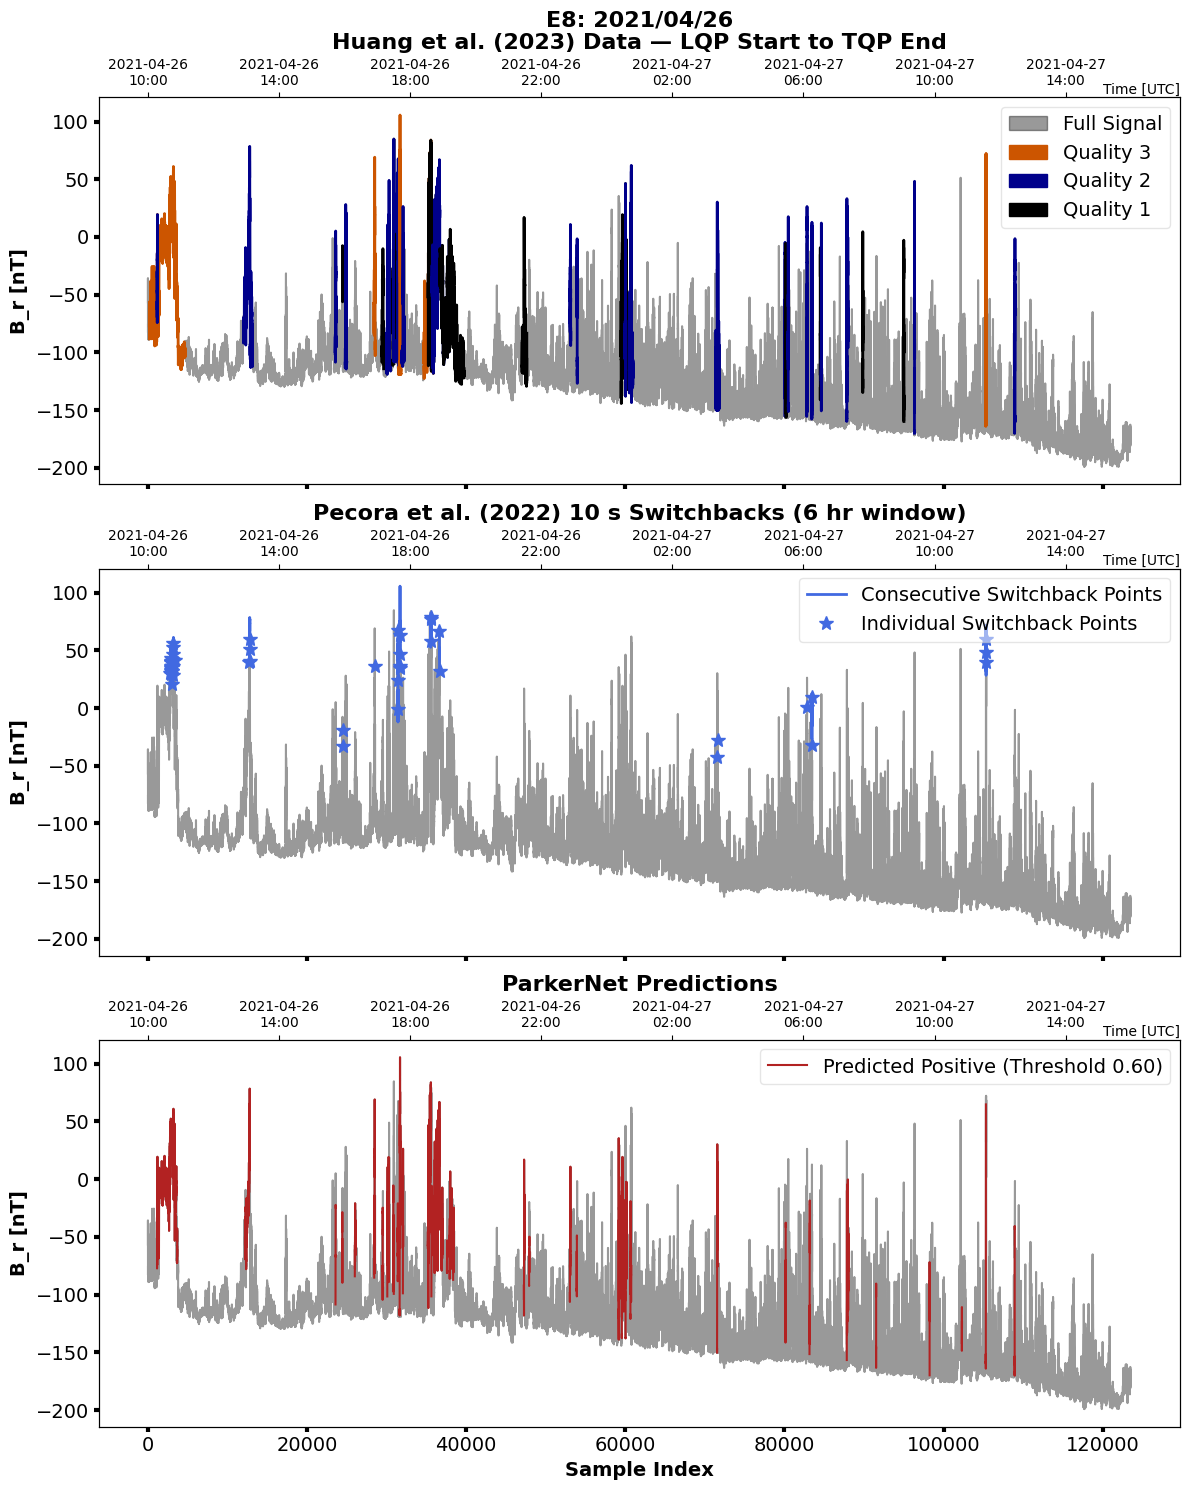

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.cluster import DBSCAN

# --- Load Huang and Pecora ---
roi_data    = pd.read_csv('SingalROI_E8_Huang_allRegions.txt', sep='\t')
pecora_data = pd.read_csv('SignalROI_E8_26and27_Pecora_10s_6hr.txt', sep='\t')

# --- Prepare ensemble data (must already have Datetime column) ---
signal_data   = df_ensemble_E8['B_r']
datetime_axis = df_ensemble_E8['Datetime']
predictions   = df_ensemble_E8['Weighted_Voting_AUC_PRC']

# threshold mask
threshold          = 0.6
binary_predictions = (predictions > threshold).astype(int)

# --- Convert Pecora indices to windows ---
time_steps_per_point     = 11.44
pecora_data['start_index'] = pecora_data['ClosestIndex'].astype(int)
pecora_data['end_index']   = (pecora_data['start_index'] + time_steps_per_point).round().astype(int)
n = len(df_ensemble_E8)
pecora_data[['start_index','end_index']] = pecora_data[['start_index','end_index']].clip(0, n-1)

# --- DBSCAN clustering ---
indices = pecora_data['start_index'].values.reshape(-1,1)
labels  = DBSCAN(eps=15, min_samples=2).fit_predict(indices)
clusters = []
for lbl in np.unique(labels):
    if lbl == -1: continue
    idxs = indices[labels==lbl].flatten()
    clusters.append((int(idxs[0]), int(idxs[-1])))

# --- Quality color map ---
quality_colors = {
    1: 'black',
    2: '#00008B',
    3: '#CC5500',
    4: '#8B0000',
    5: '#8B4513'
}

# --- Plotting ---
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True,
                        gridspec_kw={'height_ratios': [1,1,1]})

# Top: Full Signal + Huang switchbacks
axs[0].plot(signal_data, color='black', alpha=0.4, label='Full Signal')
legend_patches = [mpatches.Patch(color='black', alpha=0.4, label='Full Signal')]
added_qualities = set()
for _, row in roi_data.iterrows():
    q  = int(row['QualityFlag'])
    i0, i1 = int(row['LQP_Start_Index']), int(row['TQP_End_Index'])
    col = quality_colors.get(q, 'gray')
    axs[0].plot(range(i0, i1), signal_data[i0:i1], color=col, linewidth=2)
    if q not in added_qualities:
        legend_patches.append(mpatches.Patch(color=col, label=f'Quality {q}'))
        added_qualities.add(q)
axs[0].legend(handles=legend_patches, loc='upper right', fontsize=14, framealpha=0.5)
axs[0].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[0].set_title('E8: 2021/04/26\nHuang et al. (2023) Data — LQP Start to TQP End',
                 fontsize=16, fontweight='bold')

# Middle: Full Signal + Pecora points & clusters
axs[1].plot(signal_data, color='black', alpha=0.4, label='Full Signal')
sparse_color = '#4169E1'
# individual points
axs[1].plot(pecora_data['start_index'], signal_data[pecora_data['start_index']],
            '*', color=sparse_color, markersize=10, label='Individual Switchback Points')
# clustered segments
for i0, i1 in clusters:
    axs[1].plot(range(i0, i1), signal_data[i0:i1],
                color=sparse_color, linewidth=2)
pecora_line      = Line2D([0],[0], color=sparse_color, lw=2, label='Consecutive Switchback Points')
sparse_asterisk = Line2D([0],[0], color=sparse_color, marker='*',
                         linestyle='None', markersize=10,
                         label='Individual Switchback Points')
axs[1].legend(handles=[pecora_line, sparse_asterisk],
              loc='upper right', fontsize=14, framealpha=0.5)
axs[1].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[1].set_title('Pecora et al. (2022) 10 s Switchbacks (6 hr window)',
                 fontsize=16, fontweight='bold')

# Bottom: Full Signal + ParkerNet Predictions
model_line = signal_data.copy()
model_line[binary_predictions==0] = np.nan
axs[2].plot(signal_data, color='black', alpha=0.4)
axs[2].plot(model_line, color='#B22222', linewidth=1.5,
            label=f'Predicted Positive (Threshold {threshold:.2f})')
axs[2].legend(loc='upper right', fontsize=14, framealpha=0.5)
axs[2].set_xlabel('Sample Index', fontsize=14, fontweight='bold')
axs[2].set_ylabel('B_r [nT]', fontsize=14, fontweight='bold')
axs[2].set_title('ParkerNet Predictions', fontsize=16, fontweight='bold')

# --- Secondary datetime axis on top, ticks every 4 h ---
start_time    = datetime_axis.min().floor('h')
end_time      = datetime_axis.max().ceil('h')
four_hour_times = pd.date_range(start=start_time, end=end_time, freq='4h')
sample_ticks  = datetime_axis.searchsorted(four_hour_times)
tick_labels   = four_hour_times.strftime('%Y-%m-%d\n%H:%M')



for ax in axs:
    ax.tick_params(axis='x', labelsize=14, width=3)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=14, width=3)  # y-axis ticks
    twin = ax.twiny()
    twin.set_xlim(ax.get_xlim())
    twin.set_xticks(sample_ticks)
    twin.set_xticklabels(tick_labels, fontsize=10)
    twin.set_xlabel('Time [UTC]')
    twin.xaxis.label.set_horizontalalignment('right')
    twin.xaxis.set_label_coords(1, 1.01, transform=ax.transAxes)

plt.tight_layout()
plt.savefig('APJS_E8.svg', dpi=600, bbox_inches='tight')
plt.savefig('APJS_E8.pdf', dpi=600, bbox_inches='tight')
plt.show()


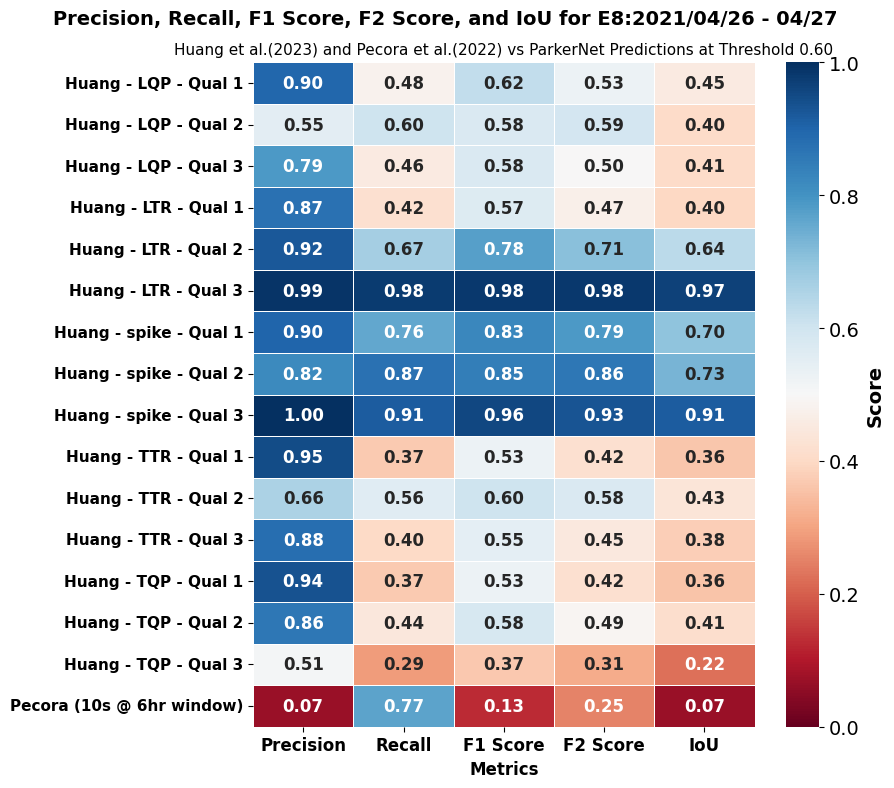

In [56]:



huang_data_path = 'SingalROI_E8_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E8['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E8['Class_Huang_E8_Range']

# Define threshold
threshold = 0.6

# Define regions for Huang ground truths
regions = {
    "LQP": ("LQP_Start_Index", "LQP_End_Index"),
    "LTR": ("LQP_End_Index", "spike_Start_Index"),
    "spike": ("spike_Start_Index", "spike_End_index"),
    "TTR": ("spike_End_index", "TQP_Start_Index"),
    "TQP": ("TQP_Start_Index", "TQP_End_Index")
}

# Initialize lists to store Precision, Recall, F1, F2, and IoU values for the heatmap
heatmap_data = []
row_labels = []

# Loop through regions and quality flags for Huang data
for region, (start_col, end_col) in regions.items():
    for quality in sorted(roi_data['QualityFlag'].unique()):
        row_labels.append(f"Huang - {region} - Qual {quality}")
        row_data = []

        # Filter quality rows for the current region and quality
        quality_rows = roi_data[roi_data['QualityFlag'] == quality]
        ground_truth_segment = []



        # Construct ground truth and predictions for the current region and quality
        for _, row in quality_rows.iterrows():
            start, end = row[start_col], row[end_col]
            gt_segment = ground_truth[start:end].values  # Get the ground truth for the segment
            pred_segment = (predictions[start:end] >= threshold).astype(int).values  # Get the predicted values
            ground_truth_segment.extend(gt_segment)
            ground_truth_segment.extend(pred_segment)

        # Calculate confusion matrix
        cm = confusion_matrix(ground_truth_segment[:len(ground_truth_segment)//2], ground_truth_segment[len(ground_truth_segment)//2:])

        # Get TP, FP, FN
        TN, FP, FN, TP = cm.ravel()

        # Calculate Precision, Recall, F1, and F2 for the current region and quality
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        F1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        F2_score = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) != 0 else 0

        # Calculate IoU for the current region and quality
        iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0

        # Append Precision, Recall, F1, F2, IoU results for the current region and quality
        row_data.extend([precision, recall, F1_score, F2_score, iou])

        # Append the data for the current region and quality
        heatmap_data.append(row_data)

#

#Load Pecora d10s 6hr window data
pecora_data = pd.read_csv('SignalROI_E8_26and27_Pecora_10s_6hr.txt', sep = '\t')
# Assuming df_ensemble_E8 contains model predictions
predictions_pecora = df_ensemble_E8['Weighted_Voting_AUC_PRC']

# Create binary predictions based on threshold for Pecora data
binary_predictions_pecora = (predictions_pecora >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices for Pecora (10 seconds)
ground_truth_pecora = np.zeros_like(binary_predictions_pecora)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Calculate Precision, Recall, F1, F2, and IoU for Pecora data (as one whole segment)
cm_pecora = confusion_matrix(ground_truth_pecora, binary_predictions_pecora)
TN_pecora, FP_pecora, FN_pecora, TP_pecora = cm_pecora.ravel()  # Get confusion matrix values

# Calculate Precision, Recall, F1, and F2 for Pecora (single value)
precision_pecora = TP_pecora / (TP_pecora + FP_pecora) if (TP_pecora + FP_pecora) != 0 else 0
recall_pecora = TP_pecora / (TP_pecora + FN_pecora) if (TP_pecora + FN_pecora) != 0 else 0
F1_score_pecora = (2 * precision_pecora * recall_pecora) / (precision_pecora + recall_pecora) if (precision_pecora + recall_pecora) != 0 else 0
F2_score_pecora = (5 * precision_pecora * recall_pecora) / (4 * precision_pecora + recall_pecora) if (4 * precision_pecora + recall_pecora) != 0 else 0

# Calculate IoU for Pecora
iou_pecora = TP_pecora / (TP_pecora + FP_pecora + FN_pecora) if (TP_pecora + FP_pecora + FN_pecora) != 0 else 0

# Append Pecora Precision, Recall, F1, F2, IoU to heatmap data
row_labels.append("Pecora (10s @ 6hr window)")
heatmap_data.append([precision_pecora, recall_pecora, F1_score_pecora, F2_score_pecora, iou_pecora])

# Convert heatmap data to DataFrame
heatmap_df = pd.DataFrame(heatmap_data, index=row_labels, columns=["Precision", "Recall", "F1 Score", "F2 Score", "IoU"])

# Plot combined heatmap for Precision, Recall, F1, F2, and IoU (including Huang and Pecora)
fig, ax = plt.subplots(figsize=(9, 8))  # Adjust figure size for better readability

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdBu", cbar_kws={'label': 'Score'},
            annot_kws={"weight": "bold", "size": 12},  # Make annotation bold
            linewidths=0.5,  # Optional: thin line between cells
            cbar=True, vmin=0, vmax=1, ax=ax)  # Set color scale to go from 0 to 1

# Title and labels in bold with line breaks for title
plt.suptitle("Precision, Recall, F1 Score, F2 Score, and IoU for E8:2021/04/26 - 04/27", fontsize=14, fontweight='bold', y=0.98)
ax.set_title("Huang et al.(2023) and Pecora et al.(2022) vs ParkerNet Predictions at Threshold 0.60", fontsize=11, fontweight='normal', loc='center')

# Set xlabel with bold font
ax.set_xlabel("Metrics", fontsize=12, fontweight='bold')

# Make the y-axis labels bold and adjust font size
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontweight='bold')

# Make the legend label bold
cbar = ax.collections[0].colorbar
cbar.set_label('Score', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=12, fontweight = 'bold')

# Adjust layout to ensure everything fits without excessive width
plt.tight_layout()
#plt.savefig('E8_heatmap_1.svg', dpi=600, bbox_inches='tight')
plt.show()

 (True Negatives):  106211
 (False Positives):  587
(False Negatives):  10852
 (True Positives):  5898
Precision: 0.9095
Recall: 0.3521
F1 Score: 0.5077
Total Switchbacks (Ground Truth 1):  16750
Intersection over Union (IoU): 0.3402


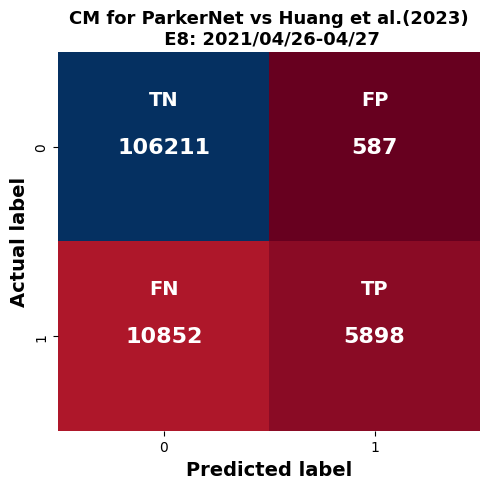

IoU at threshold 0.6: 0.3402


In [57]:


huang_data_path = 'SingalROI_E8_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E8['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E8['Class_Huang_E8_Range']

# Define threshold
threshold = 0.6

# Confusion Matrix Function
def plot_cm_and_metrics(labels, predictions, threshold=0.6):
    # Compute the confusion matrix
    cm = confusion_matrix(labels, predictions > threshold)

    # Plot the confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title('CM for ParkerNet vs Huang et al.(2023)\n E8: 2021/04/26-04/27', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')
    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()

    # Position the labels slightly above the center of each section
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # Show the plot
    plt.savefig('E8_Huang_CM.svg', dpi=600, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth, predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
print(f'IoU at threshold {threshold}: {iou:.4f}')

   Threshold  Precision    Recall  F1 Score       AUC
0       0.50   0.653233  0.457731  0.538281  0.559858
1       0.55   0.802400  0.403164  0.536676  0.559858
2       0.60   0.909483  0.352119  0.507682  0.559858
3       0.65   0.940437  0.303522  0.458928  0.559858
4       0.70   0.966102  0.255224  0.403778  0.559858
5       0.75   1.000000  0.202866  0.337304  0.559858
6       0.80   1.000000  0.139881  0.245430  0.559858
7       0.85   0.000000  0.000000  0.000000  0.559858
8       0.90   0.000000  0.000000  0.000000  0.559858
9       0.95   0.000000  0.000000  0.000000  0.559858


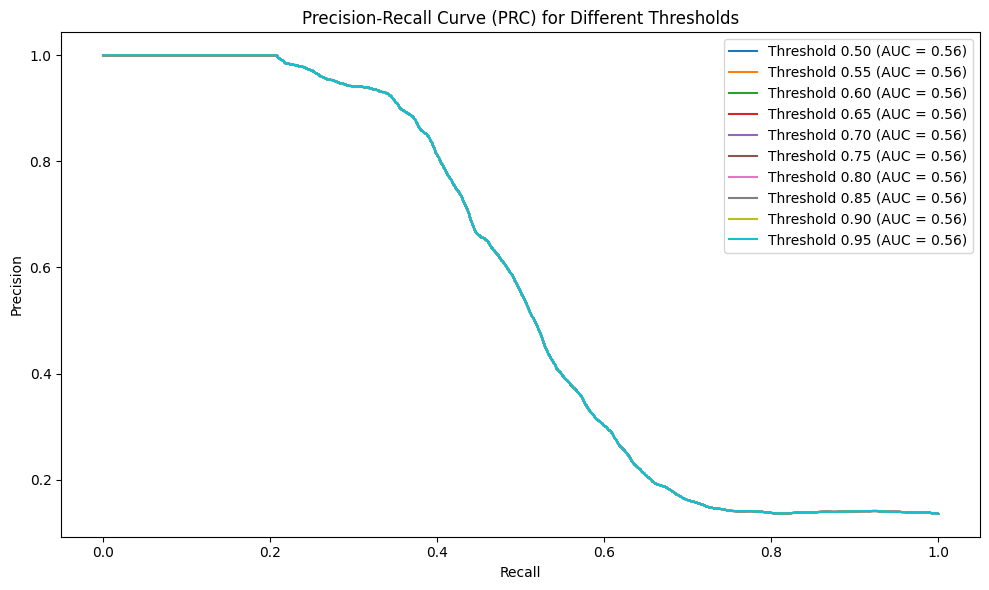

In [ ]:



huang_data_path = 'SingalROI_E8_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')


predictions = df_ensemble_E8['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E8['Class_Huang_E8_Range']

# Define thresholds for analysis
thresholds = np.arange(0.5, 1.0, 0.05)

# Initialize lists to store metrics for each threshold
precision_list = []
recall_list = []
f1_list = []
auc_list = []

# Create an empty DataFrame to store the metrics for each threshold
metrics_df = pd.DataFrame(columns=['Threshold', 'Precision', 'Recall', 'F1 Score', 'AUC'])

# Function to calculate confusion matrix and metrics
def calculate_metrics(labels, predictions, threshold):
    cm = confusion_matrix(labels, predictions > threshold)
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # Calculate Precision-Recall curve and AUC
    precision_curve, recall_curve, _ = precision_recall_curve(labels, predictions)
    auc_score = auc(recall_curve, precision_curve)

    return precision, recall, f1_score, auc_score

# Loop through each threshold and calculate metrics
for threshold in thresholds:
    precision, recall, f1_score, auc_score = calculate_metrics(ground_truth, predictions, threshold)

    # Add the results to the metrics dataframe using pd.concat
    new_row = pd.DataFrame({
        'Threshold': [threshold],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1_score],
        'AUC': [auc_score]
    })

    metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Print the metrics DataFrame
print(metrics_df)

# Plot the Precision-Recall curve and include AUC in the legend
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    # Get precision and recall for the current threshold
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Plot each threshold with its AUC score in the legend
    plt.plot(recall_curve, precision_curve, label=f'Threshold {threshold:.2f} (AUC = {auc_score:.2f})')

plt.title('Precision-Recall Curve (PRC) for Different Thresholds')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

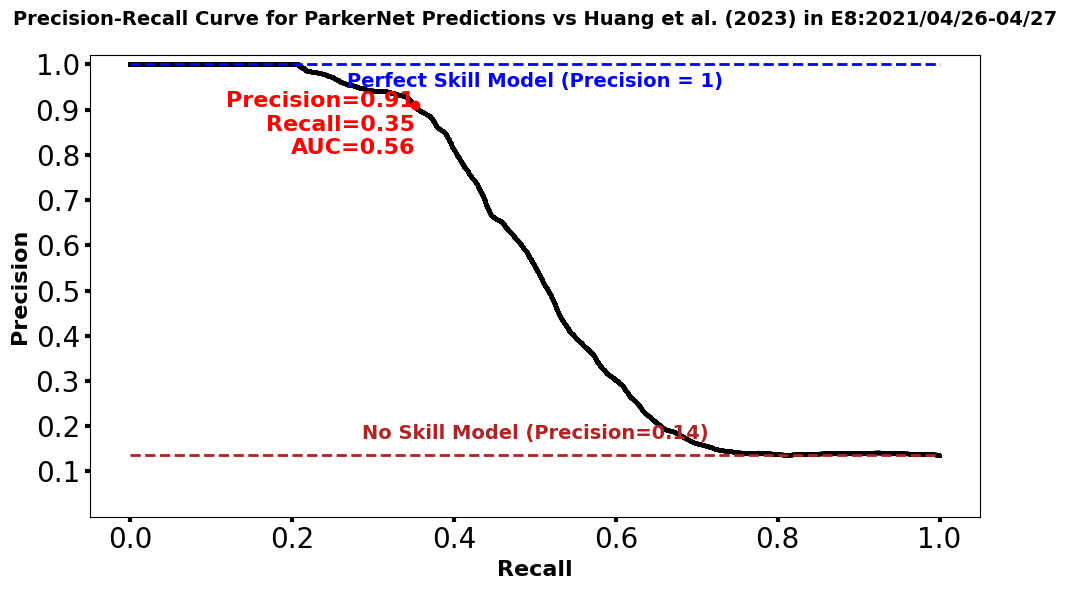

In [ ]:



huang_data_path = 'SingalROI_E8_Huang_allRegions.txt'
roi_data = pd.read_csv(huang_data_path, delimiter='\t')

predictions = df_ensemble_E8['Weighted_Voting_AUC_PRC']
ground_truth = df_ensemble_E8['Class_Huang_E8_Range']

# Define thresholds (from 0.5 to 0.95)
thresholds = np.round(np.arange(0.5, 0.95, 0.05), 2)

# Initialize lists to store the Precision-Recall curve and AUC for each threshold
precision_dict = {}
recall_dict = {}
auc_dict = {}

# Calculate Precision-Recall curve and AUC for each threshold
for threshold in thresholds:
    precision_curve, recall_curve, _ = precision_recall_curve(ground_truth, predictions)
    auc_score = auc(recall_curve, precision_curve)

    # Store precision, recall, and auc values for each threshold
    precision_dict[threshold] = precision_curve
    recall_dict[threshold] = recall_curve
    auc_dict[round(threshold, 2)] = auc_score  # Round threshold to two decimal places

# Plot Precision-Recall curves for all thresholds
plt.figure(figsize=(10, 6))

for threshold in thresholds:
    plt.plot(recall_dict[threshold], precision_dict[threshold], color='black', linewidth=3)

# Provided precision and recall at threshold 0.6

threshold_0_6_precision = 0.909483
threshold_0_6_recall =  0.352119

# Calculate AUC at threshold 0.6
auc_at_06 = auc_dict[0.6]  # AUC for threshold 0.6

# Plot the red dot for threshold 0.6
plt.plot(threshold_0_6_recall, threshold_0_6_precision, 'k-', label=f'Model Precision-Recall curve at 0.60 threshold')

# Calculate No Skill Model baseline
num_positives = np.sum(ground_truth == 1)
num_total = len(ground_truth)
no_skill_precision = num_positives / num_total
no_skill_recall = num_positives / num_total  # Recall is the same as the proportion of positives

# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.2f})',
             (0.5, no_skill_precision + 0.005),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.92),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')

# Adding labels and title
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Huang et al. (2023) in E8:2021/04/26-04/27\n', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(threshold_0_6_recall, threshold_0_6_precision, color='red', zorder=5)

# Add the red dot annotation for threshold 0.6
plt.annotate(f'Precision={threshold_0_6_precision:.2f}\nRecall={threshold_0_6_recall:.2f}\nAUC={auc_at_06:.2f}',
             (threshold_0_6_recall, threshold_0_6_precision),
             textcoords="offset points",
             xytext=(0,10),
             ha='right', va= 'top', fontsize=16, fontweight='bold', color='red')

# Set y-axis limits to ensure the perfect skill line is visible
plt.ylim(0/1, 1.02)
# Customize y-axis ticks to show 0.1 and 0.9
plt.yticks(np.arange(0.1, 1.02, 0.1))  # Set y-ticks from 0 to 1 with step of 0.1

# Apply the tick parameters to all axes after plotting
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks


#plt.savefig('E8_Huang_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


 (True Negatives):  116927
 (False Positives):  6038
(False Negatives):  136
 (True Positives):  447
Precision: 0.0689
Recall: 0.7667
F1 Score: 0.1265
Total Switchbacks (Ground Truth 1):  583
Intersection over Union (IoU): 0.0675
IoU at threshold 0.6: 0.0675


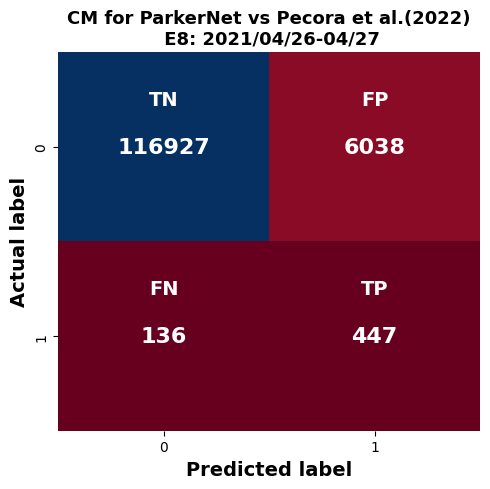

In [58]:



pecora_data = pd.read_csv('SignalROI_E8_26and27_Pecora_10s_6hr.txt', sep='\t')

predictions = df_ensemble_E8['Weighted_Voting_AUC_PRC']

# Define threshold
threshold = 0.6

# Create a binary prediction array based on the threshold
binary_predictions = (predictions >= threshold).astype(int)

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Calculate start and end indices based on the Pecora data and 10-second window
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)  # Ensure integers

# Construct ground truth based on adjusted indices
ground_truth_pecora = np.zeros_like(binary_predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def plot_cm_and_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)
    if np.all(cm == 0):  # Check if cm is all zeros (invalid case)
        print("Warning: Confusion matrix is all zeros!")
        return None  # Return None if confusion matrix is empty

    # Plot confusion matrix using heatmap
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", cbar=False, annot_kws={"size": 16, "weight":"bold"})
    plt.title(f'CM for ParkerNet vs Pecora et al.(2022)\n E8: 2021/04/26-04/27', fontsize=13, fontweight='bold')
    plt.ylabel('Actual label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=14, fontweight='bold')

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Annotate TP, FP, FN, TN above the matrix values
    ax = plt.gca()
    ax.text(0.5, 0.25, 'TN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 0.25, 'FP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(0.5, 1.25, 'FN', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax.text(1.5, 1.25, 'TP', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    print(' (True Negatives): ', TN)
    print(' (False Positives): ', FP)
    print('(False Negatives): ', FN)
    print(' (True Positives): ', TP)

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1_score:.4f}')

    print('Total Switchbacks (Ground Truth 1): ', np.sum(cm[1]))

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    print(f'Intersection over Union (IoU): {iou:.4f}')

    # Return IoU for potential further use
    return iou

# Apply the confusion matrix and calculate metrics for the threshold
iou = plot_cm_and_metrics(ground_truth_pecora, binary_predictions, threshold=0.6)

# Optionally, you can print IoU as well if needed:
if iou is not None:
    print(f'IoU at threshold {threshold}: {iou:.4f}')

# Show the plot
plt.tight_layout()
#plt.savefig('E8_Pecora_CM_1.svg', dpi=600, bbox_inches='tight')  # Save after the plot is created
plt.show()

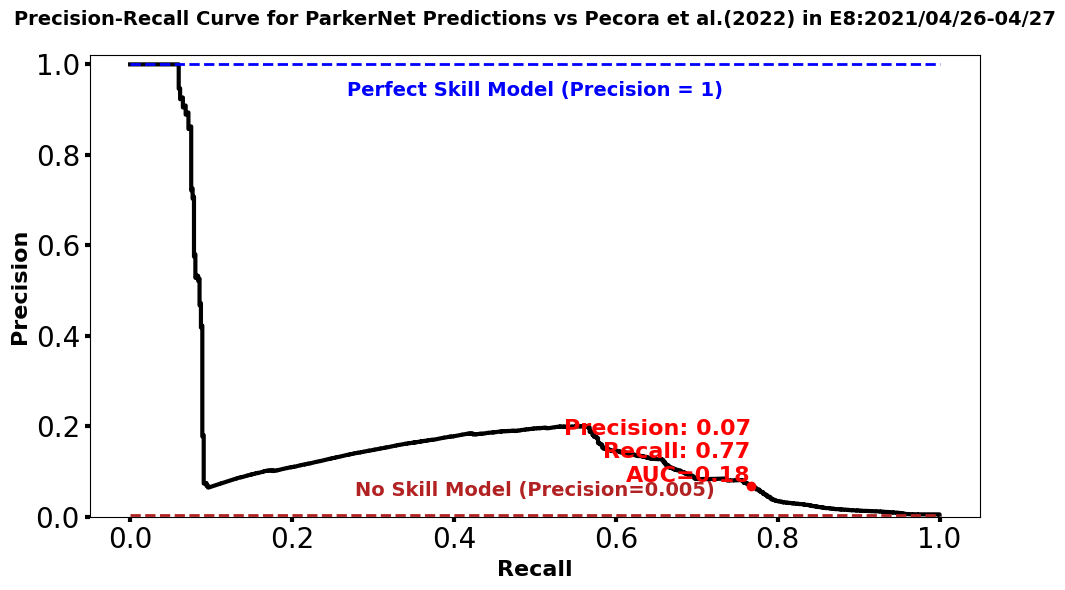

In [ ]:



pecora_data = pd.read_csv('SignalROI_E8_26and27_Pecora_10s_6hr.txt', sep='\t')
predictions = df_ensemble_E8['Weighted_Voting_AUC_PRC']

# Window size: 10 seconds = 11.44 time steps (rounded)
time_steps_per_point = 11.44  # Time steps corresponding to 10 seconds

# Adjust Pecora data based on the start and end indices (10-second window)
pecora_data['start_index'] = pecora_data['ClosestIndex']
pecora_data['end_index'] = (pecora_data['ClosestIndex'] + time_steps_per_point).round().astype(int)

# Construct ground truth based on adjusted indices for Pecora data
ground_truth_pecora = np.zeros_like(predictions)

for _, row in pecora_data.iterrows():
    start_idx, end_idx = int(row['start_index']), int(row['end_index'])  # Ensure integers
    ground_truth_pecora[start_idx:end_idx] = 1  # Mark the range as ground truth

# Define thresholds to evaluate
thresholds = np.linspace(0.1, 0.9, 9)

# Initialize list to store metrics
metrics_list = []

# Confusion Matrix Function to calculate TP, FP, FN, TN, and metrics
def calculate_metrics(labels, predictions, threshold=0.7):
    cm = confusion_matrix(labels, predictions > threshold)

    # Get TP, FP, TN, FN
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return precision, recall, f1_score

# Evaluate metrics at various thresholds
for threshold in thresholds:
    precision, recall, f1_score = calculate_metrics(ground_truth_pecora, predictions, threshold)
    metrics_list.append({'Threshold': threshold, 'Precision': precision, 'Recall': recall, 'F1 Score': f1_score})

# Convert metrics list to dataframe
metrics_df = pd.DataFrame(metrics_list)

# Plot the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ground_truth_pecora, predictions)

# **Perfect Skill** line will be precision=1, recall=1 across all recall values
perfect_skill = np.ones_like(recall)

# **No Skill** line is precision = the proportion of positive samples in the ground truth
no_skill_precision = np.sum(ground_truth_pecora == 1) / len(ground_truth_pecora)  # Proportion of positive samples
no_skill = np.full_like(recall, no_skill_precision)

# AUC at threshold 0.6
threshold_06_index = np.where(thresholds >= 0.6)[0][0]
precision_at_06 = metrics_df.loc[threshold_06_index, 'Precision']
recall_at_06 = metrics_df.loc[threshold_06_index, 'Recall']
auc_at_06 = auc(recall, precision)  # Calculate AUC value

plt.figure(figsize=(10, 6))

# Plot Precision-Recall Curve
plt.plot(recall, precision, color='black', lw=3, label=f'Model Precision-Recall Curve at 0.6 threshold')



# Plot No Skill Model baseline line
plt.plot([0, 1], [no_skill_precision, no_skill_precision], linestyle='--', linewidth = 2, color='#B22222')
# Add annotation for No Skill Model line
plt.annotate(f'No Skill Model (Precision={no_skill_precision:.3f})',
             (0.5, no_skill_precision + 0.01),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='#B22222')

# Plot Perfect Skill Model line (Precision = 1)
plt.plot([0, 1], [1, 1], linestyle='--', color='blue', linewidth = 2)
# Add annotation for Perfect Skill Model line
plt.annotate(f'Perfect Skill Model (Precision = 1)',
             (0.5, 0.9),
             textcoords="offset points",
             xytext=(0, 10),
             ha='center', fontsize=14, fontweight='bold', color='blue')


# Plot Precision and Recall values at threshold 0.6 directly on the graph
plt.text(recall_at_06, precision_at_06, f'Precision: {precision_at_06:.2f}\nRecall: {recall_at_06:.2f}\nAUC={auc_at_06:.2f}', color='red', fontsize=16, fontweight = 'bold', ha='right', va='bottom')

# Plot red dot at the 0.6 threshold precision and recall
plt.scatter(recall_at_06, precision_at_06, color='red', zorder=5)

# Labels and Title
plt.xlabel('Recall', fontsize=16, fontweight='bold')
plt.ylabel('Precision', fontsize=16, fontweight='bold')
plt.title('Precision-Recall Curve for ParkerNet Predictions vs Pecora et al.(2022) in E8:2021/04/26-04/27\n', fontsize=14, fontweight='bold')

plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.02, 0.2))
# Display the dataframe with metrics at different thresholds
#display(metrics_df)
# Increase the size of the x and y axis tick marks
plt.tick_params(axis='x', labelsize=20, width=3)  # Increase font size for x-axis ticks
plt.tick_params(axis='y', labelsize=20, width=3)  # Increase font size for y-axis ticks

#plt.savefig('E8_Pecora_PRC.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()
